## newborn-seeding-reaction

# Olink

#### Reading packages

In [2]:
library("ggplot2"); packageVersion("ggplot2")
library("ggrepel"); packageVersion("ggrepel")
library("microshades"); packageVersion("microshades")

library("dplyr"); packageVersion("dplyr")
library("tidyr"); packageVersion("tidyr")
library("reshape2"); packageVersion("reshape2")
library("stringr"); packageVersion("stringr")
library("gee"); packageVersion("gee")
library("hrbrthemes"); packageVersion("hrbrthemes")

[1] ‘4.0.2’

[1] ‘0.9.6’

[1] ‘1.13’

[1] ‘1.2.1’

[1] ‘1.3.1’

[1] ‘1.4.4’

[1] ‘1.5.1’

[1] ‘4.13.29’

[1] ‘0.8.7’

#### reading input data

In [305]:
olink_data = read.csv("../input/olink//olink_data.csv", row.names = "X")

olink_data_md = olink_data %>% distinct(SampleID, .keep_all = TRUE) %>% 
    dplyr::select(SampleID, subject, BinGroupStr, BinGroupNumeric, baby_age, group, sex, mode_delivery, gestational_Age)

#### Cytokine index of dispersion

In [4]:
calculate_variance <- function(df) {

    cytokine_list <- unique(df$Assay)

    variance_df <- data.frame(cytokine = as.character(), mean = as.numeric(), var = as.numeric(), sd = as.numeric())

    for (cytokine in cytokine_list) {

        print(cytokine)

        df_cytokine = df %>% subset(Assay == cytokine)

        cytokine_mean = mean(df_cytokine$NPX)
        cytokine_sd = sd(df_cytokine$NPX)
        cytokine_variance = var(df_cytokine$NPX)

        cytokine_metrics = data.frame(cytokine = cytokine, mean = cytokine_mean, var = cytokine_variance, sd = cytokine_sd)

        variance_df = rbind(variance_df, cytokine_metrics)

    }

    variance_df$index_of_dispersion = variance_df$var / variance_df$mean

    variance_df = variance_df %>% arrange(desc(index_of_dispersion))

    return(variance_df)
}

#### Cytokine variance explained

In [5]:
var_explained_input = olink_data
var_explained_input$Assay = paste("olink", var_explained_input$Assay, sep = "_")
var_explained_input$Assay = gsub("-", "_", var_explained_input$Assay)
var_explained_input$Assay = gsub(" ", ".", var_explained_input$Assay)

cytokine_list = unique(var_explained_input$Assay)
cytokine_list = cytokine_list[cytokine_list != "olink_STAMPB"] # Too many missing values
cytokine_list = cytokine_list[cytokine_list != "olink_BDNF"] # Too many missing values

var_explained_input_wide = var_explained_input %>% pivot_wider(id_cols = SampleID, names_from = Assay, values_from = NPX) %>% data.frame()

var_explained_input_wide_md = merge(var_explained_input_wide, olink_data_md, by = "SampleID")
rownames(var_explained_input_wide_md) = var_explained_input_wide_md$SampleID

var_explained_input_wide_md = var_explained_input_wide_md %>% subset(!(BinGroupStr %in% c("180-360d", ">360d"))) #%>%  subset(baby_age > 0 & baby_age <= 6) # select timeframe

In [6]:
var_explained_input_wide_md %>% distinct(SampleID) %>% nrow

[1] 881

In [7]:
cytokine_total_counts = olink_data[, c("Assay", "NPX", "LOD")] %>% 
    group_by(Assay) %>% 
    tally %>% 
    arrange(desc(n)) %>%
    dplyr::rename(total_counts = n)


# Doesnt have all cytokines. The ones that are missing have all values > LOD
Cytokines_with_missing_values = olink_data[, c("Assay", "NPX", "LOD")] %>% 
    mutate(
        NPX = round(NPX, 5),
        LOD = round(LOD, 5),
        LOD_indicator = ifelse(NPX <= LOD, "belowLOD", "aboveLOD")) %>%
    group_by(Assay, LOD_indicator) %>% 
    tally() %>% 
    subset(LOD_indicator == "belowLOD") %>%
    dplyr::rename(belowLOD_counts = n) %>%
    merge(cytokine_total_counts, by = "Assay") %>%
    mutate(percentage_missing_value = belowLOD_counts / total_counts) %>%
    arrange(desc(percentage_missing_value))

In [ ]:
df_variance_lm = data.frame()

for (cytokine in cytokine_list) {

    cat(cytokine, "\n")
    formula_cytokine <- paste(cytokine, "~mode_delivery + group + sex", sep = "")

    model_cytokine = lm(formula = formula_cytokine, data=var_explained_input_wide_md)
    r2_cytokine_full = summary(model_cytokine)$r.squared
    df_variance = data.frame(cytokine = cytokine, r2 = r2_cytokine_full)


    formula_cytokine_MoD <- paste(cytokine, "~group + sex", sep = "")
    model_cytokine_MoD = lm(formula = formula_cytokine_MoD, data=var_explained_input_wide_md)
    r2_cytokine_group_sex = summary(model_cytokine_MoD)$r.squared
    r2_cytokine_MoD_adjusted = r2_cytokine_full - r2_cytokine_group_sex
    df_variance$r2_cytokine_group_sex = r2_cytokine_group_sex
    df_variance$r2_cytokine_MoD_adjusted = r2_cytokine_MoD_adjusted

    formula_cytokine_group <- paste(cytokine, "~mode_delivery + sex", sep = "")
    model_cytokine_group = lm(formula = formula_cytokine_group, data=var_explained_input_wide_md)
    r2_cytokine_MoD_sex = summary(model_cytokine_group)$r.squared
    r2_cytokine_group_adjusted = r2_cytokine_full - r2_cytokine_MoD_sex
    df_variance$r2_cytokine_MoD_sex = r2_cytokine_MoD_sex
    df_variance$r2_cytokine_group_adjusted = r2_cytokine_group_adjusted

    formula_cytokine_sex <- paste(cytokine, "~mode_delivery + group", sep = "")
    model_cytokine_sex = lm(formula = formula_cytokine_sex, data=var_explained_input_wide_md)
    r2_cytokine_MoD_group = summary(model_cytokine_sex)$r.squared
    r2_cytokine_sex_adjusted = r2_cytokine_full - r2_cytokine_MoD_group
    df_variance$r2_cytokine_MoD_group = r2_cytokine_MoD_group
    df_variance$r2_cytokine_sex_adjusted = r2_cytokine_sex_adjusted

    df_variance_lm = rbind(df_variance_lm, df_variance)
}

df_variance_lm_adjusted = df_variance_lm[, c("cytokine", "r2", "r2_cytokine_MoD_adjusted", "r2_cytokine_group_adjusted", "r2_cytokine_sex_adjusted")] #%>%
    #subset(!(cytokine %in% Cytokines_with_missing_values$variable))

write.csv(df_variance_lm_adjusted, "../output/olink/week1_variance_explained_lmer_adjusted.csv")



In [ ]:
variance_CB_to_6m = olink_data %>% subset(!(BinGroupStr %in% c("180-360d", ">360d"))) %>% calculate_variance() %>% mutate(BinGroupStr = "CB_to_6m", BinGroupNumeric = 5)
variance_CB_to_6m$Assay = variance_CB_to_6m$cytokine
variance_CB_to_6m$cytokine = paste("olink", variance_CB_to_6m$cytokine, sep = "_")
variance_CB_to_6m$cytokine = gsub("-", "_", variance_CB_to_6m$cytokine)
variance_CB_to_6m$cytokine = gsub(" ", ".", variance_CB_to_6m$cytokine)

variance_CB_to_6m = merge(variance_CB_to_6m, df_variance_lm_adjusted, by = "cytokine")
variance_CB_to_6m$var_unexplained = 1 - variance_CB_to_6m$r2

#### Plotting Cytokine variance explained * Index of Dispersion

In [ ]:
options(repr.plot.width = 17, repr.plot.height = 12)
variance_plot_olink = ggplot(data = variance_CB_to_6m, aes( x = index_of_dispersion, y = r2)) + 

    geom_point(aes(size = index_of_dispersion), alpha = .85, shape = 21, col = "white", fill = '#731156') + 
    scale_size(range = c(5, 25), name = "index of dispersion") +

    #scale_size(range = c(.1, 24), name="index of dispersion") +
#   scale_fill_gradient2(
#       name="colors",
#       low = "#fbff7f", 
#       mid = "#bc3754",
#       high = "#781c6d",
#       midpoint = 0.5, limits = c(0, 1), na.value = "#52134b",
#       space = "Lab",
#       guide = "colourbar"
#   ) +

    geom_label_repel(aes(label = ifelse(index_of_dispersion > 0.6 | r2 > 0.08, gsub("olink_", "", cytokine), "")),
                     size = 8,
                     min.segment.length = 1, 
                     alpha = 1, 
                     label.size = NA, 
                     col = "black", 
                     fill = NA,
                     max.overlaps = Inf) +

    theme_ipsum(base_family = "ArialMT") +
    theme(
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(colour = "black"),
        axis.text.x = element_text(size = 14, face = "bold"), 
        axis.text.y = element_text(size = 14, face = "bold"),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_text(size = 16, face = "bold")) + 
#
    labs ( x = "index of dispersion ( variance / mean ) ", y = "R2 (y = Mode of Delivery + Sex + Gestational Age)")

ggsave("../output/olink/variance_plot_olink-unfiltered.pdf", variance_plot_olink, width = 17, height = 12)

variance_plot_olink
variance_plot_olink <- NULL

# NULISA data

#### Metadata

#### NULISA data

In [307]:
NPQ_data_Tellus = read.csv("../input/nulisa/NPQ_data_Tellus.csv", row.names = "X") 

NPQ_data_Tellus$BinGroupStr = factor(NPQ_data_Tellus$BinGroupStr, levels = c("CB", "1-5d", "28-30d", "78-105d", "114-127d", "137-201d", "225d", "334-394d", "409-587d", "637-767d", ">900d"))

NULISA_metadata = NPQ_data_Tellus %>% dplyr::select(sample, subject, baby_age, group, sex, mode_delivery, BinGroupStr, BinGroupNumeric) %>% distinct(sample, .keep_all = TRUE)

# COMBINING OLINK AND NULISA FOR LOG2FC (CATEGORIZING IFNG HIGH / LOW INFANTS)

Log2FC calculated NPX - NPX[age = CB]

Log2FC calcualted for Olink and Nulisa data separately

For subjects missing CB samples, this was imputed by median of all CB samples (separate median for Olink and Nulisa)

IFNG category (High / Low) cutoffs was selected based on the median Log2FC at 1w

#### FUNCTIONS

In [12]:
calculate_cb_medians <- function(data, value_col) {
    # Get unique cytokines
    cytokines <- unique(data$analyte)
    
    # Initialize results dataframe
    results <- data.frame(
        analyte = character(),
        cb_median = numeric(),
        stringsAsFactors = FALSE
    )
    
    # Loop through each cytokine
    for (cytokine in cytokines) {
        # Subset data for current cytokine and CB timepoint
        cb_data <- data %>%
            filter(analyte == cytokine, BinGroupStr == "CB")
        
        # Calculate median if data exists
        if (nrow(cb_data) > 0) {
            median_val <- median(cb_data[[value_col]], na.rm = TRUE)
            
            # Add to results
            results <- rbind(results, data.frame(
                analyte = cytokine,
                cb_median = median_val,
                stringsAsFactors = FALSE
            ))
        }
    }
    
    return(results)
}

# Example usage:
cb_medians <- calculate_cb_medians(NPQ_data_Tellus, "NPQ")


check_cb_missing <- function(data, value_col) {
    # Get unique subjects and cytokines
    subjects <- unique(data$subject)
    cytokines <- unique(data$analyte)
    
    # Initialize results dataframe
    results <- data.frame(
        subject = character(),
        analyte = character(),
        cb_missing = logical(),
        stringsAsFactors = FALSE
    )
    
    # Loop through each subject and cytokine combination
    for (subject in subjects) {
        for (cytokine in cytokines) {
            # Check if CB data exists for this subject-cytokine combination
            cb_data <- data %>%
                filter(subject == !!subject, analyte == cytokine, BinGroupStr == "CB")
            
            # Determine if CB value is missing
            cb_missing <- nrow(cb_data) == 0 || all(is.na(cb_data[[value_col]]))
            
            # Add to results
            results <- rbind(results, data.frame(
                subject = subject,
                analyte = cytokine,
                cb_missing = cb_missing,
                stringsAsFactors = FALSE
            ))
        }
    }
    
    return(results)
}


#### NULISA LOG2FC

per cytokine
1) Get list median CB values
2) Find subjects that have missing CB values, impute CB value
3) Merge datasets
4) Calculate Log2FC

In [13]:
NPQ_data_Tellus_md = NPQ_data_Tellus %>% distinct(subject, .keep_all = TRUE) %>% dplyr::select(subject, mode_delivery, gestational_Age, group, sex)

cb_medians <- calculate_cb_medians(NPQ_data_Tellus, "NPQ")
cb_missing <- check_cb_missing(NPQ_data_Tellus, "NPQ")

cb_missing_proportion_without_CB = cb_missing %>% 
    group_by(analyte, cb_missing) %>% 
    summarise(n = n(), .groups = 'drop') %>%
    arrange(analyte, cb_missing) %>%
    group_by(analyte) %>%
    mutate(total = sum(n)) %>%
    ungroup() %>%
    mutate(percentage = n / total) %>%
    arrange(desc(percentage)) %>%
    subset(cb_missing == TRUE) %>%
    dplyr::rename(proportion_missing_CB = percentage)

cb_missing_TRUE = cb_missing %>% subset(cb_missing == TRUE)

NULISA_imputed_CB = merge(cb_missing_TRUE, cb_medians, by = "analyte") %>% 
    dplyr::rename(NPQ = cb_median) %>% 
    mutate(
        sample = paste(subject, "imputed_CB", sep = "_"),
        BinGroupStr = "CB",
        BinGroupNumeric = 0,
        filename = "imputed plate",
        LOD = NA,
        n = NA,
        below_LOD = NA,
        sample_type = "Plasma",
        subject_type = "Baby",
        baby_age = 0
        ) %>%
    merge(NPQ_data_Tellus_md, by = "subject") %>%
    dplyr::select(-cb_missing)

NPQ_data_Tellus_imputed_CB = rbind(NPQ_data_Tellus, NULISA_imputed_CB) %>%
    merge(cb_missing_TRUE, by = c("subject", "analyte"), all.x = TRUE)

NPQ_data_Tellus_imputed_CB = NPQ_data_Tellus_imputed_CB %>%
    group_by(subject, analyte) %>%
    mutate(
        CB_value = NPQ[BinGroupStr == "CB"],
        log2FC = NPQ - CB_value
    ) %>%
    ungroup() %>%
    mutate(datatype = "NULISA") %>% 
    dplyr::select(
    subject, sample, analyte, NPQ, log2FC, cb_missing, CB_value, BinGroupStr, BinGroupNumeric, baby_age, mode_delivery, group, sex, datatype) %>%
    dplyr::rename(NPX_NPQ = NPQ) %>%
    mutate(proportion_missing_CB = 0.2417582)

#### OLINK LOG2FC

1) Get list median CB values per cytokine
2) Find subjects that have missing CB values, impute cytokine
3) Merge datasets
4) Calculate Log2FC

In [37]:
olink_data_for_log2FC = olink_data %>% mutate(analyte = Assay) %>% distinct(subject, analyte, BinGroupStr, .keep_all = TRUE)
olink_subject_md = olink_md %>% distinct(subject, .keep_all = TRUE) %>% dplyr::select(subject, mode_delivery, group, sex)

In [38]:
cb_medians_olink <- calculate_cb_medians(olink_data_for_log2FC, "NPX")
cb_missing_olink <- check_cb_missing(olink_data_for_log2FC, "NPX")

cb_missing_olink_proportion_without_CB =cb_missing_olink %>% 
    group_by(analyte, cb_missing) %>% 
    summarise(n = n(), .groups = 'drop') %>%
    arrange(analyte, cb_missing) %>%
    group_by(analyte) %>%
    mutate(total = sum(n)) %>%
    ungroup() %>%
    mutate(percentage = n / total) %>%
    arrange(desc(percentage)) %>%
    subset(cb_missing == TRUE) %>%
    dplyr::rename(proportion_missing_CB = percentage)


cb_missing_olink_TRUE = cb_missing_olink %>% subset(cb_missing == TRUE)

olink_imputed_CB = merge(cb_missing_olink_TRUE, cb_medians_olink, by = "analyte") %>% 
    dplyr::rename(NPX = cb_median) %>% 
    mutate(
        SampleID = paste(subject, "imputed_CB", sep = "_"),
        BinGroupStr = "CB",
        BinGroupNumeric = 0,
        baby_age = 0
        ) %>%
    merge(olink_subject_md, by = "subject") %>%
    dplyr::select(-cb_missing)

olink_data_imputed_CB = rbind(olink_data_for_log2FC[, c("subject", "analyte", "NPX", "SampleID", "BinGroupStr", "BinGroupNumeric", "baby_age", "mode_delivery", "group", "sex")], olink_imputed_CB) %>%
    merge(cb_missing_olink_TRUE, by = c("subject", "analyte"), all.x = TRUE) %>%
    subset(analyte != "IL5") %>%
    subset(analyte != "IL13") %>%
    subset(analyte != "NRTN") %>%
    subset(analyte != "TSLP") %>%
    subset(analyte != "BDNF") %>%
    subset(analyte != "IL-24")

olink_data_imputed_CB = olink_data_imputed_CB %>%
    group_by(subject, analyte) %>%
    mutate(
        CB_value = NPX[BinGroupStr == "CB"],
        log2FC = NPX - CB_value
    ) %>%
    ungroup() %>%
    merge(cb_missing_olink_proportion_without_CB[,c("analyte", "proportion_missing_CB")], by = "analyte", all.x = TRUE) %>%
    mutate(datatype = "OLINK") %>% 
    dplyr::select(
    subject, SampleID, analyte, NPX, log2FC, cb_missing, CB_value, BinGroupStr, BinGroupNumeric, baby_age, mode_delivery, group, sex, datatype, proportion_missing_CB) %>%
    dplyr::rename(NPX_NPQ = NPX, sample = SampleID)

#### COMBINING OLINK AND NULISA LOG2FC



In [39]:
olink_nulisa_combined = rbind(olink_data_imputed_CB, NPQ_data_Tellus_imputed_CB) %>%
    mutate(BinGroupStr_new = ifelse(baby_age <= 0, "CB", 
                             ifelse(baby_age >= 1 & baby_age < 7, "1w", 
                             ifelse(baby_age >= 7 & baby_age <= 19, "7-19d", 
                             ifelse(baby_age >= 24 & baby_age <= 49, "24-48d", 
                             ifelse(baby_age >= 50 & baby_age <= 115, "50-115d", 
                             ifelse(baby_age >= 116 & baby_age <= 210, "116-210d", 
                             ifelse(baby_age >= 211 & baby_age <= 400, "7m - 1Y", 
                             ifelse(baby_age >= 401 & baby_age <= 800, "1-2Y", 
                             ifelse(baby_age >= 801, ">2Y", 
                             baby_age)))))))))) %>%

    arrange(baby_age)

olink_nulisa_combined$BinGroupStr_new= factor(olink_nulisa_combined$BinGroupStr_new, levels = c("CB", "1w", "7-19d", "24-48d", "50-115d", "116-210d", "7m - 1Y", "1-2Y", ">2Y"))

In [ ]:
#write.csv(olink_nulisa_combined, "../input/olink_nulisa/olink_nulisa-native-and-log2FC.csv")

## Categorizing infants as IFNG HIGH or LOW

In [309]:
olink_nulisa_combined = read.csv("../input/olink_nulisa/olink_nulisa-native-and-log2FC.csv", row.names = "X")
olink_nulisa_combined$BinGroupStr_new= factor(olink_nulisa_combined$BinGroupStr_new, levels = c("CB", "1w", "7-19d", "24-48d", "50-115d", "116-210d", "7m - 1Y", "1-2Y", ">2Y"))

In [15]:
log2FC_IFNG = olink_nulisa_combined %>% 
    subset(BinGroupStr_new %in% c("CB", "1w")) %>% 
    subset(analyte %in% c("IFNG", "IFN-gamma")) %>%
    subset(group == "Term")

In [ ]:
options(repr.plot.width = 15, repr.plot.height = 10)

plot = ggplot(log2FC_IFNG, aes(x = BinGroupStr_new, y = log2FC)) + 

    geom_point(size = 3.5, alpha = 0.75, position = position_jitter(width = 0.05, height = 0)) +

    geom_path(aes(group = subject), alpha = .35) + 

    geom_hline(yintercept = 4.625, linetype = "dashed", color = "red", linewidth = 2) + # median NULISA
    geom_hline(yintercept = 2.2, linetype = "dashed", color = "red", linewidth = 2) + # median OLINK

    geom_boxplot(width = 0.25, alpha = 0.65, fill = NA, outlier.shape = NA, color = "black") +

    facet_wrap(~datatype, ncol = 6) +

    theme_ipsum(base_family = "ArialMT") + 

    theme(
        axis.text.x = element_text(size = 14, face = "bold", angle = 45, hjust = 1, vjust = 0.5), 
        axis.text.y = element_text(size = 14, face = "bold"),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_text(size = 16, face = "bold"),
        strip.text = element_text(size = 16, face = "bold", margin = margin()),
    ) 

plot
ggsave(plot, filename = "../output/olink_nulisa_combined/IFNg-log2FC-unfiltered-LIMIT.pdf", width = 15, height = 10)

### OLINK AND NULISA IFNG QC

Log2FC calculated NPX - NPX[age = CB]

Log2FC calcualted for Olink and Nulisa data separately

For subjects missing CB samples, this was imputed by median of all CB samples (separate median for Olink and Nulisa)

IFNG category (High / Low) cutoffs was selected based on the median Log2FC at 1w

In [18]:
subjects_with_multiple_datatypes = log2FC_IFNG %>% subset(BinGroupStr_new == "1w") %>% distinct(subject, datatype, .keep_all = TRUE) %>% group_by(subject) %>% summarise(n = n()) %>% subset(n > 1)

df_to_compare_subs_across_datatype = log2FC_IFNG %>%
    subset(BinGroupStr_new == "1w") %>%
    subset(subject %in% subjects_with_multiple_datatypes$subject) %>%
    mutate(BinGroup_X = paste(BinGroupStr_new, datatype, sep = "_"))# %>%
    #subset(is.na(cb_missing))

df_to_compare_subs_across_datatype$BinGroup_X = factor(df_to_compare_subs_across_datatype$BinGroup_X, levels = c("CB_NULISA", "CB_OLINK", "1w_NULISA", "1w_OLINK"))

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)


plot = ggplot(df_to_compare_subs_across_datatype, aes(x = BinGroup_X, y = log2FC)) + 

    geom_point(aes(col = as.character(subject)), size = 7, alpha = 0.45, position = position_jitter(width = 0.05, height = 0)) +

    geom_path(aes(group = subject), linewidth = 1, alpha = .55) + 


    facet_wrap(~interaction(BinGroupStr_new), scales = "free",ncol = 2) +

    theme_ipsum(base_family = "ArialMT") + 

    theme(
        axis.text.x = element_text(size = 14, face = "bold", angle = 45, hjust = 1, vjust = 0.5), 
        axis.text.y = element_text(size = 14, face = "bold"),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_text(size = 16, face = "bold"),
        strip.text = element_text(size = 16, face = "bold", margin = margin()),
    ) 

plot
ggsave(plot, filename = "../output/olink_nulisa_combined/IFNg-datatype-NPX_NPQ.pdf", width = 10, height = 10)
plot <- NULL

## Plotting IFNG trajectories

Here we plot Olink, NULISA and preterm/Terms separately over time. Comparing mean differences in IFNg categories and MoD.

In [358]:
olink_nulisa_combined = read.csv("../input//olink_nulisa//olink_nulisa_combined-native-NPX-NPQ.csv", row.names = "X") 

 
olink_nulisa_combined$BinGroupStr = factor(olink_nulisa_combined$BinGroupStr, levels = c("CB", "1w", "7-19d", "24-48d", "50-115d", "116-210d", "7m - 1Y", "1-2Y", ">2Y"))

In [355]:
traj_fill_cols = c('#FCBA6F', '#5E4C5F')
traj_cols = c('#FFAA48', '#49374A')

create_IFNG_plot <- function(cytokine_data, mean_data, analyte_, group_, datatype_) {
    
    plot = ggplot(cytokine_data, aes(x = BinGroupStr, y = NPX_NPQ)) + 

        geom_point(aes(col = IFNG_category), shape = 16, size = 5, alpha = 0.55, position = position_jitter(width = 0.08, height = 0)) +

        #geom_path(aes(group = subject, col = IFNG_category, fill = IFNG_category), alpha = .15) + 

        geom_path(data = mean_data, 
            aes(
                x = BinGroupStr, 
                y = mean_NPX_NPQ, 
                group = IFNG_category, 
                col = IFNG_category), 
            lwd = 3) +

        geom_ribbon(data = mean_data, 
            aes(
                x = BinGroupStr, 
                y = mean_NPX_NPQ, 
                ymin = lower_2se, 
                ymax = upper_2se, 
                group = IFNG_category, 
                col = IFNG_category, 
                fill = IFNG_category), 
            alpha = 0.4) +

        scale_color_manual(values = traj_cols) +
        scale_fill_manual(values = traj_fill_cols) +


        theme_ipsum(base_family = "ArialMT") + 

        theme(
            axis.text.x = element_text(size = 18, face = "bold", angle = 45, hjust = 1, vjust = 0.5), 
            axis.text.y = element_text(size = 18, face = "bold"),
            axis.title.x = element_text(size = 16, face = "bold"),
            axis.title.y = element_text(size = 16, face = "bold"),
            strip.text = element_text(size = 16, face = "bold", margin = margin()),
            legend.position = "top"
        ) + ggtitle(paste(analyte_, group_, datatype_, sep = "-"))
    
    plot_name = paste("../output/olink_nulisa_combined/IFNG_category/", analyte_, "-", group_, "-", datatype_, ".pdf", sep = "")

    ggsave(plot, filename = plot_name, width = 10, height = 10)

}

In [ ]:
IFNG_mean_NPX_NPQ_per_cytokine = olink_nulisa_combined %>%
    subset(!is.na(IFNG_category)) %>% 
    group_by(datatype, group, analyte, BinGroupStr, IFNG_category) %>% 
    dplyr::summarise(
        mean_NPX_NPQ = mean(NPX_NPQ),
        sd_NPX_NPQ = sd(NPX_NPQ),
        se_NPX_NPQ = sd(NPX_NPQ) / sqrt(n()),
        upper_2se = mean_NPX_NPQ + 2 * se_NPX_NPQ,
        lower_2se = mean_NPX_NPQ - 2 * se_NPX_NPQ
    ) %>%
    ungroup()

In [ ]:
for (datatype_ in unique(olink_nulisa_combined$datatype)) {

    datatype_cytokine_data = subset(olink_nulisa_combined, datatype == datatype_)
    datatype_mean_data = subset(IFNG_mean_NPX_NPQ_per_cytokine, datatype == datatype_)

    for (analyte_ in c("IFNG", "IFN-gamma", "IL1B", "IL-1 alpha")) {
#    for (analyte_ in unique(datatype_cytokine_data$analyte)) {


        for (group_ in unique(datatype_cytokine_data$group)) {

            cat(analyte_, group_, datatype_, "\n")

            cytokine_data = subset(olink_nulisa_combined, !is.na(IFNG_category) & analyte == analyte_ & group == group_ & datatype == datatype_)
            mean_data = subset(IFNG_mean_NPX_NPQ_per_cytokine, analyte == analyte_ & group == group_ & datatype == datatype_)

            create_IFNG_plot(cytokine_data = cytokine_data, mean_data = mean_data, analyte_ = analyte_, group_ = group_, datatype_ = datatype_)

        }
    }
}

## Cytokines that correlate IFNg at week 1

In [313]:
log2FC_IFNG_groupings = read.csv("../input/metadata/IFNG-subs-log2FC-unfiltered-feb10_2026.csv", row.names = "X")
olink_nulisa_combined_w1 = read.csv("../input//olink_nulisa//olink_nulisa_combined-native-NPX-NPQ.csv", row.names = "X") %>% subset(BinGroupStr == "1w")
olink_nulisa_combined_w1$IFNG_category <- NULL
olink_nulisa_combined_w1 = olink_nulisa_combined_w1 %>% merge(log2FC_IFNG_groupings[, c("subject", "IFNG_category")], by = "subject")

In [25]:
# Create correlation analysis between IFN-gamma (OLINK) and IFNG (NULISA) for each analyte
correlation_results <- data.frame()

# Get IFN-gamma values from OLINK data
ifng_olink <- olink_nulisa_combined_w1 %>% 
  filter(datatype == "OLINK", analyte == "IFN-gamma") %>%
  dplyr::select(sample, NPX_NPQ) %>%
  dplyr::rename(ifng_olink_value = NPX_NPQ) %>%
  mutate(datatype = "OLINK") %>%
  merge(olink_nulisa_combined_w1, by = c("sample", "datatype")) %>%
  subset(!is.na(NPX_NPQ))

# Get IFNG values from NULISA data  
ifng_nulisa <- olink_nulisa_combined_w1 %>%
  filter(datatype == "NULISA", analyte == "IFNG") %>%
  dplyr::select(sample, NPX_NPQ) %>%
  dplyr::rename(ifng_nulisa_value = NPX_NPQ) %>%
  mutate(datatype = "NULISA") %>%
  merge(olink_nulisa_combined_w1, by = c("sample", "datatype")) %>%
  subset(!is.na(NPX_NPQ)) %>%
  subset(analyte != "mCherry")

In [26]:
# Function to calculate correlations between a reference analyte and all other analytes
calculate_analyte_correlations <- function(data, reference_analyte, reference_column = "ifng_olink_value", value_column = "NPX_NPQ") {
  correlation_results <- data.frame()
  
  for(analyte_name in unique(data$analyte)) {
    # Skip the reference analyte itself
    if(analyte_name == reference_analyte) next
    
    # Get data for this analyte
    analyte_data <- data %>% 
      filter(analyte == analyte_name) %>%
      dplyr::select(sample, all_of(reference_column), all_of(value_column))
    
    # Calculate correlation if we have enough data points
    if(nrow(analyte_data) >= 3) {
      cor_test <- cor.test(analyte_data[[reference_column]], analyte_data[[value_column]], method = "pearson")
      
      # Store results
      correlation_results <- rbind(correlation_results, data.frame(
        analyte = analyte_name,
        correlation = cor_test$estimate,
        p_value = cor_test$p.value,
        n_samples = nrow(analyte_data)
      ))
    }
  }
  
  # Sort by correlation coefficient
  correlation_results <- correlation_results[order(abs(correlation_results$correlation), decreasing = TRUE), ]
  return(correlation_results)
}


In [27]:
# Calculate correlations between IFN-gamma and each analyte
correlation_results_olink <- calculate_analyte_correlations(ifng_olink, reference_analyte = "IFN-gamma", reference_column = "ifng_olink_value", value_column = "NPX_NPQ") %>% mutate(datatype = "OLINK")
correlation_results_nulisa <- calculate_analyte_correlations(ifng_nulisa, reference_analyte ="IFNG", reference_column = "ifng_nulisa_value", value_column = "NPX_NPQ") %>% mutate(datatype = "NULISA")

correlation_results_olink = correlation_results_olink %>% 
  arrange(desc((correlation))) %>% 
  mutate(
    rank = row_number(),
    label_column = ifelse(rank <= 20 | rank > (n() - 10), analyte, "")
  ) %>% arrange(correlation)


correlation_results_nulisa = correlation_results_nulisa %>% 
  arrange(desc((correlation))) %>% 
  mutate(
    rank = row_number(),
    label_column = ifelse(rank <= 20 | rank > (n() - 10), analyte, "")
  ) %>% arrange(correlation)

correlation_results <- rbind(correlation_results_olink, correlation_results_nulisa)
correlation_results$p.BH = p.adjust(correlation_results$p_value, method = "BH")
correlation_results$label_column = ifelse(correlation_results$p.BH < 0.05, correlation_results$label_column, "")
correlation_results$color_column = ifelse(correlation_results$p.BH < 0.05, "p.BH < 0.05", "Non significant")

correlation_results_olink <- NULL
correlation_results_nulisa <- NULL

In [ ]:
write.csv(correlation_results, "../output/olink_nulisa_combined/correlations/Pearson_IFNG_results.csv")

In [ ]:
library("ggpp")
options(repr.plot.width = 10, repr.plot.height = 10)

corr_volcanoplot = ggplot(data = correlation_results, aes(x = correlation, y = -log10(p.BH), col = color_column)) +

  geom_point(size = 3, alpha = 0.75) +

  geom_text_repel(aes(label = label_column), position = position_nudge_center(
                                          x = 0.1,
                                          y = 0.15,
                                          direction = "radial"), color = "darkred", force = 10, size = 4, fontface = "bold", alpha = 1, max.overlaps = 20) +

  scale_color_manual(values = c("black", "firebrick")) +

#  scale_color_manual(values = c("OLINK" = microshades_palettes$micro_purple[5], 
#                                "NULISA" = microshades_palettes$micro_orange[5])) +

  theme_ipsum(base_family = "ArialMT") +
  theme(
    axis.text.x = element_text(size = 20, face = "bold"),
    axis.text.y = element_text(size = 20, face = "bold"),
    axis.title.x = element_text(size = 22, face = "bold"),
    axis.title.y = element_text(size = 22, face = "bold"),
    strip.text = element_text(size = 24, face = "bold", margin = margin()),
    legend.position = "top"
  )

corr_volcanoplot
ggsave(corr_volcanoplot, filename = "../output/olink_nulisa_combined/correlations/correlation_volcanoplot-mean-NPX-NPQ.pdf", width = 15, height = 15)
corr_volcanoplot <- NULL

## SLIDING WINDOW PRETERM / TERM

In [ ]:
IFNG_subs = read.csv("../input/metadata/IFNG-subs-log2FC-unfiltered-feb10_2026.csv", row.names = "X") %>% 
    subset(subject != "656") %>% #wrong group preterm/term
    group_by(datatype, group) %>% 
    dplyr::summarise(
        highest_gestation_weeks = max(gestational_Age, na.rm = TRUE)/7,
        median_gestation_weeks = median(gestational_Age, na.rm = TRUE)/7,
        lowest_gestation_weeks = min(gestational_Age, na.rm = TRUE)/7)

IFNG_subs

In [37]:
IFNG_subs = read.csv("../input/metadata/IFNG-subs-log2FC-unfiltered-feb10_2026.csv", row.names = "X") %>% 
    subset(subject != "656") #wrong group preterm/term

IFNG_subs$gestational_week <- floor(IFNG_subs$gestational_Age / 7)
IFNG_subs$gestation_bin = ifelse(
    IFNG_subs$gestational_week %in% c(24, 25, 26), "24-26w", ifelse(
    IFNG_subs$gestational_week %in% c(27), "27w", ifelse(
    IFNG_subs$gestational_week %in% c(28), "28w", ifelse(
    IFNG_subs$gestational_week %in% c(29), "29w", ifelse(
    IFNG_subs$gestational_week %in% c(30, 31, 32, 33), "30-33w", ifelse(
    IFNG_subs$gestational_week %in% c(34, 35, 36), "34-36w", ifelse(
    IFNG_subs$gestational_week %in% c(37), "37w", ifelse(
    IFNG_subs$gestational_week %in% c(38), "38w", ifelse(
    IFNG_subs$gestational_week %in% c(39), "39w", ifelse(
    IFNG_subs$gestational_week %in% c(40), "40w", ifelse(
    IFNG_subs$gestational_week %in% c(41, 42), "41-42w", "kek"
    )))))))))))



In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)

# Specify the desired levels in order
gestation_levels <- c("24-26w", "27w", "28w", "29w", "30-33w", "34-36w", "37w", "38w", "39w", "40w", "41-42w")

# Prepare the summary data frame
plot_df <- IFNG_subs %>%
  filter(IFNG_category %in% c("IFNgHIGH", "IFNgLOW")) %>%
  mutate(gestation_bin = factor(gestation_bin, levels = gestation_levels)) %>%
  group_by(gestation_bin, IFNG_category) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(gestation_bin) %>%
  mutate(total_n = sum(n)) %>%
  mutate(fraction = n / total_n) %>%
  arrange(desc(gestation_bin)) 

# Prepare a data frame for total counts to show above each bar
totals_df <- plot_df %>%
  distinct(gestation_bin, total_n) %>%
  left_join(plot_df %>% group_by(gestation_bin) %>% summarise(y = sum(fraction)), by = "gestation_bin")


gestional_IFNG_plot = ggplot(plot_df, aes(x = gestation_bin, y = fraction, fill = IFNG_category)) +
  geom_bar(stat = "identity", position = "stack") +
  # Add total n at the top
  geom_text(
    data = totals_df,
    aes(x = gestation_bin, y = y + 0.03, label = paste("(n=", total_n, ")", sep = "")), # 0.03 puts it just above the bar
    inherit.aes = FALSE,
    size = 4,
  ) +
  scale_color_manual(values = traj_cols) +
  scale_fill_manual(values = traj_fill_cols) +
  theme_ipsum(base_family = "ArialMT") +
  theme(
      panel.background = element_rect(fill = "white"),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      axis.line = element_line(colour = "black"), 
      axis.text.x = element_text(size = 14, face = "bold", angle = 45, hjust = 1),  
      axis.text.y = element_text(size = 14, face = "bold"),
      axis.title.x = element_text(size = 16, face = "bold"),
      axis.title.y = element_text(size = 16, face = "bold"),
      strip.text = element_text(size = 14, face = "bold", margin = margin()),
      legend.position = "top"
  )

gestional_IFNG_plot

ggsave("../output/olink_nulisa_combined/Preterm_Term_sliding_window/gestional_IFNG_plot.pdf", gestional_IFNG_plot, width = 10, height = 10)
gestional_IFNG_plot <- NULL

## Pairwise Euclidean distances (OLINK)

Too few twins for comparison in NULISA data

In [315]:
asu_subjects_chorionicity = read.csv("../input/metadata/asu_subjects_chorionicity.csv", row.names = "X")

In [44]:
olink_w1 = read.csv("../input/olink_nulisa/olink_nulisa_combined-native-NPX-NPQ.csv", row.names = "X") %>% 
    subset(baby_age <= 6) %>% 
    subset(baby_age > 0) %>%
    subset(datatype == "OLINK") %>% 
    merge(asu_subjects_chorionicity[, c("subject", "chorionicity", "birth_diff", "is_twin", "twin_family_id", "twin_subjects", "non_twin_sibling", "non_twin_sibling_subjects")], by = "subject", all.x = TRUE) %>%
    mutate(is_twin = ifelse(twin_family_id %in% c(109, 150, 210), FALSE, is_twin)) %>% # twin families where both twins do not have samples and can not be matched so labelled as non-twins
    mutate(twin_family_id = ifelse(twin_family_id %in% c(109, 150, 210), NA, twin_family_id)) # twin families where both twins do not have samples and can not be matched so labelled as non-twins

In [45]:
# Generate a dataframe with euclidean distances between twin_subjects
# First, prepare data for distance calculations
olink_distance_data <- olink_w1 %>%
    dplyr::select(sample, subject, analyte, NPX_NPQ, twin_family_id, is_twin, twin_subjects, group, mode_delivery, sex, baby_age) %>%
    # Remove rows with missing values
    filter(!is.na(NPX_NPQ)) %>%
    # Pivot wider to get samples as rows and analytes as columns
    pivot_wider(names_from = analyte, values_from = NPX_NPQ, values_fn = mean) %>%
    # Remove samples with too many missing values
    filter(rowSums(is.na(select(., -sample, -subject, -twin_family_id, -is_twin, -twin_subjects, -group, -mode_delivery, -sex, -baby_age))) < ncol(select(., -sample, -subject, -twin_family_id, -is_twin, -twin_subjects, -group, -mode_delivery, -sex, -baby_age)) * 0.5)

# Calculate euclidean distances between twin subjects
twin_distances <- data.frame()

# Process twins (is_twin == TRUE)
twin_data <- olink_distance_data %>% filter(is_twin == TRUE & !is.na(twin_family_id))

for(family_id in unique(twin_data$twin_family_id)) {
    family_samples <- twin_data %>% filter(twin_family_id == family_id)
    
    if(nrow(family_samples) >= 2) {
        # Calculate pairwise distances within the family, but only for samples with same baby_age
        for(i in 1:(nrow(family_samples)-1)) {
            for(j in (i+1):nrow(family_samples)) {
                # Only calculate distance if baby_age is the same
                if(family_samples$baby_age[i] == family_samples$baby_age[j]) {
                    # Get analyte columns for distance calculation
                    analyte_cols1 <- family_samples[i, ] %>% 
                        select(-sample, -subject, -twin_family_id, -is_twin, -twin_subjects, -group, -mode_delivery, -sex, -baby_age) %>%
                        select_if(is.numeric)
                    analyte_cols2 <- family_samples[j, ] %>% 
                        select(-sample, -subject, -twin_family_id, -is_twin, -twin_subjects, -group, -mode_delivery, -sex, -baby_age) %>%
                        select_if(is.numeric)
                    
                    # Calculate euclidean distance
                    if(ncol(analyte_cols1) > 0 && ncol(analyte_cols2) > 0) {
                        distance <- sqrt(sum((analyte_cols1 - analyte_cols2)^2, na.rm = TRUE))
                        
                        twin_distances <- rbind(twin_distances, data.frame(
                            subject1 = family_samples$subject[i],
                            subject2 = family_samples$subject[j],
                            sample1 = family_samples$sample[i],
                            sample2 = family_samples$sample[j],
                            twin_family_id = family_id,
                            is_twin = TRUE,
                            euclidean_distance = distance
                        ))
                    }
                }
            }
        }
    }
}

# Process non-twins (is_twin == FALSE) - calculate distances between matched pairs
non_twin_data <- olink_distance_data %>% filter(is_twin == FALSE)

if(nrow(non_twin_data) >= 2) {
    # Group non-twins by matching criteria (group, mode_delivery, sex, baby_age)
    non_twin_grouped <- non_twin_data %>%
        group_by(group, mode_delivery, sex, baby_age) %>%
        filter(n() >= 2) %>%  # Only include groups with at least 2 subjects
        ungroup()
    
    # Calculate distances within each matched group
    for(grp in unique(paste(non_twin_grouped$group, non_twin_grouped$mode_delivery, non_twin_grouped$sex, non_twin_grouped$baby_age, sep = "_"))) {
        group_parts <- strsplit(grp, "_")[[1]]
        group_val <- group_parts[1]
        mode_val <- group_parts[2]
        sex_val <- group_parts[3]
        age_val <- as.integer(group_parts[4])
        
        group_subjects <- non_twin_grouped %>% 
            filter(group == group_val, mode_delivery == mode_val, sex == sex_val, baby_age == age_val)
        
        # Calculate pairwise distances within this matched group
        for(i in 1:(nrow(group_subjects)-1)) {
            for(j in (i+1):nrow(group_subjects)) {
                subject1_data <- group_subjects[i, ]
                subject2_data <- group_subjects[j, ]
                
                # Get analyte columns for distance calculation
                analyte_cols1 <- subject1_data %>% 
                    select(-sample, -subject, -twin_family_id, -is_twin, -twin_subjects, -group, -mode_delivery, -sex, -baby_age) %>%
                    select_if(is.numeric)
                analyte_cols2 <- subject2_data %>% 
                    select(-sample, -subject, -twin_family_id, -is_twin, -twin_subjects, -group, -mode_delivery, -sex, -baby_age) %>%
                    select_if(is.numeric)
                
                # Calculate euclidean distance
                if(ncol(analyte_cols1) > 0 && ncol(analyte_cols2) > 0) {
                    distance <- sqrt(sum((analyte_cols1 - analyte_cols2)^2, na.rm = TRUE))
                    
                    twin_distances <- rbind(twin_distances, data.frame(
                        subject1 = subject1_data$subject,
                        subject2 = subject2_data$subject,
                        sample1 = subject1_data$sample,
                        sample2 = subject2_data$sample,
                        twin_family_id = NA,
                        is_twin = FALSE,
                        euclidean_distance = distance
                    ))
                }
            }
        }
    }
}

In [47]:
twin_distances_md = twin_distances %>% 
    subset(subject1 != subject2) %>% 
    dplyr::rename(subject = subject1) %>%
    merge(asu_subjects_chorionicity[, c("subject", "group", "chorionicity", "birth_diff", "is_twin", "twin_family_id", "twin_subjects", "non_twin_sibling", "non_twin_sibling_subjects")], by = c("subject", "is_twin", "twin_family_id"), all.x = TRUE) %>%
    mutate(chorionicity = ifelse(is.na(chorionicity), "non_twin", chorionicity))

twin_distances_md$chorionicity = factor(twin_distances_md$chorionicity, levels = c("MC", "DC/DA", "non_twin"))

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 8)
library("distributional")
library("ggdist")
library("ggpp")


twin_distribution_plot = ggplot(twin_distances_md, aes(x = chorionicity, y = euclidean_distance)) + 

    geom_point(
        aes(x=chorionicity, y=euclidean_distance), shape = 20, alpha = 1, size = 5, position = position_jitternudge(width = 0.05, height = 0,
                                     seed = 123, x = -0.1,
                                     #direction = "split",
                                     nudge.from = "jittered")) +
    
    stat_halfeye(
        alpha = .75, side = "right",
        point_size = 4.5, normalize = "groups", interval_color = NA, point_color = NA, scale = .5, 
        density = "unbounded", trim = FALSE
    ) +

    stat_summary(fun = median, geom = "crossbar", 
               width = .25, lwd = 1, alpha = 1, color = "#B50303",
               position = position_nudge(x = -0.1)) +
               
    #facet_wrap(~BinGroupStr) +
    
    theme_ipsum(base_family = "ArialMT") + 

    theme(
        panel.background = element_blank(),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_text(size = 17, vjust = 0.5),
        axis.title.y = element_text(size = 17),

        legend.position = "top")

twin_distribution_plot
ggsave("../output/metadata/twins//twin_distribution_plot.pdf", twin_distribution_plot, width = 10, height = 8)
twin_distribution_plot <- NULL

In [49]:
# Perform pairwise t-tests between chorionicity groups
library(broom)

# Get all pairwise combinations of chorionicity levels
chorionicity_levels <- levels(twin_distances_md$chorionicity)
pairwise_results <- list()

for(i in 1:(length(chorionicity_levels)-1)) {
    for(j in (i+1):length(chorionicity_levels)) {
        group1 <- chorionicity_levels[i]
        group2 <- chorionicity_levels[j]
        
        # Subset data for the two groups
        data1 <- twin_distances_md$euclidean_distance[twin_distances_md$chorionicity == group1]
        data2 <- twin_distances_md$euclidean_distance[twin_distances_md$chorionicity == group2]
        
        # Perform t-test
        test_result <- t.test(data1, data2)
        
        # Store results
        pairwise_results[[paste(group1, "vs", group2)]] <- data.frame(
            comparison = paste(group1, "vs", group2),
            group1 = group1,
            group2 = group2,
            mean_group1 = mean(data1, na.rm = TRUE),
            mean_group2 = mean(data2, na.rm = TRUE),
            t_statistic = test_result$statistic,
            p_value = test_result$p.value,
            conf_low = test_result$conf.int[1],
            conf_high = test_result$conf.int[2]
        )
    }
}

# Combine all results
pairwise_ttest_results <- do.call(rbind, pairwise_results)
rownames(pairwise_ttest_results) <- NULL

# Apply multiple testing correction
pairwise_ttest_results$p_adjusted <- p.adjust(pairwise_ttest_results$p_value, method = "bonferroni")

In [50]:
write.csv(pairwise_ttest_results, "../output/metadata/twins/pairwise_ttest_results.csv")

# Olink Functional

In [209]:
BabyFunctional = read.csv("../input/olink_functional/intensity-platecontol-bridgenormalized-BabyFunctional-batch1234-metadata.csv", row.names = "X") 

In [159]:
BabyFunctional_md = BabyFunctional %>% 
    subset(subject_tpt %in% c("CB", "1W Baby", "1M Baby", "3M Baby", "5M Baby", "12M Baby")) 

BabyFunctional_md$subject_tpt = factor(BabyFunctional_md$subject_tpt, levels = c("CB", "1W Baby", "1M Baby", "3M Baby", "5M Baby", "12M Baby")) 

BabyFunctional_md_IFNG = BabyFunctional_md %>% 
    subset(Assay == "IFNG") %>% 
    subset(stimulation == "Unstimulated") %>% 
    subset(subject_tpt == "1W Baby") %>%
    subset(NPX_log2FC > 3)

BabyFunctional_md = BabyFunctional_md %>% 
    mutate(IFNG_category = ifelse(study_id %in% BabyFunctional_md_IFNG$study_id, "IFNgHIGH", "IFNgLOW")) %>%
    mutate(IFNG_category = ifelse(study_id == 3309, "IFNgLOW", IFNG_category)) # no CB sample but native NPX at w1 is clustered amongst IFNgLOW (see plot with native NPX at w1 unstimulated)

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)
IFN_HIGHLOW_plot = ggplot(
    subset(BabyFunctional_md, Assay == "IFNG" & stimulation == "Unstimulated" & study_id != 3309), 
    aes(x = subject_tpt, y = NPX_log2FC)) + 

        geom_point(aes(col = IFNG_category), size = 3, alpha = 0.5) + 

        geom_line(aes(col = IFNG_category, group = study_id), linewidth = 1.2, alpha = .5) + 

        stat_summary(aes(x = subject_tpt, y = NPX_log2FC),
            fun = median, geom = "crossbar",
            fun.max = median, fun.min = median,
            linewidth = 1, width = 0.33, color = "black") +
            
        geom_hline(yintercept = 0, linetype = "dashed", col = "red") + 

        #scale_color_manual(values = microshades_palettes$micro_purple[5]) + 
        #scale_fill_manual(values = microshades_palettes$micro_orange[5]) + 

        facet_wrap(~Assay, scales = "free") + 
        theme_minimal() + 
        theme(
            panel.background = element_blank(), 
            plot.background = element_blank(),   # <-- key addition
            axis.text.x = element_text(angle = 45, hjust = 1, vjust = 0.5), 
            legend.position = "none") + 
        labs(title = "Unstimulated", y = "log2FC")

ggsave(paste("../output/olink_functional/IFN_HIGHLOW_plot.pdf", sep = ""), IFN_HIGHLOW_plot, width = 10, height = 10)

IFN_HIGHLOW_plot
IFN_HIGHLOW_plot <- NULL

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)
study_id_3309 = ggplot(
    subset(BabyFunctional_md, Assay == "IFNG" & stimulation == "Unstimulated"), 
    aes(x = subject_tpt, y = NPX)) + 
        geom_point(aes(col = ifelse(study_id == "3309", "3309", "Other")), size = 2, alpha = 0.35) + 
        geom_line(aes(col = ifelse(study_id == "3309", "3309", "Other"), group = study_id), alpha = 0.35) + 
        geom_boxplot(aes(x = subject_tpt, y = NPX, group = subject_tpt), outlier.shape = NA, 
            lwd = 1e-04, fatten = 25000, alpha = 0.5, width = 0.25) + 
        scale_color_manual(values = c("3309" = "red", "Other" = "gray")) + 
        facet_wrap(~Assay, scales = "free") + theme_minimal() + 
        theme(panel.background = element_blank(), axis.text.x = element_text(angle = 45, 
            hjust = 1, vjust = 0.5), legend.position = "none") + 
        labs(title = "Unstimulated", y = "log2FC")

ggsave(paste("../output/olink_functional/IFNg_study_id_3309.pdf", sep = ""), study_id_3309, width = 10, height = 10)

study_id_3309
study_id_3309 <- NULL

### Functional evolution for IFNg High and Low infants

#### Functions

In [55]:
# PCA from scratch with color IFNG_category and centroids for each interaction(subject_tpt_modified, IFNG_category)

traj_fill_cols = c('#FCBA6F', '#9D33A3', 'black')
traj_cols = c('#FFAA48', '#9D33A3', 'black')

PCA_text_and_centroids <- function(test_df, stim)  {
    # Prepare data for PCA
    pca_data = test_df %>%
      dplyr::select(SampleID, subject_tpt_modified, IFNG_category, NPX, Assay) %>%
      mutate(subject_tpt_modified = ifelse(subject_tpt_modified == "Parents", "P", subject_tpt_modified)) %>%
      pivot_wider(names_from = Assay, values_from = NPX) %>%
      drop_na()

    # Create interaction variable
    pca_data = pca_data %>%
      mutate(subject_tpt_modified_IFNG_interaction = paste(subject_tpt_modified, IFNG_category, sep = "_"))

    # Perform PCA
    pca_matrix = pca_data %>%
      dplyr::select(-SampleID, -subject_tpt_modified, -IFNG_category, -subject_tpt_modified_IFNG_interaction) %>%
      as.matrix()

    pca_result = prcomp(pca_matrix, scale. = TRUE, center = TRUE)

    # Create PCA dataframe with metadata
    pca_df = data.frame(
      PC1 = pca_result$x[,1],
      PC2 = pca_result$x[,2],
      IFNG_category = pca_data$IFNG_category,
      subject_tpt_modified = pca_data$subject_tpt_modified,
      subject_tpt_modified_IFNG_interaction = pca_data$subject_tpt_modified_IFNG_interaction
    )

    # Calculate centroids for each interaction
    centroids = pca_df %>%
      group_by(subject_tpt_modified_IFNG_interaction, IFNG_category, subject_tpt_modified) %>%
      summarise(
        PC1_centroid = mean(PC1),
        PC2_centroid = mean(PC2),
        .groups = 'drop'
      )

    # Create dataframe for segments linking points to centroids
    segments_df = pca_df %>%
      left_join(centroids, by = c("subject_tpt_modified_IFNG_interaction", "IFNG_category", "subject_tpt_modified"))

    # Calculate variance explained
    var_explained = summary(pca_result)$importance[2,]

    # Create PCA plot with centroids and segments
    pca_plot = ggplot(pca_df, aes(x = PC1, y = PC2, color = IFNG_category)) +
      geom_segment(data = segments_df, 
                   aes(x = PC1, y = PC2, xend = PC1_centroid, yend = PC2_centroid, color = IFNG_category),
                   lwd = .75, alpha = .35) +
    
      geom_point(data = centroids, aes(x = PC1_centroid, y = PC2_centroid, color = IFNG_category), 
                 size = 9, shape = 19, alpha = 1) +

      geom_text(data = centroids, aes(x = PC1_centroid, y = PC2_centroid, label = subject_tpt_modified),
                color = "white", fontface = "bold", size = 3, alpha = 1) +
    
      scale_color_manual(values = c(
          "IFNgLOW" = microshades_palettes$micro_purple[4],
          "IFNgHIGH" = "#FCBA6F", 
          "Parents" = "black")) +

    #  scale_fill_manual(values = c(
    #      "IFNgLOW" = microshades_palettes$micro_purple[4],
    #      "IFNgHIGH" = "#FCBA6F", 
    #      "Parents" = "black")) +

      theme_minimal() +
      theme(
          panel.border = element_blank(),
          panel.grid.major = element_blank(), 
          panel.grid.minor = element_blank(), 
          plot.background = element_blank(),   # <-- key addition
          axis.line = element_blank(),
          axis.text.x = element_text(size = 14, face = "bold"), 
          axis.text.y = element_text(size = 14, face = "bold"), 
          axis.title.x = element_text(size = 16, face = "bold"), 
          axis.title.y = element_text(size = 16, face = "bold"), 
          strip.text = element_text(size = 16, face = "bold", margin = margin()),
          legend.position = "top",
          legend.key.size = unit(0.5, "cm"),
          legend.text = element_text(size = 8),
          legend.title = element_text(size = 10)) +

      labs(
        x = paste0("PC1 (", round(var_explained[1] * 100, 1), "%)"),
        y = paste0("PC2 (", round(var_explained[2] * 100, 1), "%)"),
        title = paste0(stim)
      )

      return(pca_plot)
}



PCA_loadings <- function(test_df, stim)  {
    # Prepare data for PCA
    pca_data = test_df %>%
      dplyr::select(SampleID, subject_tpt_modified, IFNG_category, NPX, Assay) %>%
      mutate(subject_tpt_modified = ifelse(subject_tpt_modified == "Parents", "P", subject_tpt_modified)) %>%
      pivot_wider(names_from = Assay, values_from = NPX) %>%
      drop_na()

    # Create interaction variable
    pca_data = pca_data %>%
      mutate(subject_tpt_modified_IFNG_interaction = paste(subject_tpt_modified, IFNG_category, sep = "_"))

    # Perform PCA
    pca_matrix = pca_data %>%
      dplyr::select(-SampleID, -subject_tpt_modified, -IFNG_category, -subject_tpt_modified_IFNG_interaction) %>%
      as.matrix()

    pca_result = prcomp(pca_matrix, scale. = TRUE, center = TRUE)

    # Calculate variance explained
    var_explained = summary(pca_result)$importance[2,]

    # Extract loadings (rotation matrix)
    loadings_df = data.frame(
      Variable = rownames(pca_result$rotation),
      PC1 = pca_result$rotation[,1],
      PC2 = pca_result$rotation[,2]
    )

    # Create loadings plot with arrows
    loadings_plot = ggplot(loadings_df, aes(x = 0, y = 0, xend = PC1, yend = PC2)) +
      geom_segment(arrow = arrow(type = "closed", length = unit(0.09, "inches")), 
                   color = "black", size = 0.4) +

      geom_text(aes(x = PC1 * 1.1, y = PC2 * 1.1, label = Variable),
                size = 3, hjust = 0.5, vjust = 0.5) +

      theme_minimal() +
      theme(
          panel.border = element_blank(),
          panel.grid.major = element_blank(), 
          panel.grid.minor = element_blank(), 
          axis.line = element_blank(), 
          plot.background = element_blank(),   # <-- key addition
          axis.text.x = element_text(size = 14, face = "bold"), 
          axis.text.y = element_text(size = 14, face = "bold"), 
          axis.title.x = element_text(size = 16, face = "bold"), 
          axis.title.y = element_text(size = 16, face = "bold"), 
          strip.text = element_text(size = 16, face = "bold", margin = margin()),
          legend.position = "none") +
      labs(
        x = paste0("PC1 (", round(var_explained[1] * 100, 1), "%)"),
        y = paste0("PC2 (", round(var_explained[2] * 100, 1), "%)"),
        title = paste0(stim, " - PCA Loadings")
      ) +
      coord_equal()

      return(loadings_plot)
}

#### Plotting functional evolution

In [212]:
BabyFunctional_md = read.csv("../input/olink_functional/intensity-platecontol-bridgenormalized-BabyFunctional-batch1234-metadata.csv", row.names = "X") 

BabyFunctional_md_IFNG = BabyFunctional_md %>% 
    subset(Assay == "IFNG") %>% 
    subset(stimulation == "Unstimulated") %>% 
    subset(subject_tpt == "1W Baby") %>%
    subset(NPX_log2FC > 3)

BabyFunctional_md = BabyFunctional_md %>% 
    mutate(IFNG_category = ifelse(study_id %in% BabyFunctional_md_IFNG$study_id, "IFNgHIGH", "IFNgLOW")) %>%
    mutate(IFNG_category = ifelse(study_id == 3309, "IFNgLOW", IFNG_category)) %>%
    mutate(IFNG_category = ifelse(subject_tpt %in% c("3M Father", "3M Mother", "1M Father"), "Parents", IFNG_category)) %>%
    mutate(subject_tpt_modified = ifelse(subject_tpt %in% c("3M Father", "3M Mother", "1M Father"), "Parents", gsub(" Baby", "", subject_tpt)))

#assay_df = BabyFunctional_md %>% dplyr::select(Assay) %>% distinct()

In [211]:
cytokine_list = c("CCL3", "CCL4", "CCL7", "CSF3", "CXCL10", "IFNG", "IL10", "IL12B", "IL13", "IL17A", "IL18", "IL1A", "IL1B", "IL2", "IL4", "IL6", "TNF")

In [ ]:
for (stim in unique(BabyFunctional_md$stimulation)) {
  
  test_df = BabyFunctional_md %>% subset(stimulation == stim) %>% subset(Assay %in% cytokine_list)

  pca_centroids_plot = PCA_text_and_centroids(test_df, stim)
  PCA_loadings_plot = PCA_loadings(test_df, stim)

  ggsave(paste("../output/olink_functional/olink-functionalPCA_Parents_", stim, "-HIGH-LOW.pdf", sep = ""), 
      grid.arrange(pca_centroids_plot, PCA_loadings_plot, nrow = 1), width = 15, height = 10)

}

pca_centroids_plot <- NULL
test_df <- NULL
PCA_loadings_plot <- NULL

### Plotting specific cytokines over time

In [ ]:
### COHENS D

library(effectsize)

options(repr.plot.width = 10, repr.plot.height = 8)

for (stim in unique(BabyFunctional_md$stimulation)) {
#for (stim in c("LPS")) {

    test_df = BabyFunctional_md %>%
        subset(stimulation == stim) %>%
        subset(subject_type == "Baby") %>%
        subset(IFNG_category %in% c("IFNgHIGH", "IFNgLOW")) %>%
        mutate(IFNG_category = factor(IFNG_category,
                                      levels = c("IFNgHIGH", "IFNgLOW"))) %>%
        group_by(Assay, subject_tpt_modified) %>%
        group_modify(
            ~{
                eff <- tryCatch(
                    {
                        d <- cohens_d(NPX ~ IFNG_category, data = .x, pooled_sd = TRUE)
                        d$Cohens_d[1]
                    },
                    error = function(e) { NA }
                )
                tibble(cohens_d = eff)
            }
        ) %>%
        arrange(desc(abs(cohens_d))) %>%
        subset(Assay %in% cytokine_list)

    test_df$subject_tpt_modified = factor(test_df$subject_tpt_modified, levels = c("CB", "1W", "1M", "3M", "5M", "12M"))

    # First, assays with abs(cohens_d) > 1.25
    label_df <- test_df %>%
        filter(abs(cohens_d) > .5)

    cyt_plot = ggplot(data = test_df, aes(x = subject_tpt_modified, y = cohens_d)) +

        geom_point(aes(color = ifelse(cohens_d > 0, '#FCBA6F', '#5B315D'), 
                      fill = ifelse(cohens_d > 0, '#FCBA6F', '#5B315D')), 
                  size = 4, position = position_jitterdodge(jitter.width = 0.25, jitter.height = 0, dodge.width = 0), alpha = 0.75) +

        scale_color_identity() +
        scale_fill_identity() +

        geom_hline(yintercept = 0, linetype = "dashed", color = "black") +

        geom_text_repel(data = label_df, aes(label = Assay), 
                        size = 3, 
                        max.overlaps = 100,
                        box.padding = 0.35, 
                        point.padding = 0.5,
                        segment.color = 'grey50') +

        theme_minimal() + 
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            plot.background = element_blank(),   # <-- key addition
            axis.line = element_line(colour = "black"), 
            axis.text.x = element_text(size = 14, face = "bold"), 
            axis.text.y = element_text(size = 14, face = "bold"),
            axis.title.x = element_text(size = 16, face = "bold"),
            axis.title.y = element_text(size = 16, face = "bold"),
            strip.text = element_text(size = 15, margin = margin()),
            legend.position = "top") + labs(title = paste(stim, " labels cohens D > 0.5", "\n", "> 0 = increased IFNg HIGH \n < 0 = increased in IFNg LOW \n Horizontal line = no diff IFNg High vs IFNg LOW", sep = ""), y = "cohens D")

        ggsave(paste("../output/olink_functional/", stim, "_selected_cytokines_cohensD", "_IFNG_HIGH_LOW.pdf", sep = ""), cyt_plot, width = 10, height = 8)
}

# Metagenomics

In [4]:
library("ggplot2"); packageVersion("ggplot2")
library("ggrepel"); packageVersion("ggrepel")
library("microshades"); packageVersion("microshades")

library("dplyr"); packageVersion("dplyr")
library("tidyr"); packageVersion("tidyr")
library("reshape2"); packageVersion("reshape2")
library("stringr"); packageVersion("stringr")

library("phyloseq"); packageVersion("phyloseq")
library("mia"); packageVersion("mia")
library("gee"); packageVersion("gee")
library("arrow"); packageVersion("arrow")
library("factoextra"); packageVersion("factoextra")

library("bluster")

[1] ‘4.0.2’

[1] ‘0.9.6’

[1] ‘1.13’

[1] ‘1.2.1’

[1] ‘1.3.1’

...

[1] ‘1.50.0’

[1] ‘1.14.0’

[1] ‘4.13.29’

[1] ‘18.1.0.1’

[1] ‘1.0.7’

### creating tse

In [6]:
IFNG_subs = read.csv("../input/metadata/IFNG-subs-log2FC-unfiltered-feb10_2026.csv", row.names = "X") # IFNG subs

coverage_rel_ab = read.csv("../input/metagenomics/atlas/atlas_coverage_rel_ab_t1.csv", row.names = "X") # relabundance data from atlas
#coverage_counts = read.csv("../input/metagenomics/atlas/atlas_coverage_counts.csv", row.names = "X") # count data from atlas
#coverage_counts = round(coverage_counts / 100) # divide each column by 100 and round to remove decimals
#coverage_counts[] <- lapply(coverage_counts, as.integer) # convert all columns to integer


metadata_atlas_sampledata = read.csv("../input/metagenomics/atlas/metadata_atlas_sampledata_t1.csv", row.names = "X") # metadata from atlas
metadata_atlas_sampledata$BinGroupNumeric <- gsub("t", "", metadata_atlas_sampledata$BinGroupStr)
metadata_atlas_sampledata$BinGroupNumeric <- as.numeric(metadata_atlas_sampledata$BinGroupNumeric)
metadata_atlas_sampledata = metadata_atlas_sampledata %>% merge(IFNG_subs[, c("subject", "IFNG_category")], by = "subject", all.x = TRUE)

rownames(metadata_atlas_sampledata) = metadata_atlas_sampledata$Sample


Tax = read.csv("../input/metagenomics/atlas/Tax_atlas.csv", row.names = "X")


tax_modified = Tax %>% 
    dplyr::select(c("Domain", "phylum", "class", "order", "family", "genus", "user_genome")) %>% # user genome as smallest level
    #dplyr::select(c("Domain", "phylum", "class", "order", "family", "genus", "species")) %>% 
    dplyr::rename("species" = "user_genome")

In [7]:
### creating a phyloseq object from atlas data

tax_physeq <- tax_table(as.matrix(tax_modified))

coverage_rel_ab_otu = otu_table(coverage_rel_ab, taxa_are_rows = FALSE)
metadata_atlas_sampledata = sample_data(metadata_atlas_sampledata)

atlas_phyloseq = phyloseq(coverage_rel_ab_otu, metadata_atlas_sampledata, tax_physeq)
atlas_phyloseq

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 664 taxa and 202 samples ]
sample_data() Sample Data:       [ 202 samples by 11 sample variables ]
tax_table()   Taxonomy Table:    [ 664 taxa by 7 taxonomic ranks ]

In [8]:
### Using MIA to agglomerate data and clr transform

atse <- convertFromPhyloseq(atlas_phyloseq) # use species as the lowest level, it cant register sgb or t__
names(assays(atse)) = "relabundance"

### agglomerate
altExp(atse, "species") <- agglomerateByRank(atse, rank = "species", agglomerateTree = TRUE)
altExp(atse, "genus") <- agglomerateByRank(atse, rank = "genus", agglomerateTree = TRUE)
altExp(atse, "family") <- agglomerateByRank(atse, rank = "family", agglomerateTree = TRUE)
altExp(atse, "order") <- agglomerateByRank(atse, rank = "order", agglomerateTree = TRUE)
altExp(atse, "class") <- agglomerateByRank(atse, rank = "class", agglomerateTree = TRUE)

### clr transform
altExp(atse, "species") <- transformAssay(altExp(atse, "species"), assay.type = "relabundance", method = "clr", pseudocount = TRUE)
altExp(atse, "genus") <- transformAssay(altExp(atse, "genus"), assay.type = "relabundance", method = "clr", pseudocount = TRUE)
altExp(atse, "family") <- transformAssay(altExp(atse, "family"), assay.type = "relabundance", method = "clr", pseudocount = TRUE)
altExp(atse, "order") <- transformAssay(altExp(atse, "order"), assay.type = "relabundance", method = "clr", pseudocount = TRUE)
altExp(atse, "class") <- transformAssay(altExp(atse, "class"), assay.type = "relabundance", method = "clr", pseudocount = TRUE)

altExp(atse, "species") <- addAlpha(altExp(atse, "species"), index = "shannon", assay.type = "relabundance")
altExp(atse, "genus") <- addAlpha(altExp(atse, "genus"), index = "shannon", assay.type = "relabundance")
altExp(atse, "family") <- addAlpha(altExp(atse, "family"), index = "shannon", assay.type = "relabundance")
altExp(atse, "order") <- addAlpha(altExp(atse, "order"), index = "shannon", assay.type = "relabundance")
altExp(atse, "class") <- addAlpha(altExp(atse, "class"), index = "shannon", assay.type = "relabundance")

altExp(atse, "species") <- addAlpha(altExp(atse, "species"), index = "pielou_evenness", assay.type = "relabundance")
altExp(atse, "genus") <- addAlpha(altExp(atse, "genus"), index = "pielou_evenness", assay.type = "relabundance")
altExp(atse, "family") <- addAlpha(altExp(atse, "family"), index = "pielou_evenness", assay.type = "relabundance")
altExp(atse, "order") <- addAlpha(altExp(atse, "order"), index = "pielou_evenness", assay.type = "relabundance")
altExp(atse, "class") <- addAlpha(altExp(atse, "class"), index = "pielou_evenness", assay.type = "relabundance")

A pseudocount of 4.35500616668873e-05 was applied.

A pseudocount of 9.6756902153615e-05 was applied.

A pseudocount of 0.000129355396189708 was applied.

A pseudocount of 0.000129355396189708 was applied.

A pseudocount of 0.000167131850316715 was applied.



In [11]:
### convert clr based data back to phyloseq object

class_clr = convertToPhyloseq(altExp(atse, "class"), assay.type = "clr") 
order_clr = convertToPhyloseq(altExp(atse, "order"), assay.type = "clr")
family_clr = convertToPhyloseq(altExp(atse, "family"), assay.type = "clr")
genus_clr = convertToPhyloseq(altExp(atse, "genus"), assay.type = "clr")
species_clr = convertToPhyloseq(altExp(atse, "species"), assay.type = "clr")

### convert clr based data back to phyloseq object

class_relabundance = convertToPhyloseq(altExp(atse, "class"), assay.type = "relabundance") 
order_relabundance = convertToPhyloseq(altExp(atse, "order"), assay.type = "relabundance")
family_relabundance = convertToPhyloseq(altExp(atse, "family"), assay.type = "relabundance")
genus_relabundance = convertToPhyloseq(altExp(atse, "genus"), assay.type = "relabundance")
species_relabundance = convertToPhyloseq(altExp(atse, "species"), assay.type = "relabundance")

In [12]:
atse_md = atse %>% colData() %>% data.frame()

### Alpha diversity

In [13]:
library("hrbrthemes")

In [14]:
species_alpha = altExp(atse, "species") %>% colData() %>% data.frame() %>% subset(!is.na(IFNG_category))
genus_alpha = altExp(atse, "genus") %>% colData() %>% data.frame() %>% subset(!is.na(IFNG_category))

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)
pielou_evenness = ggplot(genus_alpha, aes(x = IFNG_category, y = pielou_evenness)) +

    geom_point(position = position_jitter(width = 0.2, height = 0)) +

    geom_boxplot(aes(x = IFNG_category, y = pielou_evenness), lwd = 0.0001, fatten = 25000, width = 0.5, alpha = 0.65, fill = NA, color = "black", outlier.shape = NA) +
    geom_boxplot(aes(x = IFNG_category, y = pielou_evenness), width = 0.5, alpha = 0.65, fill = "gray30") +

    facet_wrap(~mode_delivery) +

    theme_ipsum(base_family = "ArialMT") +
    theme(
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_text(size = 20),
        axis.title.y = element_text(size = 20),
        panel.grid.minor = element_blank()
    ) +
    labs(x = "IFNG Category", y = "Pielou Evenness")

pielou_evenness
ggsave("../output/metagenomics/alphadiv/genus_alpha_pielou_evenness_IFNG_category_mode_delivery.pdf", pielou_evenness, width = 10, height = 7)
pielou_evenness <- NULL

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)
shannon_div = ggplot(genus_alpha, aes(x = IFNG_category, y = shannon)) +
    geom_point(position = position_jitter(width = 0.2, height = 0)) +

    geom_boxplot(aes(x = IFNG_category, y = shannon), lwd = 0.0001, fatten = 25000, width = 0.5, alpha = 0.65, fill = NA, color = "black", outlier.shape = NA) +
    geom_boxplot(aes(x = IFNG_category, y = shannon), width = 0.5, alpha = 0.65, fill = "gray30") +

    facet_wrap(~mode_delivery) +

    theme_ipsum(base_family = "ArialMT") +
    theme(
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_text(size = 20),
        axis.title.y = element_text(size = 20),
        panel.grid.minor = element_blank()
    ) +
    labs(x = "IFNG Category", y = "Shannon Diversity")

shannon_div
ggsave("../output/metagenomics/alphadiv/genus_alpha_shannon_IFNG_category_mode_delivery.pdf", shannon_div, width = 10, height = 7)
shannon_div <- NULL

### Gram load estimations

In [368]:
tree_md = read.csv("../input/metagenomics/atlas/tree_md.csv", row.names = "X")

In [ ]:
atse_md_t1 = atse_md %>% 
    subset(!is.na(IFNG_category))

species_relabundance_annotated = otu_table(species_relabundance) %>% 
    melt() %>% 
    data.frame() %>%
    dplyr::rename(user_genome = Var1, Sample = Var2, relabundance = value) %>%
    subset(Sample %in% atse_md_t1$Sample) %>%
    merge(tree_md, by = "user_genome")

species_relabundance_annotated_gram_load = species_relabundance_annotated %>%
    group_by(Sample, anno) %>%
    dplyr::summarise(relabundance = sum(relabundance)) %>%
    merge(atse_md_t1, by = "Sample")

dim(species_relabundance_annotated_gram_load)
head(species_relabundance_annotated_gram_load)

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 8)

gram_load_IFNG_category_t1 = ggplot(subset(species_relabundance_annotated_gram_load, anno == "G-"), aes(x = IFNG_category, y = relabundance)) + 

    geom_point(size = 3, alpha = 1, position = position_jitter(width = 0.05, height = 0)) +

    geom_boxplot(aes(x = IFNG_category, y = relabundance), lwd = 0.0001, fatten = 25000, width = 0.5, alpha = 0.65, fill = NA, color = "black", outlier.shape = NA) +
    geom_violin(aes(x = IFNG_category, y = relabundance), width = 0.5, alpha = 0.65) +

    facet_wrap(~interaction(mode_delivery)) +
    
    theme_ipsum(base_family = "ArialMT") + 

    theme(
        panel.background = element_blank(),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_text(size = 17, vjust = 0.5),
        axis.title.y = element_text(size = 17),

        legend.position = "top") + labs(title = "G- load first 10d of life")

ggsave("../output/metagenomics/LPS/gram_load_IFNG_category_MoD_1-10d-allSubs.pdf", gram_load_IFNG_category_t1, width = 10, height = 8)
gram_load_IFNG_category_t1 
gram_load_IFNG_category_t1 <- NULL

### phylogenetic tree of gram annotations

In [2]:
library("ggtree"); packageVersion("ggtree")
library("tidytree"); packageVersion("tidytree")
library("ggtreeExtra"); packageVersion("ggtreeExtra")
library("ggstar"); packageVersion("ggstar")
library("treeio"); packageVersion("treeio")
library("mia"); packageVersion("mia")

[1] ‘3.14.0’

[1] ‘0.4.6’

[1] ‘1.16.0’

[1] ‘1.0.4’

[1] ‘1.30.0’

[1] ‘1.14.0’

In [3]:
get_clades_df <- function(tree, MAG_metadata, level) {
    # level to get MCA for
    
    clades.df <- data.frame(
        clade=unique(MAG_metadata[[level]]),
        node=NA
    )
    
    for (i in 1:length(clades.df$clade)) {
        
        if (length(MAG_metadata[["user_genome"]][MAG_metadata[[level]] == clades.df$clade[i]]) > 1) {
        
        clades.df$node[i] <- MRCA(
            tree,
            MAG_metadata[["user_genome"]][MAG_metadata[[level]] == clades.df$clade[i]]
        )} 
        else {
            
            clades.df$node[i] = NA
        }
    }
    
    return(clades.df)
    
}

In [ ]:
### Reading KEGG modules data

kegg_LPS_modules = read.csv("../input/metagenomics/atlas/kegg_modules_LPS.csv", row.names = "X")

LPS_modules = c(
"M00060", "M00063", "M00064", "M00866", "M00867", "M00868"
)

In [ ]:
tree = read.tree("../input/metagenomics/atlas/gtdbtk.bac120.nwk")
tree_md = read.csv("../input/metagenomics/atlas/tree_md.csv", row.names = "X")

In [6]:
clades.df  = get_clades_df(tree, tree_md, "class")

clades.df_nonan = clades.df %>% subset(!is.na(node))

In [7]:
phylo_tree_color = "#b33951"

In [ ]:
p <- ggtree(tree, layout="fan", open.angle=10, size=0.5, alpha = 0.6) + 

    # ADDING M00060
    ggnewscale::new_scale_fill() + 
    geom_fruit(
        data=tree_md,
        geom=geom_tile,
        mapping=aes(y=user_genome, fill=M00060),
        offset=0.05,   # The distance between external layers, default is 0.03 times of x range of tree.
        pwidth=0.03, # width of the external layer, default is 0.2 times of x range of tree.
        col = "#E9EEEF"
    ) +
    scale_fill_gradient(low = "#E9EEEF", high = phylo_tree_color, name = "KDO2-lipid A biosynthesis, Raetz pathway, LpxL-LpxM type") +
#    scale_color_manual(values=c("#97CE2F", "black"), na.value = "black") +

    # ADDING M00866
    ggnewscale::new_scale_fill() + 
    geom_fruit(
        data=tree_md,
        geom=geom_tile,
        mapping=aes(y=user_genome, fill=M00866),
        offset=0.03,   # The distance between external layers, default is 0.03 times of x range of tree.
        pwidth=0.03, # width of the external layer, default is 0.2 times of x range of tree.
        col = "#E9EEEF"
    ) +
    scale_fill_gradient(low = "#E9EEEF", high = phylo_tree_color, name = "KDO2-lipid A biosynthesis, Raetz pathway, non-LpxL-LpxM type") +
#    scale_color_manual(values=c("#148F77", "black"), na.value = "black") +

    # ADDING M00867
    ggnewscale::new_scale_fill() + 
    geom_fruit(
        data=tree_md,
        geom=geom_tile,
        mapping=aes(y=user_genome, fill=M00867),
        offset=0.03,   # The distance between external layers, default is 0.03 times of x range of tree.
        pwidth=0.03, # width of the external layer, default is 0.2 times of x range of tree.
        col = "#E9EEEF"
    ) +
    scale_fill_gradient(low = "#E9EEEF", high = phylo_tree_color, name = "KDO2-lipid A modification pathway") +

    # ADDING M00063
    ggnewscale::new_scale_fill() + 
    geom_fruit(
        data=tree_md,
        geom=geom_tile,
        mapping=aes(y=user_genome, fill=M00063),
        offset=0.03,   # The distance between external layers, default is 0.03 times of x range of tree.
        pwidth=0.03, # width of the external layer, default is 0.2 times of x range of tree.
        col = "#E9EEEF"
    ) +
    scale_fill_gradient(low = "#E9EEEF", high = phylo_tree_color, name = "CMP-KDO biosynthesis") +
#    scale_color_manual(values=c("#F09163", "black"), na.value = "black") +

    # ADDING M00064§
    ggnewscale::new_scale_fill() + 
    geom_fruit(
        data=tree_md,
        geom=geom_tile,
        mapping=aes(y=user_genome, fill=M00064),
        offset=0.03,   # The distance between external layers, default is 0.03 times of x range of tree.
        pwidth=0.03, # width of the external layer, default is 0.2 times of x range of tree.
        col = "#E9EEEF"
    ) +
    scale_fill_gradient(low = "#E9EEEF", high = phylo_tree_color, name = "ADP-L-glycero-D-manno-heptose biosynthesis") +

    # ADDING SHAPE
    ggnewscale::new_scale_color() + 
    ggnewscale::new_scale_fill() + 
    geom_fruit(
        data=tree_md,
        geom=geom_star,
        shape=3,
        mapping=aes(y=user_genome, starshape=phylo_shape)
    ) + scale_starshape_manual(
          values=c(3, NA)) +

    ggnewscale::new_scale_color() + 
    ggnewscale::new_scale_fill() + 
    geom_cladelab(data=clades.df_nonan, 
                  mapping=aes(node=node, 
                              label=clade, color = "yes", fill = "yes"),
#                  offset=0.5,
#                  hjust=0,
#                  angle="auto",
                  barsize=0.5,
                  horizontal=FALSE, 
                  fontsize=3,
                  fontface="italic"
                 ) +
    scale_fill_manual(values=c("black"), na.value = "black") +
    scale_color_manual(values=c("black"), na.value = "black")
#    geom_strip(data=clades.df_nonan, 
#                  mapping=aes(node=node, 
#                              label=clade),
#                  offset=0.8
#                 )

In [ ]:
options(repr.plot.width = 25, repr.plot.height = 20)
p
ggsave("../output/metagenomics/LPS/LPS_phylotree-plum.pdf", p, width = 20, height = 20)
p <- NULL

### PCA and PERMANVOA (with betadisp) 1-10d

In [42]:
IFNG_subs_nutrition = read.csv("../input/metadata/IFNG_subs_nutrition_data.csv", row.names = "X")
IFNG_subs_extended = read.csv("../input/metadata/IFNG_subs_metadata_expanded.csv", row.names = "X")

In [44]:
atse_10d_md = atse_md %>% 
    subset(!is.na(IFNG_category)) %>%
    mutate(Sample = rownames(.)) %>%
    merge(IFNG_subs_nutrition[, c("subject", "First_nutrition_type")], by = "subject") %>%
    merge(IFNG_subs_extended[, c("subject", "abx_category", "pre_intrapartal_antibiotics")], by = "subject")

rownames(atse_10d_md) = atse_10d_md$Sample

class_clr_10d = t(data.frame(otu_table(class_clr)))[rownames(atse_10d_md), ]
order_clr_10d = t(data.frame(otu_table(order_clr)))[rownames(atse_10d_md), ]
family_clr_10d = t(data.frame(otu_table(family_clr)))[rownames(atse_10d_md), ]
genus_clr_10d = t(data.frame(otu_table(genus_clr)))[rownames(atse_10d_md), ]
species_clr_10d = t(data.frame(otu_table(species_clr)))[rownames(atse_10d_md), ]

In [45]:
identical(rownames(class_clr_10d), rownames(atse_10d_md))
identical(rownames(order_clr_10d), rownames(atse_10d_md))
identical(rownames(family_clr_10d), rownames(atse_10d_md))
identical(rownames(genus_clr_10d), rownames(atse_10d_md))
identical(rownames(species_clr_10d), rownames(atse_10d_md))

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

#### adonis2

In [63]:
library("vegan")

In [148]:
# PERMANOVA for composition difference
adonis_2_results = adonis2(species_clr_10d ~ First_nutrition_type + abx_category + mode_delivery + group + sex, permutations = 999, method = "euclidean", data = atse_10d_md, by = "terms")
adonis_2_results$variables = rownames(adonis_2_results)

adonis_2_results$variables = ifelse(
    adonis_2_results$variables == "First_nutrition_type", "Colostrum", ifelse(
    adonis_2_results$variables == "abx_category", "Antibiotics at birth", ifelse(
    adonis_2_results$variables == "mode_delivery", "Delivery mode", adonis_2_results$variables
    )))

adonis_2_results$R2_fraction_of_explained = adonis_2_results$R2 / 0.0661

adonis_2_results = adonis_2_results %>% 
    subset(!(variables %in% c("Residual", "Total"))) %>%
    mutate(Residual = 0.933906785) %>% 
    mutate(variance_variable = "Adonis2")

adonis_2_results$variables = factor(adonis_2_results$variables, levels = c("Colostrum", "Antibiotics at birth", "Delivery mode", "group", "sex"))

In [149]:
adonis_2_results

,Df,SumOfSqs,R2,F,Pr(>F),variables,R2_fraction_of_explained,Residual,variance_variable
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<chr>
First_nutrition_type,2,6683.427,0.029986035,2.0067605,0.001,Colostrum,0.4536465,0.9339068,Adonis2
abx_category,1,2049.638,0.009195960,1.2308455,0.176,Antibiotics at birth,0.1391219,0.9339068,Adonis2
mode_delivery,1,2720.737,0.012206928,1.6338526,0.020,Delivery mode,0.1846736,0.9339068,Adonis2
group,1,1545.074,0.006932167,0.9278451,0.521,group,0.1048739,0.9339068,Adonis2
sex,1,1732.287,0.007772125,1.0402705,0.358,sex,0.1175813,0.9339068,Adonis2


In [150]:
# PERMDISP to test for differences in dispersion (beta-dispersion)
factors <- c("First_nutrition_type", "abx_category", "mode_delivery")
permdisp_pvalues <- data.frame(
  variable = character(),
  pvalue = numeric(),
  stringsAsFactors = FALSE
)

for (factor in factors) {
    disp_mod <- betadisper(dist(species_clr_10d, method = "euclidean"), atse_10d_md[[factor]])
    perm <- permutest(disp_mod)
    pvalue <- perm$tab[1, "Pr(>F)"]
    permdisp_pvalues <- rbind(
      permdisp_pvalues,
      data.frame(
        variables = factor,
        pvalue_permdisp = pvalue,
        stringsAsFactors = FALSE
      )
    )
}

permdisp_pvalues = permdisp_pvalues %>% dplyr::mutate(
    variables = ifelse(
    variables == "First_nutrition_type", "Colostrum", ifelse(
    variables == "abx_category", "Antibiotics at birth", ifelse(
    variables == "mode_delivery", "Delivery mode", variables
    )))
)

In [154]:
adonis_2_results_permdisp = adonis_2_results %>% merge(permdisp_pvalues, by = "variables", all.x = TRUE)

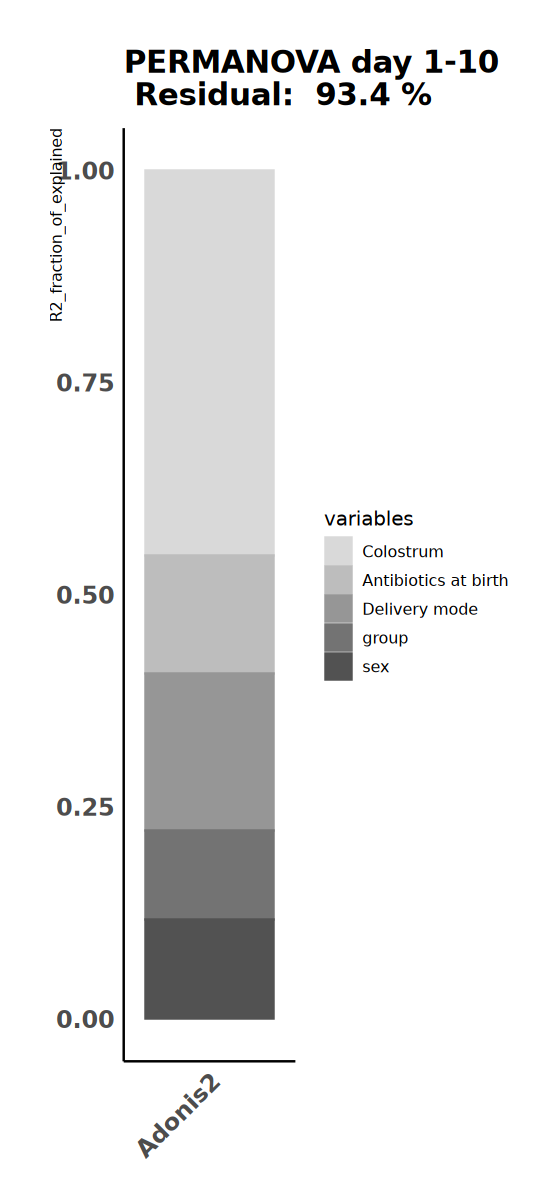

In [157]:
library("microshades")
library("hrbrthemes")

options(repr.plot.width = 4.5, repr.plot.height = 10)

stacked_barplot = ggplot(data = adonis_2_results_permdisp, aes(x = variance_variable, y = R2_fraction_of_explained, color = variables, fill = variables)) +

    geom_bar(stat = "identity") +

    scale_color_manual(values = c(
        microshades_palettes$micro_gray[1],
        microshades_palettes$micro_gray[2],
        microshades_palettes$micro_gray[3],
        microshades_palettes$micro_gray[4],
        microshades_palettes$micro_gray[5]
    )) +

    scale_fill_manual(values = c(
        microshades_palettes$micro_gray[1],
        microshades_palettes$micro_gray[2],
        microshades_palettes$micro_gray[3],
        microshades_palettes$micro_gray[4],
        microshades_palettes$micro_gray[5]
        )) +

    #facet_wrap(~variable, scales = "free_x") +

    theme_minimal() +
    theme_ipsum(base_family = "ArialMT") +
    theme(
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(colour = "black"), 
        axis.text.x = element_text(size = 14, face = "bold", angle = 45, hjust = 1), 
        axis.text.y = element_text(size = 14, face = "bold"),
        axis.title.x = element_blank(),
        strip.text = element_text(size = 18, face = "bold", margin = margin()),
        legend.position = "right"
    ) + labs(title = paste("PERMANOVA day 1-10 \n", "Residual: ", round(unique(adonis_2_results_permdisp$Residual), 3)*100, "%"))

stacked_barplot
ggsave("../output/metagenomics/betadiv/adonis2_1-10d.pdf", stacked_barplot, width = 4.5, height = 10)

stacked_barplot <- NULL

#### Plotting PCA

In [29]:
traj_fill_cols = c('#FCBA6F', '#5E4C5F')
traj_cols = c('#FFAA48', '#49374A')

In [ ]:
### MOD PCA
# Perform PCA on genus CLR data
pca_result <- prcomp(genus_clr_10d, scale = FALSE)

# Extract PC scores
pc_scores <- data.frame(pca_result$x[, 1:2])
pc_scores$Sample <- rownames(pc_scores)

# Add metadata
pc_scores$IFNG_category <- atse_10d_md$IFNG_category
pc_scores$mode_delivery <- atse_10d_md$mode_delivery
pc_scores$interaction_group <- interaction(atse_10d_md$IFNG_category, atse_10d_md$mode_delivery)

# Calculate mean points for each interaction group
mean_points <- pc_scores %>%
    group_by(interaction_group, IFNG_category, mode_delivery) %>%
    summarise(
        mean_PC1 = mean(PC1),
        mean_PC2 = mean(PC2),
        .groups = 'drop'
    )

# Calculate variance explained
var_explained <- summary(pca_result)$importance[2, 1:2] * 100

# Create PCA plot with mean points
library(ggplot2)
pca_plot <- ggplot(pc_scores, aes(x = PC1, y = PC2)) +

    geom_hline(yintercept = 0, color = "black", linetype = "dashed") +
    geom_vline(xintercept = 0, color = "black", linetype = "dashed") +
    
    # Add individual points
    geom_point(aes(color = IFNG_category, shape = mode_delivery), 
               size = 5, alpha = 0.5) +
    
    # Add group center points
    geom_point(data = mean_points, 
               aes(x = mean_PC1, y = mean_PC2, 
                   color = IFNG_category, shape = mode_delivery),
               size = 9, stroke = 2,  alpha = 1) +

    
    scale_color_manual(values = traj_fill_cols) +
    scale_shape_manual(values = c(16, 17)) +
    labs(
        x = paste0("PC1 (", round(var_explained[1], 1), "%)"),
        y = paste0("PC2 (", round(var_explained[2], 1), "%)"),
        color = "IFNG Category",
        shape = "Mode of Delivery"
    ) +
    theme_ipsum(base_family = "ArialMT") +
    theme(
        legend.position = "right",
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_text(size = 20),
        axis.title.y = element_text(size = 20),
        panel.grid.minor = element_blank()
    ) + xlim(-19, 19) #filtering outliers

options(repr.plot.width = 11, repr.plot.height = 9)
pca_plot
ggsave("../output/metagenomics/betadiv/aitchison_genus_10d-allSubs-Vag-Csection-IFNG-categories-outliersRemoved.pdf", pca_plot, width = 11, height = 9)

In [ ]:
options(repr.plot.width = 11, repr.plot.height = 9)

aitchison_loadings = fviz_pca_var(pca_result,
            select.var = list(contrib = 15),
            col.var = "contrib", # Color by the quality of representation
            gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
            repel = TRUE,     # Avoid text overlapping
            labelsize = 5     # Make text bigger
            )  +
    theme_ipsum(base_family = "ArialMT") +
    theme(
        legend.position = "right",
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_text(size = 20),
        axis.title.y = element_text(size = 20),
        panel.grid.minor = element_blank()
    ) 
             
aitchison_loadings
ggsave("../output/metagenomics/betadiv/aitchison_species_10d_top15_loadings-allSubs-IFNG-categories.pdf", aitchison_loadings, width = 11, height = 9)
aitchison_loadings <- NULL

### Looking at select species at genus level

In [33]:
Tax_genus = Tax %>% distinct(genus, .keep_all = TRUE)

genus_to_plot = genus_clr %>% otu_table() %>% data.frame()
genus_to_plot$genus = rownames(genus_to_plot)
genus_to_plot = genus_to_plot %>% 
    melt(id.vars = "genus") %>% 
    dplyr::rename(Sample = variable) %>%
    merge(Tax_genus, by = "genus") %>%
    merge(atse_md, by = "Sample") %>%
    #subset(group == "Term") %>%
    subset(BinGroupStr %in% c("t1")) %>%
    subset(!is.na(IFNG_category))

In [ ]:
bacteroidia = genus_to_plot %>% 
    subset(genus %in% c("g__Parabacteroides", "g__Phocaeicola", "g__Bacteroides")) %>% 
    group_by(Sample, IFNG_category, mode_delivery) %>% 
    summarise(mean_clr = mean(value)) %>%
    mutate(genus = "bacteroidia/phocaeicola/parabacteroides")

bifido = genus_to_plot %>% 
    subset(genus %in% c("g__Bifidobacterium")) %>% 
    group_by(Sample, IFNG_category, mode_delivery) %>% 
    summarise(mean_clr = mean(value)) %>%
    mutate(genus = "bifido")

veillonella = genus_to_plot %>% 
    subset(genus %in% c("g__Veillonella", "g__Veillonella_A")) %>% 
    group_by(Sample, IFNG_category, mode_delivery) %>% 
    summarise(mean_clr = mean(value)) %>%
    mutate(genus = "veillonella")

escherichia = genus_to_plot %>% 
    subset(genus %in% c("g__Escherichia")) %>% 
    group_by(Sample, IFNG_category, mode_delivery) %>% 
    summarise(mean_clr = mean(value)) %>%
    mutate(genus = "escherichia")

klebsiella = genus_to_plot %>% 
    subset(genus %in% c("g__Klebsiella")) %>% 
    group_by(Sample, IFNG_category, mode_delivery) %>% 
    summarise(mean_clr = mean(value)) %>%
    mutate(genus = "klebsiella")

clostridium = genus_to_plot %>% 
    subset(genus %in% c("g__Clostridium_AP", "g__Clostridium", "g__Clostridium_F", "g__Clostridium_AQ", "g__Clostridium_A", "g__Clostridium_E", "g__Clostridium_Q")) %>% 
    group_by(Sample, IFNG_category, mode_delivery) %>% 
    summarise(mean_clr = mean(value)) %>%
    mutate(genus = "clostridium")


genus_collected = rbind(bacteroidia, bifido, veillonella, escherichia, klebsiella, clostridium)
genus_collected$genus = factor(genus_collected$genus, levels = c("bacteroidia/phocaeicola/parabacteroides", "bifido", "veillonella", "escherichia", "klebsiella", "clostridium"))

In [ ]:
library("hrbrthemes")

traj_fill_cols = c('#FCBA6F', '#5E4C5F')
traj_cols = c('#FFAA48', '#49374A')

options(repr.plot.width = 30, repr.plot.height = 10)
plot = ggplot(genus_collected, aes(x = IFNG_category, y = mean_clr, color = IFNG_category, fill = IFNG_category)) +

    geom_point(position = position_jitter(width = 0.2, height = 0)) +

    geom_boxplot(aes(x = IFNG_category, y = mean_clr), lwd = 0.0001, fatten = 25000, width = 0.5, alpha = 0.65, fill = NA, color = "black", outlier.shape = NA) +
    geom_boxplot(aes(x = IFNG_category, y = mean_clr), width = 0.5, alpha = 0.65) +

    facet_wrap(~interaction(genus, mode_delivery), scales = "free", ncol = 6) +

    scale_color_manual(values = traj_cols) +
    scale_fill_manual(values = traj_fill_cols) +

    theme_ipsum(base_family = "ArialMT") +
    theme(
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_text(size = 20),
        axis.title.y = element_text(size = 20),
        panel.grid.minor = element_blank()
    ) +
    labs(x = "IFNG Category", y = "CLR")

plot
ggsave("../output/metagenomics/DA/specific_genera_1-10d.pdf", plot, width = 30, height = 10)
plot <- NULL

In [ ]:
# Calculate stats
genus_stats <- genus_collected %>%
  #subset(group == "Term") %>%
  group_by(genus, mode_delivery) %>%
  summarise(
    wilcox_p = wilcox.test(mean_clr ~ IFNG_category)$p.value,
    ttest_p = t.test(mean_clr ~ IFNG_category)$p.value,
    n_low = sum(IFNG_category == "IFNgLOW"),
    n_high = sum(IFNG_category == "IFNgHIGH"),
    direction = ifelse(
      mean(mean_clr[IFNG_category == "IFNgHIGH"], na.rm = TRUE) > mean(mean_clr[IFNG_category == "IFNgLOW"], na.rm = TRUE),
      "higher_in_IFNgHIGH", "higher_in_IFNgLOW"
    ),
    .groups = "drop"
  )


write.csv(genus_stats, "../output/metagenomics/DA/grouped_genus_MoD_wilcoxon_t.test_stats.csv")

genus_stats %>% arrange(ttest_p)

### Differential Abundance IFNG HIGH and LOW

In [ ]:
library("ALDEx2"); packageVersion("ALDEx2")

options(repr.matrix.max.cols = 100)

In [46]:
run_aldex <- function(df, md, threshold_, name, filtering_, subset_) {
    # name e.g. genus
    # subset e.g. prevalence_filtered
    
    
    subdir_path = paste("../output/metagenomics/DA/ALDEX2/", threshold_, "/", name, "/", filtering_, "/", subset_, sep="")
    if (!dir.exists(subdir_path)) {
        dir.create(subdir_path, recursive = TRUE)
        message(paste("Directory", subdir_path, "created."))
    } else {
        message(paste("Directory", subdir_path, "already exists."))
    }
    
    
    ### format metadata and otus
#    md = subset(md, grepl(threshold_, BinGroupStr))
    df = data.frame(df, check.names = FALSE)[, rownames(md)] # subsets taxa data to only include samples in metadata
    
    ### model matrix
    mm = model.matrix(~ IFNG_category, md)
    
    ###########################################################
    ### ADD BABY AGE BACK TO FORMULA WHEN DOING ALL SAMPLES ###
    ###########################################################

    
    ### run aldex2
    x <- aldex.clr(df, mm, mc.samples=256, denom="all", verbose=F)
    glm.test <- aldex.glm(x, mm)
    glm.effect <- aldex.glm.effect(x, CI=TRUE)
    
    
    ### find columns of interest
    glm.test.columns = grep("Intercept", names(glm.test), value = TRUE, invert = TRUE)
    pval_columns <- grep("pval", glm.test.columns, value = TRUE)
    pval_noHolm_columns <- grep("holm", pval_columns, value = TRUE, invert = TRUE)
    pval_Holm_columns <- grep("holm", pval_columns, value = TRUE, invert = FALSE)
    
    Est_columns <- grep("Est", glm.test.columns, value = TRUE)

    # subset the dataframe to keep only these columns
    glm.test.pval <- glm.test[, pval_noHolm_columns]
    glm.test.Est <- glm.test[, Est_columns]

    
    glm.test_path = paste("../output/metagenomics/DA/ALDEX2/", threshold_, "/", name, "/", filtering_, "/", subset_, "/", threshold_, "_", name, "_", filtering_, "_", subset_, "_glm.test.csv", sep="")
    print(glm.test_path)
    write.csv(glm.test, glm.test_path)
        
}

In [370]:
species_relabundance_otu_adj = read.csv("../input/metagenomics/atlas/species_relabundance_otu_counts_adj.csv", row.names = "X")

In [42]:
aldex_metadata = atse_md %>% subset(!is.na(IFNG_category))
aldex_metadata$IFNG_category = factor(aldex_metadata$IFNG_category, levels = c("IFNgHIGH", "IFNgLOW"))

In [ ]:
aldex_t1_vaginal = aldex_metadata %>% subset(mode_delivery == "Vaginal") %>% subset(!is.na(IFNG_category))
rownames(aldex_t1_vaginal) = aldex_t1_vaginal$Sample

aldex_t1_c_section = aldex_metadata %>% subset(mode_delivery == "C-section") %>% subset(!is.na(IFNG_category))
rownames(aldex_t1_c_section) = aldex_t1_c_section$Sample

In [ ]:
### IFNG category without fixed effects
### species
run_aldex(species_relabundance_otu_adj, aldex_t1_vaginal, "t1", "species", "IFNG_category", "Vaginal") # Vaginal 1-10d

run_aldex(species_relabundance_otu_adj, aldex_t1_c_section, "t1", "species", "IFNG_category", "C_section") # C section 1-10d

In [49]:
format_species = function(input_csv, tax_table) {

    input_csv = input_csv %>%
        dplyr::rename(user_genome = "X") %>% dplyr::select(c("user_genome", "IFNG_categoryIFNgLOW.Est", "IFNG_categoryIFNgLOW.pval", "IFNG_categoryIFNgLOW.pval.padj")) %>%
        dplyr::rename(estimate = "IFNG_categoryIFNgLOW.Est", pval = "IFNG_categoryIFNgLOW.pval", pval.padj = "IFNG_categoryIFNgLOW.pval.padj") %>% 
        mutate(p.BH = p.adjust(pval, method = "BH")) %>%
        merge(Tax[, c("species", "genus", "family", "order", "class", "user_genome")], by = "user_genome", all.y = TRUE) %>%
        arrange(pval) %>%
        mutate(estimate = ifelse(is.na(estimate), 0, estimate)) %>%
        arrange(class, estimate) %>%
        mutate(significance = ifelse(pval < 0.05, "Significant, not FDR checked", "not sign")) %>%
        mutate(color_column = ifelse(

            pval < 0.05 & -estimate > 0, "IFNgHIGH significant", ifelse(
            pval < 0.05 & -estimate < 0, "IFNgLOW significant", "not significant"
        )))


    input_csv$user_genome = factor(input_csv$user_genome, levels = input_csv$user_genome)

    return(input_csv)

}

In [50]:
Tax_genus = Tax %>% distinct(genus, .keep_all = TRUE)

### VAGINAL
vag_t1_DA = read.csv("../output/metagenomics/DA/ALDEX2/t1/species/IFNG_category/Vaginal/t1_species_IFNG_category_Vaginal_glm.test.csv") %>% format_species(tax_table = Tax) %>% 
    mutate(pval = ifelse(is.na(pval), 1, pval)) %>%
    mutate(estimate = ifelse(is.na(estimate), 0, estimate))


In [ ]:
options(repr.plot.width = 15, repr.plot.height = 10)

vag_t1_DA_plot = vag_t1_DA %>% 
    mutate(color_column = ifelse(abs(estimate) > 1, class, "no color")) %>%
    mutate(color_column = ifelse(color_column %in% c("c__Actinomycetia", "c__Bacteroidia", "c__Bacilli", "c__Clostridia", "c__Gammaproteobacteria", "c__Negativicutes"), class, "no color")) %>%
    mutate(color_column = factor(color_column, levels = c("c__Actinomycetia", "c__Bacteroidia", "c__Bacilli", "c__Clostridia", "c__Gammaproteobacteria", "c__Negativicutes", "no color")))


plot = ggplot(data = vag_t1_DA_plot, aes(x = -estimate, y = -log10(pval), color = color_column, fill = color_column)) +

    geom_point(aes(size = ifelse(abs(estimate) > 1, 7, 5)), alpha = 0.75) +
    
    geom_text_repel(aes(label = species), size = 5, max.overlaps = 7, fontface = "bold") +

    geom_hline(yintercept = -log10(0.05), linetype = "dashed", col = "black") +

    geom_vline(xintercept = c(-1,1), linetype = "dashed", col = "black") +

    scale_color_manual(values = c(
        "c__Actinomycetia" = microshades_palettes$micro_orange[5],
        "c__Bacteroidia" = microshades_palettes$micro_purple[5],
        "c__Bacilli" = microshades_palettes$micro_brown[5],
        "c__Clostridia" = microshades_palettes$micro_green[5],
        "c__Gammaproteobacteria" = microshades_palettes$micro_blue[5],
        "c__Negativicutes" = microshades_cvd_palettes$micro_gray[4],
        "no color" = "black")) +

    scale_fill_manual(values = c(
        "c__Actinomycetia" = microshades_palettes$micro_orange[5],
        "c__Bacteroidia" = microshades_palettes$micro_purple[5],
        "c__Bacilli" = microshades_palettes$micro_brown[5],
        "c__Clostridia" = microshades_palettes$micro_green[5],
        "c__Gammaproteobacteria" = microshades_palettes$micro_blue[5],
        "c__Negativicutes" = microshades_palettes$micro_gray[4],
        "no color" = "black")) +

    theme_ipsum(base_family = "ArialMT") + 
    theme(
        axis.text.x = element_text(size = 16, face = "bold"),
        axis.text.y = element_text(size = 16, face = "bold"),
        axis.title.x = element_text(size = 18, face = "bold"),
        axis.title.y = element_text(size = 18, face = "bold"),
        strip.text = element_text(size = 20, face = "bold", margin = margin()),
        legend.position = "top"
    ) + labs(x = "ALDEx2 estimate ----> IFNg HIGH")

plot

ggsave("../output/metagenomics/DA/ALDEX2/t1/species/IFNG_category/Vaginal/vag_t1_DA-volcano.pdf", plot, width = 15, height = 10)

plot <- NULL

In [52]:
### C-SECTION
csec_t1_DA = read.csv("../output/metagenomics/DA/ALDEX2/t1/species/IFNG_category/C_section/t1_species_IFNG_category_C_section_glm.test.csv") %>% format_species(tax_table = Tax) %>% 
    mutate(pval = ifelse(is.na(pval), 1, pval)) %>%
    mutate(estimate = ifelse(is.na(estimate), 0, estimate))

In [ ]:
options(repr.plot.width = 15, repr.plot.height = 10)

csec_t1_DA_plot = csec_t1_DA %>% 
    mutate(color_column = ifelse(abs(estimate) > 1, class, "no color")) %>%
    mutate(color_column = ifelse(color_column %in% c("c__Actinomycetia", "c__Bacteroidia", "c__Bacilli", "c__Clostridia", "c__Gammaproteobacteria", "c__Negativicutes"), class, "no color")) %>%
    mutate(color_column = factor(color_column, levels = c("c__Actinomycetia", "c__Bacteroidia", "c__Bacilli", "c__Clostridia", "c__Gammaproteobacteria", "c__Negativicutes", "no color")))


plot = ggplot(data = csec_t1_DA_plot, aes(x = -estimate, y = -log10(pval), color = color_column, fill = color_column)) +

    geom_point(aes(size = ifelse(abs(estimate) > 1, 7, 5)), alpha = 0.75) +
    
    geom_text_repel(aes(label = species), size = 5, max.overlaps = 7, fontface = "bold") +

    geom_hline(yintercept = -log10(0.05), linetype = "dashed", col = "black") +

    geom_vline(xintercept = c(-1,1), linetype = "dashed", col = "black") +

    scale_color_manual(values = c(
        "c__Actinomycetia" = microshades_palettes$micro_orange[5],
        "c__Bacteroidia" = microshades_palettes$micro_purple[5],
        "c__Bacilli" = microshades_palettes$micro_brown[5],
        "c__Clostridia" = microshades_palettes$micro_green[5],
        "c__Gammaproteobacteria" = microshades_palettes$micro_blue[5],
        "c__Negativicutes" = microshades_cvd_palettes$micro_gray[4],
        "no color" = "black")) +

    scale_fill_manual(values = c(
        "c__Actinomycetia" = microshades_palettes$micro_orange[5],
        "c__Bacteroidia" = microshades_palettes$micro_purple[5],
        "c__Bacilli" = microshades_palettes$micro_brown[5],
        "c__Clostridia" = microshades_palettes$micro_green[5],
        "c__Gammaproteobacteria" = microshades_palettes$micro_blue[5],
        "c__Negativicutes" = microshades_palettes$micro_gray[4],
        "no color" = "black")) +

    theme_ipsum(base_family = "ArialMT") + 
    theme(
        axis.text.x = element_text(size = 16, face = "bold"),
        axis.text.y = element_text(size = 16, face = "bold"),
        axis.title.x = element_text(size = 18, face = "bold"),
        axis.title.y = element_text(size = 18, face = "bold"),
        strip.text = element_text(size = 20, face = "bold", margin = margin()),
        legend.position = "top"
    ) + labs(x = "ALDEx2 estimate ----> IFNg HIGH")

plot
ggsave("../output/metagenomics/DA/ALDEX2/t1/species/IFNG_category/C_section/csec_t1_DA-volcano.pdf", plot, width = 15, height = 10)
plot <- NULL

# Mass Spec data

### Library

In [54]:
library("readxl")
library("dplyr")
library("ggplot2")
library("tidyr")
library("reshape2")
library("microshades")
library("hrbrthemes")
#library("ggpubr")
library("ggrepel")
library("stringr")

In [55]:
impute_min_value <- function(data) {
    # this function imputes non-zero minimum value for subject, timepoint and compound based on the min value of the compound across all timepoints

    compound_min_values = data %>% subset(value != 0) %>% subset(!is.na(value)) %>% group_by(Compound) %>% summarise(min_value = min(value, na.rm = TRUE))
    compound_min_values$min_value = compound_min_values$min_value

    data = merge(data, compound_min_values, by = "Compound", all.x = TRUE)

    data$value_imputed = ifelse((is.na(data$value) | data$value == 0), data$min_value/2, data$value)

    return(data)

}

## Experiment 1

In [372]:
MS_exp_1 = read.csv("../input/mass-spec//MS-exp1.csv", row.names = "X") 

MS_exp_1$BinGroupStr = factor(MS_exp_1$BinGroupStr, levels = c("CB", "1w", "3m"))

MS_exp_1 = impute_min_value(MS_exp_1)

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 7)
MS_pilot_plot = ggplot(data = MS_exp_1, aes(x = BinGroupStr, y = value)) + 
    geom_point() + 
    geom_line(aes(group = subject)) +
    facet_wrap(~Compound, scales = "free") +

    theme_minimal() + 
    theme(
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(colour = "black"), 
        axis.text.x = element_text(size = 14, face = "bold"), 
        axis.text.y = element_text(size = 14, face = "bold"),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_text(size = 16, face = "bold"),
        strip.text = element_text(size = 14, face = "bold", margin = margin()),
        legend.position = "top")

ggsave("../output/mass-spec/MS_pilot_plot.pdf", MS_pilot_plot, height = 7, width = 14)

MS_pilot_plot
MS_pilot_plot <- NULL

## Experiment 2

In [374]:
MS_exp_2 = read.csv("../input//mass-spec//MS-exp2.csv", row.names = "X") 

MS_exp_2$BinGroupStr = factor(MS_exp_2$BinGroupStr, levels = c("CB", "1w", "3m"))

In [ ]:
options(repr.plot.width = 15, repr.plot.height = 10)
a = ggplot(data = MS_exp_2, 
        aes(x = BinGroupStr, 
        y = (value_imputed))) + 
    
    geom_point(size = 3.75, position = position_jitter(width = 0.1, height = 0), alpha = 0.75) + 
    
    geom_boxplot(
            outlier.shape = NA, lwd = 0.000070, fatten = 25000, alpha = 0.0001, width = 0.35, col = "red") +

    geom_boxplot(
            outlier.shape = NA, lwd = 0.05, alpha = 0.1, width = 0.35, fill = "black", col = "black") +


    geom_line(aes(group = subject), alpha = 0.2) +
    
    facet_wrap(~Compound, scales = "free") +

    theme_minimal() + 
    theme(
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(colour = "black"), 
        axis.text.x = element_text(size = 14, face = "bold"), 
        axis.text.y = element_text(size = 14, face = "bold"),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_text(size = 16, face = "bold"),
        strip.text = element_text(size = 14, face = "bold", margin = margin()),
        legend.position = "top")

ggsave("../output/mass-spec/MS_exp2_absolute.pdf", a, width = 15, height = 10)
a
a <- NULL

## Experiment 3

In [376]:
MS_exp_3 = read.csv("../input//mass-spec/MS_exp_3.csv", row.names = "X")
MS_exp_3$BinGroupStr = factor(MS_exp_3$BinGroupStr, levels = c("CB", "1w", "3m"))

In [ ]:
### BATCH 3 NATIVE DATA

options(repr.plot.width = 14, repr.plot.height = 9)
a = ggplot(data = MS_exp_3, 
        aes(x = BinGroupStr, 
        y = (value_imputed))) +

    geom_point(size = 3.75, position = position_jitter(width = 0.1, height = 0), alpha = 0.75) + 
    

    geom_boxplot(
            outlier.shape = NA, lwd = 0.000070, fatten = 25000, alpha = 0.0001, width = 0.35, col = "red") +

    geom_boxplot(
            outlier.shape = NA, lwd = 0.05, alpha = 0.1, width = 0.35, fill = "black", col = "black") +


    geom_line(aes(group = subject), alpha = 0.2) +
    
    facet_wrap(~Compound, scales = "free") +

    theme_minimal() + 
    theme(
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(colour = "black"), 
        axis.text.x = element_text(size = 14, face = "bold"), 
        axis.text.y = element_text(size = 14, face = "bold"),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_text(size = 16, face = "bold"),
        strip.text = element_text(size = 14, face = "bold", margin = margin()),
        legend.position = "top")

a 
ggsave("../output/mass-spec/MS_batch_3_samples_absolute.pdf", a, height = 9, width = 14)
a <- NULL

## COMBAT CORRECTION

### Doing the correction

In [65]:
library("dplyr")
library("tidyr")
library("sva")

In [69]:
batch_3_data = MS_exp_3 %>% 
    dplyr::select(Compound, subject, BinGroupStr, value_imputed) %>% 
    dplyr::mutate(batch = "batch_3")

batch_2_data = MS_exp_2 %>% 
    dplyr::select(Compound, subject, BinGroupStr, value_imputed) %>% 
    dplyr::mutate(batch = "batch_2")

batch_1_data = MS_exp_1 %>% 
    dplyr::select(Compound, subject, BinGroupStr, value_imputed) %>% 
    dplyr::mutate(batch = "batch_1")

In [15]:
MS_batch_1_2_3 = rbind(batch_1_data, batch_2_data, batch_3_data)
MS_batch_2_3 = rbind(batch_2_data, batch_3_data) 

In [21]:
### This function is run twice, once with MS_batch_1_2_3 and once with MS_batch_2_3.
### Comment out depending on which one is being run. we merge both of these in the end.
### This is becuase 3-hydroxytridecanoic acid which is only present in batch 1 is not present in batch 2 and 3.
### This is becuase NAM and NAG is only present in batch 2 and 3, not batch 1

#df <- MS_batch_1_2_3 %>%
df <- MS_batch_2_3 %>%
  mutate(
    batch       = as.character(batch),
    subject     = as.character(subject),
    BinGroupStr = as.character(BinGroupStr),
    SampleID    = paste(batch, subject, BinGroupStr, sep = "_")
  )


df <- df %>%
  mutate(value_log = log1p(value_imputed))


# expression matrix
wide <- df %>%
  distinct(Compound, SampleID, .keep_all = TRUE) %>%
  dplyr::select(Compound, SampleID, value_log) %>%
  pivot_wider(names_from = SampleID, values_from = value_log)


# drop rows (compounds) with any NA in any column
wide_complete <- wide[stats::complete.cases(wide), , drop = FALSE]

expr_mat <- as.matrix(wide_complete[ , -1, drop = FALSE])
rownames(expr_mat) <- wide_complete$Compound

sample_meta <- df %>%
  distinct(SampleID, batch, BinGroupStr)

sample_meta <- sample_meta %>%
  slice(match(colnames(expr_mat), SampleID))

batch_vec <- factor(sample_meta$batch) # batch effect
mod <- model.matrix(~ BinGroupStr, data = sample_meta) # covariate to preserve

# Running combat correction
expr_mat_combat <- ComBat(dat = expr_mat,
                          batch = batch_vec,
                          mod = mod,
                          par.prior = TRUE,      # try FALSE if parametric EB looks off
                          prior.plots = FALSE,
                          mean.only = FALSE)


combat_wide <- cbind(Compound = rownames(expr_mat_combat),
                     as.data.frame(expr_mat_combat))

combat_long <- combat_wide %>%
  pivot_longer(cols = -Compound, names_to = "SampleID", values_to = "value_combat_log") %>%
  left_join(sample_meta, by = "SampleID")

# merging back to original table
df_combat <- df %>%
  dplyr::select(Compound, subject, BinGroupStr, batch, SampleID) %>%
  distinct() %>%
  left_join(combat_long, by = c("Compound", "SampleID", "batch", "BinGroupStr"))

#df_combat_batch_1_2_3 <- df_combat %>%
#  mutate(value_combat_lin = expm1(value_combat_log))

df_combat_batch_2_3 <- df_combat %>%
  mutate(value_combat_lin = expm1(value_combat_log))

Found2batches

Adjusting for2covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data




In [26]:
df_combat_batch_1_2_3 = df_combat_batch_1_2_3 %>% subset(!Compound %in% c("3-Hydroxytridecanoic acid", "N-acetylglucosamine", "N-acetylmuramic acid"))
df_combat_batch_2_3 = df_combat_batch_2_3 %>% subset(!(Compound %in% unique(df_combat_batch_1_2_3$Compound)))


batch_2_data_tridecanoic = batch_2_data %>% 
    subset(Compound == "3-Hydroxytridecanoic acid") %>% 
    dplyr::rename(value_combat_log = value_imputed) %>%
    mutate(value_combat_log = log10(value_combat_log)) %>%
    mutate(SampleID = paste0(batch, "_", subject, "_", BinGroupStr)) %>%
    mutate(value_combat_lin = value_combat_log)

In [ ]:
df_combat = rbind(df_combat_batch_1_2_3, df_combat_batch_2_3)

#write.csv(df_combat, "../input/mass-spec/MS_batch_1-2-3-COMBAT.csv")

### Post correction analyses

In [379]:
df_combat = read.csv("../input//mass-spec//MS_batch_1-2-3-COMBAT.csv", row.names = "X")

batch_2_data = MS_exp_2 %>% 
    dplyr::select(Compound, subject, BinGroupStr, value_imputed) %>% 
    dplyr::mutate(batch = "batch_2")

batch_2_data_tridecanoic = batch_2_data %>% 
    subset(Compound == "3-Hydroxytridecanoic acid") %>% 
    dplyr::rename(value_combat_log = value_imputed) %>%
    mutate(value_combat_log = log10(value_combat_log)) %>%
    mutate(SampleID = paste0(batch, "_", subject, "_", BinGroupStr)) %>%
    mutate(value_combat_lin = value_combat_log)

In [ ]:
library("distributional")
library("ggdist")
library("ggstar")


plot_data = df_combat %>% subset(Compound != "3-Hydroxytridecanoic acid")# %>% subset(cb_missing == FALSE) %>% subset(batch == "batch_3") #%>% subset(!is.na(IFNG_category))
plot_data = rbind(plot_data, batch_2_data_tridecanoic)

plot_data = plot_data %>% 
        mutate(shape_column = ifelse(
                Compound %in% c("N-acetylglucosamine"), "Peptidoglycan and Human", ifelse(
                Compound %in% c("N-acetylmuramic acid"), "Primarily Peptidoglycan", ifelse(
                Compound %in% c("Myristic acid", "Palmitic acid"), "LPS and Human", "Primarily LPS")))) %>%

        mutate(size_column = ifelse(
                shape_column == "Peptidoglycan and Human", 5, ifelse(
                shape_column == "Primarily Peptidoglycan", 4, ifelse(
                shape_column == "Primarily LPS", 4, 5))))

plot_data$BinGroupStr = factor(plot_data$BinGroupStr, levels = c("CB", "1w", "3m"))

plot_data$Compound = factor(plot_data$Compound, levels = c(
        "3-Hydroxydodecanoic acid", "3-Hydroxyhexadecanoic acid", "3-Hydroxytetradecanoic acid", "3-Hydroxytridecanoic acid", 
        "Myristic acid", "Palmitic acid",
        "N-acetylglucosamine", "N-acetylmuramic acid"))

options(repr.plot.width = 25, repr.plot.height = 10)
a = ggplot(data = plot_data, 
        aes(x = BinGroupStr, 
        y = value_combat_log)) +

    geom_star(aes(starshape = shape_column), size = 4, fill = "black", position = position_jitter(width = 0.1, height = 0), alpha = 0.75) + 

    geom_boxplot(
            outlier.shape = NA, lwd = 0.000070, fatten = 25000, alpha = 0.0001, width = 0.35, col = "red") +

    geom_boxplot(
            outlier.shape = NA, lwd = 0.05, alpha = 0.1, width = 0.35, fill = "black", col = "black") +

    scale_starshape_manual(values = c("Peptidoglycan and Human" = 22, "Primarily Peptidoglycan" = 14, "Primarily LPS" = 15, "LPS and Human" = 28)) +


    geom_line(aes(group = subject), alpha = 0.2) +
    
    facet_wrap(~Compound, scales = "free", ncol = 4) +

    theme_minimal() + 
    theme(
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(colour = "black"), 
        axis.text.x = element_text(size = 14, face = "bold"), 
        axis.text.y = element_text(size = 14, face = "bold"),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_text(size = 16, face = "bold"),
        strip.text = element_text(size = 14, face = "bold", margin = margin()),
        legend.position = "top")


ggsave("../output/mass-spec/MS_batch_1-2-3-COMBAT-filtered-newLayout.pdf", a, height = 10, width = 25)
a 

#### Running LMER

In [74]:

library(lme4)
library(lmerTest)

# Function to run lmer for all compounds and summarize results
run_lmer_analysis <- function(df) {
    # Get unique compounds
    compounds <- unique(df$Compound)
    
    # Initialize results dataframe
    lmer_results <- data.frame(
        Compound = character(),
        estimate = numeric(),
        std_error = numeric(),
        df = numeric(),
        t_value = numeric(),
        p_value = numeric(),
        stringsAsFactors = FALSE
    )
    
    # Loop through each compound
    for(compound_name in compounds) {
        tryCatch({
            # Fit the model for this compound
            fit <- lmer(value_combat_log ~ BinGroupStr + (1 | subject), 
                       data = subset(df, Compound == compound_name))
            
            # Extract coefficients for BinGroupStr effect
            coef_summary <- summary(fit)$coefficients
            
            # Check if BinGroupStr coefficient exists (it should be the second row)
            if(nrow(coef_summary) >= 2) {
                lmer_results <- rbind(lmer_results, data.frame(
                    Compound = compound_name,
                    estimate = coef_summary[2, "Estimate"],
                    std_error = coef_summary[2, "Std. Error"],
                    df = coef_summary[2, "df"],
                    t_value = coef_summary[2, "t value"],
                    p_value = coef_summary[2, "Pr(>|t|)"],
                    stringsAsFactors = FALSE
                ))
            }
        }, error = function(e) {
            # If model fails, add NA row
            lmer_results <<- rbind(lmer_results, data.frame(
                Compound = compound_name,
                estimate = NA,
                std_error = NA,
                df = NA,
                t_value = NA,
                p_value = NA,
                stringsAsFactors = FALSE
            ))
        })
    }
    
    # Add adjusted p-values
    lmer_results$p_value_adj <- p.adjust(lmer_results$p_value, method = "BH")
    
    return(lmer_results)
}


In [ ]:
# Create DFs for analysis
combat_1w_3m = df_combat %>% subset(Compound != "3-Hydroxytridecanoic acid") %>% subset(BinGroupStr %in% c("1w", "3m"))
combat_1w_3m$BinGroupStr = factor(combat_1w_3m$BinGroupStr, levels = c("1w", "3m"))

combat_CB_1w = df_combat %>% subset(Compound != "3-Hydroxytridecanoic acid") %>% subset(BinGroupStr %in% c("CB", "1w"))
combat_CB_1w$BinGroupStr = factor(combat_CB_1w$BinGroupStr, levels = c("CB", "1w"))

combat_CB_3m = df_combat %>% subset(Compound != "3-Hydroxytridecanoic acid") %>% subset(BinGroupStr %in% c("CB", "3m"))
combat_CB_3m$BinGroupStr = factor(combat_CB_3m$BinGroupStr, levels = c("CB", "3m"))


# Run the analysis
lmer_results_1w_3m = run_lmer_analysis(combat_1w_3m) %>% arrange(p_value) %>% mutate(comparison = "1w_3m") 
lmer_results_CB_1w = run_lmer_analysis(combat_CB_1w) %>% arrange(p_value) %>% mutate(comparison = "CB_1w")
lmer_results_CB_3m = run_lmer_analysis(combat_CB_3m) %>% arrange(p_value) %>% mutate(comparison = "CB_3m")

In [76]:
lmer_results = rbind(lmer_results_1w_3m, lmer_results_CB_1w, lmer_results_CB_3m) %>% 
    mutate(p.adj = p.adjust(p_value, method = "BH")) %>% 
    arrange(comparison, p.adj, p_value_adj) %>%
    dplyr::select(Compound, comparison, p_value, p.adj) %>%
    mutate(test = "lmer (1 | subject)")

In [77]:
write.csv(lmer_results, "../output/mass-spec/MS_batch_1-2-3-COMBAT-lmer.csv")

### MS COMBAT PCA

In [78]:
library("tidyr")
library("dplyr")
library("ggplot2")
library("ggrepel")

In [79]:
IFNG_subs = read.csv("../input/metadata/IFNG-subs-log2FC-unfiltered-feb10_2026.csv", row.name = "X")

df_combat_1w = read.csv("../input/mass-spec/MS_batch_1-2-3-COMBAT.csv", row.names = "X") %>% 
    mutate(rows_to_filter = ifelse( # extreme outliers driving the correlations
        SampleID %in% c("batch_3_730_1w", "batch_2_663_1w") & Compound == "N-acetylglucosamine", TRUE, ifelse(
        SampleID == "batch_3_737_1w" & Compound == "N-acetylmuramic acid", TRUE, FALSE
    ))) %>%
    subset(rows_to_filter == FALSE) %>%
    subset(BinGroupStr == "1w") %>%
    subset(Compound != "3-Hydroxytridecanoic acid") 

In [80]:
traj_fill_cols = c('#FCBA6F', '#5E4C5F')
traj_cols = c('#FFAA48', '#49374A')

# Reshape to subjects x compounds (wide format), and also keep BinGroupStr for later
pca_data <- df_combat_1w %>%
  distinct(subject, Compound, .keep_all = TRUE) %>%
  merge(IFNG_subs[, c("subject", "IFNG_category")], by = "subject") %>%
  dplyr::select(Compound, subject, BinGroupStr, value_combat_lin, IFNG_category) %>%
  tidyr::pivot_wider(names_from = Compound, values_from = value_combat_lin)

# Store IFNG_category and BinGroupStr for plotting/grouping
IFNG_category_col <- pca_data$IFNG_category
BinGroupStr_col <- pca_data$BinGroupStr

# Remove the subject, IFNG_category, and BinGroupStr columns for PCA, keep for plotting
pca_matrix <- pca_data %>% dplyr::select(-subject, -IFNG_category, -BinGroupStr) %>% as.data.frame()

# Remove columns with all NA (optional)
pca_matrix <- pca_matrix[, colSums(is.na(pca_matrix)) < nrow(pca_matrix)]

# Impute missing values (mean impute)
for(i in seq_along(pca_matrix)) {
  nas <- is.na(pca_matrix[[i]])
  if(any(nas)) {
    pca_matrix[[i]][nas] <- mean(pca_matrix[[i]], na.rm=TRUE)
  }
}

# Perform PCA
pca_result <- prcomp(pca_matrix, scale. = TRUE)

# Calculate explained variance for PC axes
explained_var <- pca_result$sdev^2 / sum(pca_result$sdev^2)
explained_var_percent <- explained_var * 100

# Add PC1 and PC2 to scores for plotting, also attach groupings
pca_scores <- as.data.frame(pca_result$x)
pca_scores$subject <- pca_data$subject
pca_scores$IFNG_category <- IFNG_category_col
pca_scores$BinGroupStr <- BinGroupStr_col

# --- Add loadings (variable contributions, week 1) ---
loadings_w1 <- as.data.frame(pca_result$rotation)
loadings_w1$Compound <- rownames(loadings_w1)

top_loadings_PC1 <- head(loadings_w1[order(-abs(loadings_w1$PC1)),], 10)
top_loadings_PC2 <- head(loadings_w1[order(-abs(loadings_w1$PC2)),], 10)

# Calculate centroids by IFNG_category instead of BinGroupStr
centroids <- pca_scores %>%
    group_by(IFNG_category) %>%
    summarise(
      PC1 = mean(PC1, na.rm = TRUE),
      PC2 = mean(PC2, na.rm = TRUE)
    )

MS_PCA_w1 = ggplot(pca_scores, aes(x = PC1, y = PC2, label = subject, color = IFNG_category)) +
    geom_point(size = 5, alpha = 0.5) +
    #geom_text(nudge_y = 0.2, size = 3) +
    geom_point(data = centroids, aes(x = PC1, y = PC2, color = IFNG_category), 
               size = 8, shape = 19, stroke = 2, show.legend = FALSE, inherit.aes = FALSE) +
    # Optionally add loadings as arrows for first 10 compounds (largest abs loading on PC1 or PC2)
    geom_segment(
      data = top_loadings_PC1,
      aes(x = 0, y = 0, xend = PC1 * 5, yend = PC2 * 5),
      arrow = arrow(length = unit(0.3,"cm")), color = "gray30", inherit.aes = FALSE
    ) +
    geom_text_repel(
      data = top_loadings_PC1,
      aes(x = PC1 * 5, y = PC2 * 5, label = Compound),
      color = "gray30", inherit.aes = FALSE, size = 3, segment.color = 'gray60'
    ) +
    scale_color_manual(values = traj_cols) +
    scale_fill_manual(values = traj_fill_cols) +
    theme_minimal() +
    xlab(paste0("PC1 (", round(explained_var_percent[1], 1), "% variance)")) +
    ylab(paste0("PC2 (", round(explained_var_percent[2], 1), "% variance)")) +
    ggtitle("PCA MS w1 data")

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 8)
MS_PCA_w1
ggsave("../output/mass-spec/MS_combat-corrected-PCA_w1.pdf", MS_PCA_w1, width = 10, height = 8)
MS_PCA_w1 <- NULL

# CyTOF

In [381]:
cytof_md = read.csv("../input/cytof/CyTOF_input.csv", row.names = "X")

In [83]:
# Removing B cells because small numbers
# Removing mem B cells because small numbers
#cytof_md$cytof_B.cells = NULL
#cytof_md$cytof_Memory.B.cells = NULL
cytof_md$cytof_mDC = NULL
cytof_md$cytof_Platelets = NULL
cytof_md$cytof_MSC = NULL

cytof_md$cytof_Neutrophil.Lymphocyte.ratio_log2 <- (cytof_md$cytof_Neutrophils / (cytof_md$cytof_Memory.CD4.T + cytof_md$cytof_Naive.CD4.T + cytof_md$cytof_Memory.CD8.T + cytof_md$cytof_Naive.CD8.T + cytof_md$cytof_Naive.B.cells))
cytof_md$cytof_Neutrophil.Lymphocyte.ratio_log2 = log2(cytof_md$cytof_Neutrophil.Lymphocyte.ratio_log2)

In [ ]:
cytof_md %>% group_by(BinGroupStr, IFNG_category, group) %>% summarise(n = n())

##### GEE


In [85]:
library("gee")

get_vars <- function(df, var_prefix) {
    metabolite_list = grep(paste0("^", var_prefix), colnames(df), value=TRUE)
    
    return(metabolite_list)
}

get_model_coefficients_GEE <- function(var, full_model) {
    
    
    print(var)
    full_coef = t(data.frame(var = coef(full_model)))
    colnames(full_coef) <- paste(colnames(full_coef), ".Est", sep="")
    
    full_z = t(data.frame(var = t(data.frame(summary(full_model)$coefficients))["Robust.z", ]))
    colnames(full_z) <- paste(colnames(full_z), ".pval", sep="")
    full_z = 1 - pnorm(abs(full_z))
    
    full_SE = t(data.frame(var = t(data.frame(summary(full_model)$coefficients))["Robust.S.E.", ]))
    colnames(full_SE) <- paste(colnames(full_SE), ".SE", sep="")
    
    
    full_merged = data.frame(cbind(full_coef, full_z, full_SE), check.names = FALSE)
    full_merged$protein = var
    
    return(full_merged)
    
}

get_model_linear <- function(df, var) {
    
    print(var) # testing
    print(dim(df)) # testing    
 
    
    ### Formulas for the full, reduced and null model
    formula_full <- paste(var, "~IFNG_category", sep = "")
    #formula_null <- paste(var, "~(1|subject)", sep = "")
    
    ### Creating the full, reduced and null model
    # REML = FALSE, otherwise AIC might not be provided
    full_model <- gee(formula = formula_full, data=data.frame(df), id=subject, corstr="independence")
    #null_model <- lmer(formula = formula_null, data=data.frame(df), REML=FALSE)
    
#    model_coefficients = get_model_coef_gee(var, full_model)
    model_coefficients = get_model_coefficients_GEE(var, full_model)
    
    return(model_coefficients)
}
    


iterate_vars <- function(df, var_prefix) {
    
    # input is relab
    # rownames = samples
    # columns are taxa at w/e level + accessory metadata
    # allergens begin with "allergen_*" where * is an unique identifier
    
    # get vars
    
    var_list = get_vars(df, var_prefix)
    
    # get models and null modles
    # get coefficient for models and comparisons to null models
#    models = lapply(var_list, function(x) get_model_linear(df, var=x))
    
    models = lapply(var_list, function(x) {
        tryCatch({
            get_model_linear(df, var=x)
        }, error = function(e) {
            # If an error occurs, this function will run
            cat("An error occurred with variable", x, ":", e$message, "\n")
            # Return NULL or some other indicator of failure for this iteration
            return(NULL)
        })
    })
    
    models_df = do.call(rbind, models)
                    
    return(models_df)
}


process_gee_cytof <- function(df, agegroup, reference_group) {
    df_est = df %>% 
        dplyr::select(contains("Est"), protein) %>% 
        dplyr::select(-contains('ntercept')) %>%
        dplyr::rename_with(~ gsub(".Est", "", .)) %>% 
        melt(id.vars = "protein") %>% dplyr::rename("estimate" = "value")

    df_pval = df %>% 
        dplyr::select(contains("pval"), protein) %>% 
        dplyr::select(-contains('ntercept')) %>%
        dplyr::rename_with(~ gsub(".pval", "", .)) %>% 
        melt(id.vars = "protein") %>% dplyr::rename("pval" = "value")

    df_se = df %>% 
        dplyr::select(contains("SE"), protein) %>% 
        dplyr::select(-contains('ntercept')) %>%
        dplyr::rename_with(~ gsub(".SE", "", .)) %>% 
        melt(id.vars = "protein") %>% dplyr::rename("se" = "value")
    
    df_merged = merge(df_est, df_pval, by = c("protein", "variable"), all = TRUE) %>% 
        merge(df_se, by = c("protein", "variable"), all = TRUE)

    df_merged[["agegroup"]] = agegroup

    df_merged[["variable"]] = gsub("bacteroidia_category", "", df_merged[["variable"]])
    df_merged[["variable"]] = paste(df_merged[["variable"]], reference_group, sep = " vs ")

    return(df_merged)
}

In [86]:
cytof_1w_ifng_category = cytof_md %>% subset(BinGroupStr %in% c("1-6d"))
cytof_3m_ifng_category = cytof_md %>% subset(BinGroupStr %in% c("56-120dd")) 

In [88]:
#GEE_1w_ifng_category = iterate_vars(cytof_1w_ifng_category, "cytof_")
#GEE_3m_ifng_category = iterate_vars(cytof_3m_ifng_category, "cytof_")

In [ ]:
gee_cytof_processed = rbind(
    process_gee_cytof(GEE_1w_ifng_category, "1w", "HIGH"), 
    process_gee_cytof(GEE_3m_ifng_category, "3m", "HIGH")
    )

gee_cytof_processed$pval_BH = p.adjust(gee_cytof_processed$pval, method = "BH")
gee_cytof_processed$pval_bonferroni = p.adjust(gee_cytof_processed$pval, method = "bonferroni")

gee_cytof_processed = gee_cytof_processed %>% arrange(pval)
#write.csv(gee_cytof_processed, "../output/cytof/gee_cytof_IFNG_category-PRETERM-TERM.csv")

In [90]:
cytof_melted = cytof_md %>% 
    #subset(BinGroupStr %in% c("CB", "1-6d", "7-55dd","56-120dd")) %>%
    subset(BinGroupStr %in% c("CB", "1-6d", "56-120dd")) %>%
    mutate(total_CD4_T_cells = rowSums(cbind(cytof_Memory.CD4.T, cytof_Naive.CD4.T, cytof_Tregs), na.rm = TRUE)) %>%
    mutate(total_B_cells = rowSums(cbind(cytof_Naive.B.cells, cytof_Memory.B.cells, cytof_B.cells), na.rm = TRUE)) %>%
    melt(id.vars = c("subject", 
        "sample_id", 
        "BinGroupStr", 
        "BinGroupNumeric", 
        "BinGroupGee", 
        "baby_age",
        "IFNG_category",
        "mode_delivery",
        "group",
        "sex"
        ))

cytof_melted$BinGroupStr = factor(cytof_melted$BinGroupStr, levels = c("CB", "1-6d", "56-120dd"))

In [ ]:
options(repr.plot.width = 37.5, repr.plot.height = 23)
library("distributional")
library("ggdist")

traj_fill_cols = c('#FCBA6F', '#5E4C5F')
traj_cols = c('#FFAA48', '#49374A')

cytof_density_plots = ggplot(data = subset(cytof_melted, group %in% c("Term", "Preterm")), aes(x=BinGroupStr, y=value, col = IFNG_category, fill = IFNG_category)) + 

    geom_point(
        aes(x=BinGroupStr, y=value, fill = IFNG_category, col = IFNG_category), shape = 20, alpha = 1, size = 5, position = position_jitterdodge(dodge.width = -0.75, jitter.width = 0.2, jitter.height = 0, seed = 123)) +

    stat_halfeye(data = subset(cytof_melted, IFNG_category == "IFNgHIGH" & group %in% c("Term", "Preterm")),
        alpha = .75, side = "right",
        point_size = 4.5, normalize = "groups", interval_color = NA, point_color = NA, scale = .5, 
        density = "unbounded", trim = FALSE
    ) +

    stat_halfeye(data = subset(cytof_melted, IFNG_category == "IFNgLOW" & group %in% c("Term", "Preterm")),
        alpha = .75, side = "left",
        point_size = 4.5, normalize = "groups", interval_color = NA, point_color = NA, scale = .5, 
        density = "unbounded", trim = FALSE
    ) +

    scale_fill_manual(values = traj_fill_cols) + 
    scale_color_manual(values = traj_cols) +

    facet_wrap(~variable, scales = "free", ncol = 5) +

    theme_ipsum(base_family = "ArialMT") + 
    theme(
        panel.background = element_blank(),
        panel.border = element_blank(),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(colour = "black"), 
        axis.text.x = element_text(size = 16, face = "bold", angle = 30, hjust = 1, vjust = 1), 
        axis.text.y = element_text(size = 18, face = "bold"),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_text(size = 16, face = "bold"),
        strip.text = element_text(size = 20, face = "bold", margin = margin()),
        legend.position = "top"
    ) + 
    labs(title = "CyTOF extra gating, around 3m of age")

cytof_density_plots
ggsave("../output/cytof/cytof_IFNG_category-PRETERM-TERM-density-scatter.pdf", cytof_density_plots, width = 37.5, height = 23)
cytof_density_plots <- NULL

### Cytof extra gating T CELLS

In [383]:
cytof_extra_gating_preterm_term = read.csv("../input/cytof/cytof_CD4_extra_gating.csv", check.names = FALSE) %>% data.frame() %>% mutate(BinGroupStr = "56-120d")

In [107]:
traj_fill_cols = c('#FCBA6F', '#5E4C5F')
traj_cols = c('#FFAA48', '#49374A')

In [ ]:
options(repr.plot.width = 22, repr.plot.height = 8)

cytof_density_plots = ggplot(data = subset(cytof_extra_gating_preterm_term, group %in% c("Term", "Preterm")), aes(x = BinGroupStr, y = prop_T_cells, fill = IFNG_category, color = IFNG_category)) +

    geom_point(
        aes(x=BinGroupStr, y=prop_T_cells, fill = IFNG_category, col = IFNG_category), shape = 20, alpha = 1, size = 5, position = position_jitterdodge(dodge.width = -0.75, jitter.width = 0.2, jitter.height = 0, seed = 123)) +

   stat_halfeye(data = subset(cytof_extra_gating_preterm_term, IFNG_category == "IFNgHIGH" & group %in% c("Term", "Preterm")),
       alpha = .75, side = "right",
       point_size = 4.5, normalize = "groups", interval_color = NA, point_color = NA, scale = .5, 
       density = "unbounded", trim = FALSE
   ) +

   stat_halfeye(data = subset(cytof_extra_gating_preterm_term, IFNG_category == "IFNgLOW" & group %in% c("Term", "Preterm")),
       alpha = .75, side = "left",
       point_size = 4.5, normalize = "groups", interval_color = NA, point_color = NA, scale = .5, 
       density = "unbounded", trim = FALSE
   ) +

    scale_fill_manual(values = traj_fill_cols) + 
    scale_color_manual(values = traj_cols) +

    facet_wrap(~celltype, scales = "free", ncol = 6) +

    theme_ipsum(base_family = "ArialMT") + 
    theme(
        panel.background = element_blank(),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(colour = "black"), 
        axis.text.x = element_text(size = 16, face = "bold", angle = 30, hjust = 1, vjust = 1), 
        axis.text.y = element_text(size = 18, face = "bold"),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_text(size = 16, face = "bold"),
        strip.text = element_text(size = 10, face = "bold", margin = margin()),
        legend.position = "top"
    ) + 
    labs(title = "CyTOF extra gating, around 3m of age")

cytof_density_plots

ggsave("../output/cytof/cytof_extraGating_IFNG_category-PRETERM-TERM-density-scatter.pdf", cytof_density_plots, width = 22, height = 8)

cytof_density_plots <- NULL
cytof_plot <- NULL

In [279]:
# Perform t-tests for each celltype comparing prop_T_cells by IFNG_category
cytof_ttest_results <- cytof_extra_gating_preterm_term %>%
    group_by(celltype) %>%
    summarise(
        n_IFNgHIGH = sum(IFNG_category == "IFNgHIGH"),
        n_IFNgLOW = sum(IFNG_category == "IFNgLOW"),
        .groups = "keep"
    ) %>%
    filter(n_IFNgHIGH > 0 & n_IFNgLOW > 0) %>%  # Only include celltypes with both categories
    merge(cytof_extra_gating_preterm_term, by = "celltype") %>%
    group_by(celltype) %>%
    do({
        ttest_result <- t.test(prop_T_cells ~ IFNG_category, data = .)
        data.frame(
            p_value = ttest_result$p.value,
            t_statistic = ttest_result$statistic,
            df = ttest_result$parameter,
            mean_IFNgHIGH = ttest_result$estimate[1],
            mean_IFNgLOW = ttest_result$estimate[2],
            conf_int_lower = ttest_result$conf.int[1],
            conf_int_upper = ttest_result$conf.int[2]
        )
    })

cytof_ttest_results$p_value_BH = p.adjust(cytof_ttest_results$p_value, method = "BH")

In [280]:
write.csv(cytof_ttest_results, "../output/cytof/cytof_T_cells_extraGating-ttest_results.csv")

### Cytof extra gating B CELLS

In [385]:
cytof_B_cells_extra_gating = read.csv("../input/cytof/cytof_B_cells_extra_gating.csv", row.names = "X")
cytof_B_cells_extra_gating$celltype = factor(cytof_B_cells_extra_gating$celltype, levels = c("CD45+", "CD19+CD20+/-", "Memory B cells", "Plasmablasts"))

In [ ]:
options(repr.plot.width = 14.666, repr.plot.height = 8)

cytof_density_plots = ggplot(data = subset(cytof_B_cells_extra_gating, group %in% c("Term", "Preterm")), aes(x = BinGroupStr, y = prop_cells, fill = IFNG_category, color = IFNG_category)) +

    geom_point(
        aes(x=BinGroupStr, y=prop_cells, fill = IFNG_category, col = IFNG_category), shape = 20, alpha = 1, size = 5, position = position_jitterdodge(dodge.width = -0.75, jitter.width = 0.25, jitter.height = 0, seed = 123)) +

   stat_halfeye(data = subset(cytof_B_cells_extra_gating, IFNG_category == "IFNgHIGH" & group %in% c("Term", "Preterm")),
       alpha = .75, side = "right",
       point_size = 4.5, normalize = "groups", interval_color = NA, point_color = NA, scale = .5, 
       density = "unbounded", trim = FALSE
   ) +

   stat_halfeye(data = subset(cytof_B_cells_extra_gating, IFNG_category == "IFNgLOW" & group %in% c("Term", "Preterm")),
       alpha = .75, side = "left",
       point_size = 4.5, normalize = "groups", interval_color = NA, point_color = NA, scale = .5, 
       density = "unbounded", trim = FALSE
   ) +

    scale_fill_manual(values = traj_fill_cols) + 
    scale_color_manual(values = traj_cols) +

    facet_wrap(~celltype, scales = "free", ncol = 6) +

    theme_ipsum(base_family = "ArialMT") + 
    theme(
        panel.background = element_blank(),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(colour = "black"), 
        axis.text.x = element_text(size = 16, face = "bold", angle = 30, hjust = 1, vjust = 1), 
        axis.text.y = element_text(size = 18, face = "bold"),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_text(size = 16, face = "bold"),
        strip.text = element_text(size = 10, face = "bold", margin = margin()),
        legend.position = "top"
    ) + 
    labs(title = "CyTOF extra gating, around 3m of age", x = "(CD19 are prop of CD45+ cells. Plasmablasts and Memory are prop of CD19+ cells)")

cytof_density_plots

ggsave("../output/cytof/cytof_extraGating_Bcells_IFNG_category-PRETERM-TERM-density-scatter.pdf", cytof_density_plots, width = 22, height = 8)

cytof_density_plots <- NULL

In [ ]:
# Perform t-tests for each celltype comparing prop_cells by IFNG_category
cytof_ttest_results <- cytof_B_cells_extra_gating %>%
    subset(celltype != "CD45+") %>%
    group_by(celltype) %>%
    summarise(
        n_IFNgHIGH = sum(IFNG_category == "IFNgHIGH"),
        n_IFNgLOW = sum(IFNG_category == "IFNgLOW"),
        .groups = "keep"
    ) %>%
    filter(n_IFNgHIGH > 0 & n_IFNgLOW > 0) %>%  # Only include celltypes with both categories
    merge(cytof_B_cells_extra_gating, by = "celltype") %>%
    group_by(celltype) %>%
    do({
        ttest_result <- t.test(prop_cells ~ IFNG_category, data = .)
        data.frame(
            p_value = ttest_result$p.value,
            t_statistic = ttest_result$statistic,
            df = ttest_result$parameter,
            mean_IFNgHIGH = ttest_result$estimate[1],
            mean_IFNgLOW = ttest_result$estimate[2],
            conf_int_lower = ttest_result$conf.int[1],
            conf_int_upper = ttest_result$conf.int[2]
        )
    })

cytof_ttest_results$p_value_BH = p.adjust(cytof_ttest_results$p_value, method = "BH")
write.csv(cytof_ttest_results, "../output/cytof/cytof_Bcells_extraGating-ttest_results.csv")
cytof_ttest_results


# IgGseq

In [387]:
tree_md = read.csv("../input/metagenomics/atlas/tree_md.csv", check.names = FALSE, row.names = 1)
tree_md_genus = tree_md %>% distinct(genus, .keep_all = TRUE) %>% dplyr::select(genus, class)

In [388]:
Q3_IgG_species = read.csv("../input/IgGseq/IgGseq_species.csv", check.names = FALSE, row.names = 1)

Q3_metadata = read.csv("../input/IgGseq/IgGseq_metadata.csv", check.names = FALSE, row.names = 1) 

Q3_IgG_Tax = read.csv("../input/IgGseq/IgGseq_Tax.csv", check.names = FALSE, row.names = 1)

#### Do IFNg HIGH and Low kids differ in their IgG repertoires

##### GEE IFNG subs

In [124]:
library("gee")

get_vars <- function(df, var_prefix) {
    metabolite_list = grep(paste0("^", var_prefix), colnames(df), value=TRUE)
    
    return(metabolite_list)
}

get_model_coefficients_GEE <- function(var, full_model) {
    
    
    print(var)
    full_coef = t(data.frame(var = coef(full_model)))
    colnames(full_coef) <- paste(colnames(full_coef), ".Est", sep="")
    
    full_z = t(data.frame(var = t(data.frame(summary(full_model)$coefficients))["Robust.z", ]))
    colnames(full_z) <- paste(colnames(full_z), ".pval", sep="")
    full_z = 1 - pnorm(abs(full_z))
    
    full_SE = t(data.frame(var = t(data.frame(summary(full_model)$coefficients))["Robust.S.E.", ]))
    colnames(full_SE) <- paste(colnames(full_SE), ".SE", sep="")
    
    
    full_merged = data.frame(cbind(full_coef, full_z, full_SE), check.names = FALSE)
    full_merged$protein = var
    
    return(full_merged)
    
}

get_model_linear <- function(df, var) {
    
    print(var) # testing
    print(dim(df)) # testing    
 
    
    ### Formulas for the full, reduced and null model
    formula_full <- paste(var, "~IFNG_category", sep = "")
    #formula_null <- paste(var, "~(1|subject)", sep = "")
    
    ### Creating the full, reduced and null model
    # REML = FALSE, otherwise AIC might not be provided
    full_model <- gee(formula = formula_full, data=data.frame(df), id=subject, corstr="independence")
    #null_model <- lmer(formula = formula_null, data=data.frame(df), REML=FALSE)
    
#    model_coefficients = get_model_coef_gee(var, full_model)
    model_coefficients = get_model_coefficients_GEE(var, full_model)
    
    return(model_coefficients)
}
    


iterate_vars <- function(df, var_prefix) {
    
    # input is relab
    # rownames = samples
    # columns are taxa at w/e level + accessory metadata
    # allergens begin with "allergen_*" where * is an unique identifier
    
    # get vars
    
    var_list = get_vars(df, var_prefix)
    
    # get models and null modles
    # get coefficient for models and comparisons to null models
#    models = lapply(var_list, function(x) get_model_linear(df, var=x))
    
    models = lapply(var_list, function(x) {
        tryCatch({
            get_model_linear(df, var=x)
        }, error = function(e) {
            # If an error occurs, this function will run
            cat("An error occurred with variable", x, ":", e$message, "\n")
            # Return NULL or some other indicator of failure for this iteration
            return(NULL)
        })
    })
    
    models_df = do.call(rbind, models)
                    
    return(models_df)
}


process_gee_cytof <- function(df, agegroup, reference_group) {
    df_est = df %>% 
        dplyr::select(contains("Est"), protein) %>% 
        dplyr::select(-contains('ntercept')) %>%
        dplyr::rename_with(~ gsub(".Est", "", .)) %>% 
        melt(id.vars = "protein") %>% dplyr::rename("estimate" = "value")

    df_pval = df %>% 
        dplyr::select(contains("pval"), protein) %>% 
        dplyr::select(-contains('ntercept')) %>%
        dplyr::rename_with(~ gsub(".pval", "", .)) %>% 
        melt(id.vars = "protein") %>% dplyr::rename("pval" = "value")

    df_se = df %>% 
        dplyr::select(contains("SE"), protein) %>% 
        dplyr::select(-contains('ntercept')) %>%
        dplyr::rename_with(~ gsub(".SE", "", .)) %>% 
        melt(id.vars = "protein") %>% dplyr::rename("se" = "value")
    
    df_merged = merge(df_est, df_pval, by = c("protein", "variable"), all = TRUE) %>% 
        merge(df_se, by = c("protein", "variable"), all = TRUE)

    df_merged[["agegroup"]] = agegroup

    df_merged[["variable"]] = gsub("bacteroidia_category", "", df_merged[["variable"]])
    df_merged[["variable"]] = paste(df_merged[["variable"]], reference_group, sep = " vs ")

    return(df_merged)
}

In [125]:
Q3_IgG_forGEE = Q3_IgG_species %>% 
    t() %>% 
    data.frame() %>% 
    dplyr::rename_with(~ paste0("var_", .)) %>% 
    dplyr::select(-"var_meansal") %>%
    mutate(sample_id = rownames(.)) %>%
    merge(Q3_metadata, by = "sample_id")

Q3_IgG_forGEE_3m = Q3_IgG_forGEE %>% subset(category == "3m")
Q3_IgG_forGEE_5to7m = Q3_IgG_forGEE %>% subset(category == "5to7m")

In [127]:
#Q3_IgG_forGEE_3m = iterate_vars(Q3_IgG_forGEE_3m, "var_")
#Q3_IgG_forGEE_5to7m = iterate_vars(Q3_IgG_forGEE_5to7m, "var_")

In [129]:
gee_cytof_processed_species = rbind(
    process_gee_cytof(Q3_IgG_forGEE_3m, "3m", "HIGH"), 
    process_gee_cytof(Q3_IgG_forGEE_5to7m, "5to7m", "HIGH")
) %>%
arrange(pval)

gee_cytof_processed_species$p.BH = p.adjust(gee_cytof_processed_species$pval, method = "BH")

write.csv(gee_cytof_processed_species, "../output/IgGseq/gee_cytof_processed_species.csv")

In [130]:
GEE_species_IFNG_category_tally_table = gee_cytof_processed_species %>% 
    mutate(direction = ifelse(estimate > 0, "IFNgLOW", "IFNgHIGH")) %>% 
    subset(pval < 0.05) %>% 
    group_by(agegroup, direction) %>% 
    tally()

In [131]:
GEE_species_IFNG_category_tally_table

agegroup,direction,n
<chr>,<chr>,<int>
3m,IFNgHIGH,41
3m,IFNgLOW,2
5to7m,IFNgHIGH,50
5to7m,IFNgLOW,10


In [132]:
binom.test(x = 41,      # successes (Group 1 increased)
           n = 43,      # total significant species
           p = 0.5,     # expected proportion under null
           alternative = "two.sided")


	Exact binomial test

data:  41 and 43
number of successes = 41, number of trials = 43, p-value = 2.153e-10
alternative hypothesis: true probability of success is not equal to 0.5
95 percent confidence interval:
 0.8418885 0.9943167
sample estimates:
probability of success 
             0.9534884 


In [133]:
binom.test(x = 50,      # successes (Group 1 increased)
           n = 60,      # total significant species
           p = 0.5,     # expected proportion under null
           alternative = "two.sided")


	Exact binomial test

data:  50 and 60
number of successes = 50, number of trials = 60, p-value = 1.616e-07
alternative hypothesis: true probability of success is not equal to 0.5
95 percent confidence interval:
 0.7147807 0.9170712
sample estimates:
probability of success 
             0.8333333 


#### Consolidating GEE

In [ ]:
GEE_IFNG_category_pval = gee_cytof_processed_species %>% 
    subset(pval < 0.05) %>% 
    mutate(direction = ifelse(estimate > 0, "IFNgLOW", "IFNgHIGH")) %>% 
    group_by(agegroup, direction) %>% 
    summarise(n = n()) %>% 
    mutate(facet = "IFNG_category_pval")

GEE_IFNG_category_BH = gee_cytof_processed_species %>% 
    subset(p.BH < 0.05) %>% 
    mutate(direction = ifelse(estimate > 0, "IFNgLOW", "IFNgHIGH")) %>% 
    group_by(agegroup, direction) %>% 
    summarise(n = n()) %>% 
    mutate(facet = "IFNG_category_BH")

In [136]:
GEE_IFNG_category_pval$agegroup = factor(GEE_IFNG_category_pval$agegroup, levels = c("3m", "5to7m"))
GEE_IFNG_category_pval$direction = factor(GEE_IFNG_category_pval$direction, levels = c("IFNgLOW", "IFNgHIGH"))
GEE_IFNG_category_pval$x_order = interaction(GEE_IFNG_category_pval$agegroup, GEE_IFNG_category_pval$direction)
GEE_IFNG_category_pval$x_order = factor(GEE_IFNG_category_pval$x_order, levels = c( 
    "3m.IFNgLOW", 
    "3m.IFNgHIGH", 
    "5to7m.IFNgLOW", 
    "5to7m.IFNgHIGH"))

In [137]:
GEE_IFNG_category_BH$agegroup = factor(GEE_IFNG_category_BH$agegroup, levels = c("3m", "5to7m"))
GEE_IFNG_category_BH$direction = factor(GEE_IFNG_category_BH$direction, levels = c("IFNgLOW", "IFNgHIGH"))
GEE_IFNG_category_BH$x_order = interaction(GEE_IFNG_category_BH$agegroup, GEE_IFNG_category_BH$direction)
GEE_IFNG_category_BH$x_order = factor(GEE_IFNG_category_BH$x_order, levels = c(
    "3m.IFNgLOW", 
    "3m.IFNgHIGH", 
    "5to7m.IFNgLOW", 
    "5to7m.IFNgHIGH"))

#### Plotting GEE

In [ ]:
options(repr.plot.width = 9, repr.plot.height = 8)
GEE_plot = ggplot(GEE_IFNG_category_pval, aes(x = x_order, y = n, col = agegroup, fill = agegroup)) +

    geom_col(alpha = 0.7) +

    facet_wrap(~facet, scales = "free_x") +

    scale_fill_manual(values = c("3m" = "#3E4848", "5to7m" = "#5DAAF7")) +

    scale_color_manual(values = c("3m" = "#3E4848", "5to7m" = "#5DAAF7")) +

    theme_minimal() +

    theme_ipsum(base_family = "ArialMT") +

    theme(
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(colour = "black"), 
        axis.text.x = element_text(size = 14, face = "bold", angle = 45, hjust = 1), 
        axis.text.y = element_text(size = 14, face = "bold"),
        axis.title.x = element_blank(),
        strip.text = element_text(size = 18, face = "bold", margin = margin()),
        legend.position = "top"
    ) + labs(title = "GEE significant associations (p.pval, no FDR)")

GEE_plot 
ggsave("../output/IgGseq/GEE_significant_associations_pval.pdf", GEE_plot, width = 12, height = 8)
GEE_plot <- NULL

##### Plotting GEE - colored by microbe abundances

In [139]:
GEE_IFNG_category_pval = gee_cytof_processed_species %>% 
    subset(pval < 0.05) %>% 
    mutate(direction = ifelse(estimate > 0, "IFNgLOW", "IFNgHIGH"))

In [ ]:
GEE_pval_ungrouped = GEE_IFNG_category_pval %>%

    dplyr::rename(species = "protein") %>%
    mutate(species = gsub("var_", "", species)) %>%
    mutate(species = gsub("_", " ", species)) %>%

    merge(Q3_IgG_Tax, by = "species") %>%
    group_by(variable, agegroup, direction, genus) %>%
    summarise(n = n()) %>%
    
    merge(tree_md_genus[, c("genus", "class")], by = "genus", all.x = TRUE) %>%
    mutate(class = ifelse(is.na(class), "unknown", class))

In [141]:
GEE_pval_ungrouped$class_color <- ifelse(
    GEE_pval_ungrouped$class == "c__Bacteroidia", microshades_palettes$micro_purple[1], ifelse(
    GEE_pval_ungrouped$class == "c__Actinomycetia", microshades_palettes$micro_orange[1], ifelse(
    GEE_pval_ungrouped$class == "c__Clostridia", microshades_palettes$micro_green[1], ifelse(
    GEE_pval_ungrouped$class == "c__Gammaproteobacteria", microshades_palettes$micro_blue[1], ifelse(
    GEE_pval_ungrouped$class == "c__Bacilli", microshades_palettes$micro_brown[1], "#000000")))))

GEE_pval_ungrouped$class <- ifelse(GEE_pval_ungrouped$class %in% c("c__Bacteroidia", "c__Actinomycetia", "c__Clostridia", "c__Gammaproteobacteria", "c__Bacilli"), GEE_pval_ungrouped$class, "c__Other")

GEE_pval_ungrouped$genus_color <- ifelse(
    GEE_pval_ungrouped$genus == "Phocaeicola", microshades_palettes$micro_purple[5], ifelse(
    GEE_pval_ungrouped$genus == "Parabacteroides", microshades_palettes$micro_purple[4], ifelse(
    GEE_pval_ungrouped$genus == "Bacteroides", microshades_palettes$micro_purple[3], ifelse(
    GEE_pval_ungrouped$genus == "Alistipes", microshades_palettes$micro_purple[2], ifelse(
    GEE_pval_ungrouped$class == "c__Bacteroidia", microshades_palettes$micro_purple[1], ifelse(

    GEE_pval_ungrouped$genus == "Bifidobacterium", microshades_palettes$micro_orange[5], ifelse(
    GEE_pval_ungrouped$genus == "Actinomyces", microshades_palettes$micro_orange[4], ifelse(
    GEE_pval_ungrouped$class == "c__Actinomycetia", microshades_palettes$micro_orange[3], ifelse(

    GEE_pval_ungrouped$genus == "Clostridium", microshades_palettes$micro_green[5], ifelse(
    GEE_pval_ungrouped$genus == "Blautia", microshades_palettes$micro_green[4], ifelse(
    GEE_pval_ungrouped$class == "c__Clostridia", microshades_palettes$micro_green[3], ifelse(
    
    GEE_pval_ungrouped$genus == "Acinetobacter", microshades_palettes$micro_blue[5], ifelse(
    GEE_pval_ungrouped$genus == "Haemophilus", microshades_palettes$micro_blue[4], ifelse(
    GEE_pval_ungrouped$genus == "Klebsiella", microshades_palettes$micro_blue[3], ifelse(
    GEE_pval_ungrouped$class == "c__Gammaproteobacteria", microshades_palettes$micro_blue[2], ifelse(

    GEE_pval_ungrouped$genus == "Streptococcus", microshades_palettes$micro_brown[5], ifelse(
    GEE_pval_ungrouped$genus == "Staphylococcus", microshades_palettes$micro_brown[4], ifelse(
    GEE_pval_ungrouped$genus == "Enterococcus", microshades_palettes$micro_brown[3], ifelse(    
    GEE_pval_ungrouped$genus == "Lacticaseibacillus", microshades_palettes$micro_brown[2], ifelse(
    GEE_pval_ungrouped$class == "c__Bacilli", microshades_palettes$micro_brown[1], "#3E3E3E"))))))))))))))))))))
    
GEE_pval_ungrouped$genus <- ifelse(
    GEE_pval_ungrouped$genus %in% c("Phocaeicola", "Parabacteroides", "Bacteroides", "Alistipes", "Bifidobacterium", "Actinomyces", "Clostridium", "Blautia", "Acinetobacter", "Haemophilus", "Klebsiella", "Streptococcus", "Staphylococcus", "Enterococcus","Lacticaseibacillus"), GEE_pval_ungrouped$genus, 
    paste0(GEE_pval_ungrouped$class, "__Other"))

In [142]:
#CC_color_scheme$class = factor(CC_color_scheme$class, levels = c("c__Other", "c__Bacteroidia", "c__Actinomycetia", "c__Clostridia", "c__Gammaproteobacteria"))
#CC_color_scheme$genus = factor(CC_color_scheme$genus, levels = c("g__Other", "g__Phocaeicola", "g__Parabacteroides", "g__Bacteroides", "g__Bifidobacterium", "g__Actinomyces", "g__Clostridium", "g__Sutturella", "g__Escherichia", "g__Klebsiella"))

GEE_pval_ungrouped$class = factor(GEE_pval_ungrouped$class, levels = c("c__Other", "c__Bacteroidia", "c__Actinomycetia", "c__Clostridia", "c__Gammaproteobacteria", "c__Bacilli"))

GEE_pval_ungrouped$genus = factor(GEE_pval_ungrouped$genus, levels = c(
    "c__Other__Other", 
    
    "Phocaeicola", 
    "Parabacteroides", 
    "Bacteroides", 
    "Alistipes",
    "c__Bacteroidia__Other",

    "Bifidobacterium", 
    "Actinomyces", 
    "c__Actinomycetia__Other",

    "Clostridium", 
    "Blautia",
    "c__Clostridia__Other",
    
    "Acinetobacter", 
    "Haemophilus", 
    "Klebsiella",
    "c__Gammaproteobacteria__Other",
    
    "Streptococcus",
    "Staphylococcus",
    "Enterococcus",
    "Lacticaseibacillus",
    "c__Bacilli__Other"
    ))

GEE_color_scheme = GEE_pval_ungrouped %>% 
    dplyr::select(class, genus, class_color, genus_color) %>% distinct(class_color, genus_color, .keep_all = TRUE) %>% arrange(class, genus)

In [143]:
GEE_pval_ungrouped$agegroup = factor(GEE_pval_ungrouped$agegroup, levels = c("3m", "5to7m"))
GEE_pval_ungrouped$direction = factor(GEE_pval_ungrouped$direction, levels = c("IFNgLOW", "IFNgHIGH"))
GEE_pval_ungrouped$x_order = interaction(GEE_pval_ungrouped$agegroup, GEE_pval_ungrouped$direction)
GEE_pval_ungrouped$x_order = factor(GEE_pval_ungrouped$x_order, levels = c(
    "3m.IFNgLOW", 
    "3m.IFNgHIGH", 
    "5to7m.IFNgLOW", 
    "5to7m.IFNgHIGH"))

In [ ]:
options(repr.plot.width = 7, repr.plot.height = 10)

stacked_barplot = ggplot(data = subset(GEE_pval_ungrouped), aes(x = interaction(agegroup, direction), y = n, color = genus, fill = genus)) +

    geom_bar(stat = "identity") +

    scale_color_manual(labels = GEE_color_scheme$genus, values = GEE_color_scheme$genus_color) +
    scale_fill_manual(labels = GEE_color_scheme$genus, values = GEE_color_scheme$genus_color) +

    facet_wrap(~variable, scales = "free_x") +

    theme_minimal() +
    theme_ipsum(base_family = "ArialMT") +
    theme(
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(colour = "black"), 
        axis.text.x = element_text(size = 14, face = "bold", angle = 45, hjust = 1), 
        axis.text.y = element_text(size = 14, face = "bold"),
        axis.title.x = element_blank(),
        strip.text = element_text(size = 18, face = "bold", margin = margin()),
        legend.position = "top"
    ) + labs(title = "GEE significant associations (p.pval, no FDR)")

stacked_barplot
ggsave("../output/IgGseq/GEE_significant_associations_pval.pdf", stacked_barplot, width = 12, height = 10)

stacked_barplot <- NULL

# Metadata

In [145]:
options(repr.matrix.max.cols=200)

library("ggplot2"); packageVersion("ggplot2")
library("ggrepel"); packageVersion("ggrepel")
library("microshades"); packageVersion("microshades")

library("dplyr"); packageVersion("dplyr")
library("tidyr"); packageVersion("tidyr")
library("reshape2"); packageVersion("reshape2")
library("stringr"); packageVersion("stringr")

[1] ‘4.0.2’

[1] ‘0.9.6’

[1] ‘1.13’

[1] ‘1.2.1’

[1] ‘1.3.1’

[1] ‘1.4.4’

[1] ‘1.5.1’

### FUNCTIONS

In [146]:
group_metadata <- function(input_df, group_col_1, group_col_2) {
    grouped_df = input_df %>%
        group_by(.data[[group_col_1]], .data[[group_col_2]]) %>%
        summarise(n = n()) %>%
        group_by(.data[[group_col_1]]) %>%
        mutate(total_n = sum(n), proportion = n / total_n)
    return(grouped_df)
}

In [197]:
# Function to perform Fisher's test and calculate OR
fishers_test_with_or <- function(data, var1, var2) {
    
    # Remove missing values
    clean_data <- data %>%
        filter(!is.na(.data[[var1]]) & !is.na(.data[[var2]]))
    
    # Create contingency table
    cont_table <- table(clean_data[[var1]], clean_data[[var2]])
    
    # Check if it's a 2x2 table
    if (nrow(cont_table) != 2 | ncol(cont_table) != 2) {
        warning(paste("Not a 2x2 table for", var1, "and", var2, 
                     "- dimensions:", nrow(cont_table), "x", ncol(cont_table)))
        return(NULL)
    }
    
    # Perform Fisher's exact test
    fisher_result <- fisher.test(cont_table)
    
    # Extract results
    results <- data.frame(
        Variable = var1,
        N = sum(cont_table),
        OR = fisher_result$estimate,
        CI_lower = fisher_result$conf.int[1],
        CI_upper = fisher_result$conf.int[2],
        P_value = fisher_result$p.value
    )
    
    # Format OR with CI
    results$OR_CI <- sprintf("%.2f (%.2f-%.2f)", 
                            results$OR, results$CI_lower, results$CI_upper)
    
    # Add significance markers
    results$Sig <- case_when(
        results$P_value < 0.001 ~ "***",
        results$P_value < 0.01 ~ "**",
        results$P_value < 0.05 ~ "*",
        TRUE ~ ""
    )
    
    # Format p-value
    results$P_value_formatted <- ifelse(results$P_value < 0.001, 
                                       "<0.001", 
                                       sprintf("%.3f", results$P_value))
    
    # Store contingency table
    results$contingency_table <- list(cont_table)
    
    return(results)
}

calculate_proportions_from_contingency_table  <- function(df, proportion_var) {

    
    df_contingency_table = df$contingency_table %>% data.frame()
    df_contingency_table = df_contingency_table %>%
        group_by(Var2) %>%
        mutate(
            total_n = sum(Freq),
            proportion = Freq / total_n,
            n_and_prop = paste0("n=", Freq, " (", round(proportion, 2), ")")
        ) %>%
        ungroup() %>%
        dplyr::select(Var2, Var1, n_and_prop, total_n)

    df_prop = df_contingency_table %>%
        subset(Var1 == proportion_var) %>%
        dplyr::select(Var2, n_and_prop) %>%
        pivot_wider(names_from = Var2, values_from = n_and_prop) %>%
        mutate(Var = proportion_var)

    df_total_n = df_contingency_table %>%
        subset(Var1 == proportion_var) %>%
        dplyr::select(Var2, total_n) %>%
        mutate(Var2 = paste0(Var2, "_n")) %>%
        pivot_wider(names_from = Var2, values_from = total_n)

    return_df = cbind(df_prop, df_total_n)

    return(return_df)
}

In [148]:
# Function to perform t-test comparing a numerical variable between groups of a categorical variable
t_test_comparison <- function(data, categorical_var, numerical_var) {
    # Remove rows with missing values for both variables
    clean_data <- data[!is.na(data[[categorical_var]]) & !is.na(data[[numerical_var]]), ]
    
    # Get unique levels of the categorical variable
    levels <- unique(clean_data[[categorical_var]])
    
    if (length(levels) != 2) {
        stop("Categorical variable must have exactly 2 levels for t-test")
    }
    
    # Split numerical variable by the categorical variable
    group1_data <- clean_data[[numerical_var]][clean_data[[categorical_var]] == levels[1]]
    group2_data <- clean_data[[numerical_var]][clean_data[[categorical_var]] == levels[2]]
    
    # Perform t-test
    t_result <- t.test(group1_data, group2_data)
    
    # Extract results
    results <- data.frame(
        Variable = paste(categorical_var, "vs", numerical_var),
        Group1 = levels[1],
        Group1_N = length(group1_data),
        Group1_Mean = mean(group1_data),
        Group1_SD = sd(group1_data),
        Group2 = levels[2],
        Group2_N = length(group2_data),
        Group2_Mean = mean(group2_data),
        Group2_SD = sd(group2_data),
        Mean_Diff = t_result$estimate[1] - t_result$estimate[2],
        CI_lower = t_result$conf.int[1],
        CI_upper = t_result$conf.int[2],
        T_statistic = t_result$statistic,
        P_value = t_result$p.value
    )
    
    # Format means with SD
    results$Group1_Mean_SD <- sprintf("%.2f (%.2f)", 
                                     results$Group1_Mean, results$Group1_SD)
    results$Group2_Mean_SD <- sprintf("%.2f (%.2f)", 
                                     results$Group2_Mean, results$Group2_SD)
    
    # Format mean difference with CI
    results$Mean_Diff_CI <- sprintf("%.2f (%.2f-%.2f)", 
                                   results$Mean_Diff, results$CI_lower, results$CI_upper)
    
    # Add significance markers
    results$Sig <- case_when(
        results$P_value < 0.001 ~ "***",
        results$P_value < 0.01 ~ "**",
        results$P_value < 0.05 ~ "*",
        TRUE ~ ""
    )
    
    # Format p-value
    results$P_value_formatted <- ifelse(results$P_value < 0.001, 
                                       "<0.001", 
                                       sprintf("%.3f", results$P_value))
    
    return(results)
}

### READING INPUT

In [396]:
IFNG_subs_metadata_expanded = read.csv("../input/metadata/IFNG_subs_metadata_expanded.csv", row.names = "X") %>% subset(group == "Term")
IFNG_subs_metadata_expanded$IFNG_category = factor(IFNG_subs_metadata_expanded$IFNG_category, levels = c("IFNgHIGH", "IFNgLOW"))

In [150]:
IFNG_subs_metadata_expanded_vag = IFNG_subs_metadata_expanded
IFNG_subs_metadata_expanded_vag$IFNG_category = factor(IFNG_subs_metadata_expanded_vag$IFNG_category, levels = c("IFNgLOW", "IFNgHIGH"))
MoD_OR = fishers_test_with_or(IFNG_subs_metadata_expanded_vag, "mode_delivery", "IFNG_category") 
MoD_OR = MoD_OR %>% calculate_proportions_from_contingency_table("Vaginal") %>% cbind(MoD_OR)

#group_OR = fishers_test_with_or(IFNG_subs_metadata_expanded, "group", "IFNG_category") # include only when runniing with preterms+terms
#group_OR = group_OR %>% calculate_proportions_from_contingency_table("Term") %>% cbind(group_OR) # include only when runniing with preterms+terms

IFNG_subs_metadata_expanded_sex = IFNG_subs_metadata_expanded
IFNG_subs_metadata_expanded_sex$IFNG_category = factor(IFNG_subs_metadata_expanded_sex$IFNG_category, levels = c("IFNgLOW", "IFNgHIGH"))
sex_OR = fishers_test_with_or(IFNG_subs_metadata_expanded_sex, "sex", "IFNG_category")
sex_OR = sex_OR %>% calculate_proportions_from_contingency_table(1) %>% cbind(sex_OR)

abx_1d_OR = fishers_test_with_or(IFNG_subs_metadata_expanded, "abx_category", "IFNG_category")
abx_1d_OR = abx_1d_OR %>% calculate_proportions_from_contingency_table("0-1d") %>% cbind(abx_1d_OR)


IFNG_subs_metadata_expanded_preipabx = IFNG_subs_metadata_expanded %>% subset(!is.na(pre_intrapartal_antibiotics))
IFNG_subs_metadata_expanded_preipabx$IFNG_category = factor(IFNG_subs_metadata_expanded_preipabx$IFNG_category, levels = c("IFNgLOW", "IFNgHIGH")) # fixes direction of the OR somehow
intrapartal_abx_OR = fishers_test_with_or(IFNG_subs_metadata_expanded_preipabx, "pre_intrapartal_antibiotics", "IFNG_category")
intrapartal_abx_OR = intrapartal_abx_OR %>% calculate_proportions_from_contingency_table("Yes") %>% cbind(intrapartal_abx_OR)

allergy_OR = fishers_test_with_or(IFNG_subs_metadata_expanded, "Allergy", "IFNG_category")
allergy_OR = allergy_OR %>% calculate_proportions_from_contingency_table("Allergy") %>% cbind(allergy_OR)

asthma_OR = fishers_test_with_or(IFNG_subs_metadata_expanded, "Asthma", "IFNG_category")
asthma_OR = asthma_OR %>% calculate_proportions_from_contingency_table("Asthma") %>% cbind(asthma_OR)

eczema_OR = fishers_test_with_or(IFNG_subs_metadata_expanded, "Eczema", "IFNG_category")
eczema_OR = eczema_OR %>% calculate_proportions_from_contingency_table("Eczema") %>% cbind(eczema_OR)

allergy_eczema_OR = fishers_test_with_or(IFNG_subs_metadata_expanded, "allergy_eczema", "IFNG_category")
allergy_eczema_OR = allergy_eczema_OR %>% calculate_proportions_from_contingency_table("allergy_eczema") %>% cbind(allergy_eczema_OR)

allergy_asthma_eczema_OR = fishers_test_with_or(IFNG_subs_metadata_expanded, "allergy_asthma_eczema", "IFNG_category")
allergy_asthma_eczema_OR = allergy_asthma_eczema_OR %>% calculate_proportions_from_contingency_table("allergy_asthma_eczema") %>% cbind(allergy_asthma_eczema_OR)

In [151]:
solid_food_test = t_test_comparison(IFNG_subs_metadata_expanded, "IFNG_category", "age_solid_food") %>% dplyr::select(Group1, Group2, Group1_N, Group2_N, Group1_Mean, Group2_Mean, P_value, CI_upper, CI_lower) %>%
    dplyr::rename(Group1_estimate = Group1_Mean, Group2_estimate = Group2_Mean) %>%
    mutate(
        Group1_estimate = paste("mean", round(Group1_estimate, 2)),
        Group2_estimate = paste("mean", round(Group2_estimate, 2)),
        variable = "first solid food"
        ) %>%
        mutate(P_value = round(P_value, 5))

BF_stop_test = t_test_comparison(IFNG_subs_metadata_expanded, "IFNG_category", "age_breastFeeding_stop") %>% dplyr::select(Group1, Group2, Group1_N, Group2_N, Group1_Mean, Group2_Mean, P_value, CI_upper, CI_lower) %>%
    dplyr::rename(Group1_estimate = Group1_Mean, Group2_estimate = Group2_Mean) %>%
    mutate(
        Group1_estimate = paste("mean", round(Group1_estimate, 2)),
        Group2_estimate = paste("mean", round(Group2_estimate, 2)),
        variable = "breastfeeding stop"
    ) %>%
        mutate(P_value = round(P_value, 5))

In [152]:
merged_fisher = rbind(
MoD_OR,
#group_OR,
sex_OR,
abx_1d_OR,
intrapartal_abx_OR,
allergy_OR,
asthma_OR,
eczema_OR,
allergy_eczema_OR,
allergy_asthma_eczema_OR
) %>% 
    mutate(P_value = round(P_value, 5)) %>%
    arrange(P_value) %>% 
    dplyr::select(Var, IFNgHIGH, IFNgLOW, IFNgHIGH_n, IFNgLOW_n, OR_CI, P_value) %>%
    mutate(Var = gsub("0-1d", "Antibiotics at birth", Var)) %>%
    mutate(Var = gsub("Yes", "Antibiotics pre-partum", Var)) %>%
    mutate(Var = gsub("1", "Female", Var))

rownames(merged_fisher) = NULL

merged_ttests = rbind(solid_food_test, BF_stop_test)
colnames(merged_ttests) = gsub("Group1", merged_ttests[1, "Group1"], colnames(merged_ttests))
colnames(merged_ttests) = gsub("Group2", merged_ttests[1, "Group2"], colnames(merged_ttests))
merged_ttests = merged_ttests[, -c(1,2)]
rownames(merged_ttests) = NULL

In [153]:
merged_fisher = merged_fisher %>% 
    dplyr::mutate(
        OR = sapply(strsplit(OR_CI, "\\(|\\)|\\-"), function(x) x[1]),
        CI_lower = sapply(strsplit(OR_CI, "\\(|\\)|\\-"), function(x) x[2]),
        CI_upper = sapply(strsplit(OR_CI, "\\(|\\)|\\-"), function(x) x[3]),
        IFNgHIGH_outcome_n = sapply(strsplit(IFNgHIGH, "\\(|\\)"), function(x) x[2]),
        IFNgLOW_outcome_n = sapply(strsplit(IFNgLOW, "\\(|\\)"), function(x) x[2]),
        
        )

merged_fisher$OR = as.numeric(merged_fisher$OR)
merged_fisher$CI_lower = as.numeric(merged_fisher$CI_lower)
merged_fisher$CI_upper = as.numeric(merged_fisher$CI_upper)
merged_fisher$CI_upper_lim = ifelse(merged_fisher$CI_upper > 7, 7, merged_fisher$CI_upper) # capping the upper CI limit


merged_fisher$Var_test = paste0(
    "IFNgHIGH ", merged_fisher$Var, ": ", as.numeric(merged_fisher$IFNgHIGH_outcome_n)*100, "%",

    "\n",

    "IFNgLOW ", merged_fisher$Var, ": ", as.numeric(merged_fisher$IFNgLOW_outcome_n)*100, "%"
    
    )


merged_fisher$Var = factor(merged_fisher$Var, levels = c("Allergy", "Eczema", "allergy_eczema", "Asthma", "allergy_asthma_eczema", "Female", "Vaginal", "Antibiotics at birth", "Antibiotics pre-partum"))
merged_fisher = merged_fisher %>% arrange(desc(Var))
merged_fisher$Var_test = factor(merged_fisher$Var_test, levels = merged_fisher$Var_test)

In [156]:
write.csv(merged_fisher, "../output/metadata/metadata_fisher.csv")
write.csv(merged_ttests, "../output/metadata/metadata_ttests.csv")

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 10)
metadata_forest = ggplot(data = merged_fisher, aes(x = OR, y = Var_test)) + 


    geom_point(size = 5) +

    geom_vline(xintercept = 1, linetype = "dashed") +

    geom_errorbar(aes(xmin = (CI_lower), xmax = (CI_upper)), width = 0.2) +

    
    scale_x_continuous(breaks = c(0, 1, 2, 3, 4, 5, 6, 10, 20, 30, 40, 50, 100), 
                       trans = scales::trans_new("custom", 
                                                 transform = function(x) ifelse(x <= 6, x, 6 + log10(x - 5)),
                                                 inverse = function(x) ifelse(x <= 6, x, 5 + 10^(x - 6)))) +
    
    theme_ipsum(base_family = "ArialMT") + 
    theme(
        panel.background = element_blank(),
        panel.border = element_blank(),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        #axis.line = element_line(colour = "black"), 
        axis.y.line = element_blank(),
        axis.text.x = element_text(size = 18, face = "bold"), 
        axis.text.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_blank(),
        strip.text = element_text(size = 24, face = "bold", margin = margin()),
        legend.position = "top"
    ) + labs(title = "OR metadata TERM\n IFNgHIGH = 79\n IFNgLOW = 80)", x = "(OR IFNgHIGH)") #+ xlim(-0.1, 7)

metadata_forest
ggsave("../output/metadata/metadata_forest.pdf", metadata_forest, width = 12, height = 10)
metadata_forest <- NULL

### Breastmilk vs IFNg

In [399]:
IFNG_subs_nutrition_data = read.csv("../input/metadata/IFNG_subs_nutrition_data.csv", row.names = "X") %>%
    subset(group == "Term")

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 8)

start_and_discharge_plot = ggplot(IFNG_subs_nutrition_data, aes(x = First_nutrition_type, y = log2FC)) +
    geom_point(aes(color = group, fill = group), size = 5, alpha = 0.5, position = position_jitter(width = 0.1, height = 0)) +
    geom_boxplot(alpha = 0.5, outlier.shape = NA, width = 0.5) +

    scale_color_manual(values = c("Preterm" = "#0512AB", "Term" = "#950000")) +
    scale_fill_manual(values = c("Preterm" = "#0512AB", "Term" = "#950000")) +

    theme_ipsum(base_family = "ArialMT") +
    theme(
        axis.text.x = element_text(angle = 90, hjust = 1),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_text(size = 16, face = "bold"),
        strip.text = element_text(size = 24, face = "bold", margin = margin()),
        legend.position = "top"
    ) + labs(y = "Log2FC IFNG")

start_and_discharge_plot
ggsave("../output/metadata/colostrum/first-nutrition-IFNG.pdf", start_and_discharge_plot, width = 10, height = 8)
start_and_discharge_plot <- NULL

# xMAP

In [407]:
xmap_cohort_md = read.csv("../input/luminex/xmap_cohort_md.csv", row.names = "X")
IFNG_subs = read.csv("../input/metadata/IFNG-subs-log2FC-unfiltered-feb10_2026.csv", row.names = "X") #%>% subset(group == "Term")
b1_b2_all_md = read.csv("../input/luminex/IgE_b1_b2_allAllergens.csv", row.names = "X") 

In [ ]:
b1_b2_all_md %>% distinct(allergen_broad_grouping, allergen_grouping, ThreeLetterGenus)  %>% group_by(allergen_broad_grouping) %>% tally()

### FUNCTIONS

In [175]:
get_reactive_subjects <- function(threshold) {
    assign_reactive_subjects <- function(data, threshold, allergen_broad_grouping_) {
    
        # get all subjects
        data_subs = data %>% distinct(subject, .keep_all = TRUE) %>% dplyr::select(subject, batch)
    
        # get allergen group reactive subjects
        data_allergen = data %>% subset(allergen_broad_grouping == allergen_broad_grouping_)
    
        data_allergen$reactivity <- ifelse(data_allergen$value >= threshold, "_R", "_NR")
    
        data_allergen_R = data_allergen %>% subset(reactivity == "_R") %>% dplyr::select(subject, reactivity) %>% distinct(subject, .keep_all = TRUE)
    
        subject_data = merge(data_subs, data_allergen_R, by = c("subject"), all.x = TRUE, all.y = TRUE)
        subject_data[is.na(subject_data)] <- "_NR"
        subject_data$allergen_broad_grouping = allergen_broad_grouping_
        subject_data$threshold = paste0(threshold, "sd")
    
        return(subject_data)
    
    }
    
    reactive_subjects_combined = data.frame()
    for (allergen_broad_grouping_ in unique(b1_b2_all_md$allergen_broad_grouping)) {
        reactive_subjects_combined = rbind(reactive_subjects_combined, assign_reactive_subjects(b1_b2_all_md, threshold, allergen_broad_grouping_))
    }
    
    #IFNgLOW_allergens = c("FruitVegetables", "Insect", "PlantsTrees", "SeaCreatures")
    IFNgLOW_allergens = c("FruitVegetables", "PlantsTrees", "SeaCreatures")
    IFNgHIGH_allergens = c("Animals", "Cow milk", "Egg white", "NutSeed")
    any_allergens = c(IFNgLOW_allergens, IFNgHIGH_allergens)
    
    IFNgHIGH_allergens_combined_allSubs = reactive_subjects_combined %>% 
        subset(allergen_broad_grouping %in% IFNgHIGH_allergens) %>% 
        arrange(desc(reactivity)) %>% 
        distinct(subject, .keep_all = TRUE) %>%
        dplyr::select(subject, reactivity) %>% 
        mutate(allergen_broad_grouping = "Animals, Cow milk, Egg white, nuts and seeds")
    
    IFNgLOW_allergens_combined_allSubs = reactive_subjects_combined %>% 
        subset(allergen_broad_grouping %in% IFNgLOW_allergens) %>% 
        arrange(desc(reactivity)) %>% 
        distinct(subject, .keep_all = TRUE) %>%
        dplyr::select(subject, reactivity) %>% 
        mutate(allergen_broad_grouping = "Fruit, vegetables, plants and sea food")

    any_allergens_allSubs = reactive_subjects_combined %>% 
        subset(allergen_broad_grouping %in% any_allergens) %>% 
        arrange(desc(reactivity)) %>% 
        distinct(subject, .keep_all = TRUE) %>%
        dplyr::select(subject, reactivity) %>% 
        mutate(allergen_broad_grouping = "all allergens")
    
    reactive_subjects_combined = merge(reactive_subjects_combined, IFNgHIGH_allergens_combined_allSubs, by = c("subject", "reactivity", "allergen_broad_grouping"), all.x = TRUE, all.y = TRUE)
    reactive_subjects_combined = merge(reactive_subjects_combined, IFNgLOW_allergens_combined_allSubs, by = c("subject", "reactivity", "allergen_broad_grouping"), all.x = TRUE, all.y = TRUE)
    reactive_subjects_combined = merge(reactive_subjects_combined, any_allergens_allSubs, by = c("subject", "reactivity", "allergen_broad_grouping"), all.x = TRUE, all.y = TRUE)

    reactive_subjects_combined$threshold = paste0(threshold, "sd")

    return(reactive_subjects_combined)

}

In [176]:
perform_fisher_test <- function(data, predictor_var) {
    # Initialize result dataframe
    result <- data.frame(
        predictor = predictor_var,
        OR = NA,
        CI_lower = NA,
        CI_upper = NA,
        p_value = NA,
        n_total = nrow(data),
        predictor_levels = NA,
        predictor_counts = NA,
        predictor_R_counts = NA,
        predictor_R_proportions = NA,
        warning = FALSE,
        error_message = NA,
        stringsAsFactors = FALSE
    )
    
    tryCatch({
        # Check if reactivity column exists
        if (!"reactivity" %in% colnames(data)) {
            result$error_message <- "reactivity column not found"
            return(result)
        }
        
        # Check if predictor variable exists
        if (!predictor_var %in% colnames(data)) {
            result$error_message <- paste("predictor variable", predictor_var, "not found")
            return(result)
        }
        
        # Remove rows with missing values
        clean_data <- data[!is.na(data$reactivity) & !is.na(data[[predictor_var]]), ]
        
        if (nrow(clean_data) == 0) {
            result$error_message <- "No complete cases available"
            return(result)
        }
        
        # Check reactivity levels
        reactivity_levels <- unique(clean_data$reactivity)
        if (length(reactivity_levels) < 2) {
            result$error_message <- paste("Only one level in reactivity:", paste(reactivity_levels, collapse = ", "))
            # Still calculate predictor-specific R counts and proportions
            predictor_levels <- unique(clean_data[[predictor_var]])
            result$predictor_levels <- paste(predictor_levels, collapse = ", ")
            
            # Count predictor levels
            predictor_counts <- table(clean_data[[predictor_var]])
            result$predictor_counts <- paste(names(predictor_counts), ":", predictor_counts, collapse = "; ")
            
            # Count R for each predictor level
            R_by_predictor <- table(clean_data[[predictor_var]], clean_data$reactivity == "_R")
            if ("TRUE" %in% colnames(R_by_predictor)) {
                R_counts <- R_by_predictor[, "TRUE"]
                R_proportions <- R_counts / predictor_counts
                result$predictor_R_counts <- paste(names(R_counts), ":", R_counts, collapse = "; ")
                result$predictor_R_proportions <- paste(names(R_proportions), ":", round(R_proportions, 3), collapse = "; ")
            }
            return(result)
        }
        
        # Check predictor levels and count them
        predictor_levels <- unique(clean_data[[predictor_var]])
        if (length(predictor_levels) < 2) {
            result$error_message <- paste("Only one level in predictor:", paste(predictor_levels, collapse = ", "))
            result$predictor_levels <- paste(predictor_levels, collapse = ", ")
            # Count predictor levels
            predictor_counts <- table(clean_data[[predictor_var]])
            result$predictor_counts <- paste(names(predictor_counts), ":", predictor_counts, collapse = "; ")
            
            # Count R for each predictor level
            R_by_predictor <- table(clean_data[[predictor_var]], clean_data$reactivity == "_R")
            if ("TRUE" %in% colnames(R_by_predictor)) {
                R_counts <- R_by_predictor[, "TRUE"]
                R_proportions <- R_counts / predictor_counts
                result$predictor_R_counts <- paste(names(R_counts), ":", R_counts, collapse = "; ")
                result$predictor_R_proportions <- paste(names(R_proportions), ":", round(R_proportions, 3), collapse = "; ")
            }
            return(result)
        }
        
        # Count levels
        result$predictor_levels <- paste(predictor_levels, collapse = " vs ")
        
        # Count predictor levels
        predictor_counts <- table(clean_data[[predictor_var]])
        result$predictor_counts <- paste(names(predictor_counts), ":", predictor_counts, collapse = "; ")
        
        # Count R for each predictor level and calculate proportions
        R_by_predictor <- table(clean_data[[predictor_var]], clean_data$reactivity == "_R")
        if ("TRUE" %in% colnames(R_by_predictor)) {
            R_counts <- R_by_predictor[, "TRUE"]
            R_proportions <- R_counts / predictor_counts
            result$predictor_R_counts <- paste(names(R_counts), ":", R_counts, collapse = "; ")
            result$predictor_R_proportions <- paste(names(R_proportions), ":", round(R_proportions, 3), collapse = "; ")
        } else {
            # No reactive cases
            R_counts <- rep(0, length(predictor_counts))
            names(R_counts) <- names(predictor_counts)
            R_proportions <- rep(0, length(predictor_counts))
            names(R_proportions) <- names(predictor_counts)
            result$predictor_R_counts <- paste(names(R_counts), ":", R_counts, collapse = "; ")
            result$predictor_R_proportions <- paste(names(R_proportions), ":", round(R_proportions, 3), collapse = "; ")
        }
        
        # Create contingency table
        contingency_table <- table(clean_data[[predictor_var]], clean_data$reactivity)
        
        # Check if we have a 2x2 table
        if (nrow(contingency_table) != 2 || ncol(contingency_table) != 2) {
            result$error_message <- paste("Not a 2x2 table for", predictor_var, "and reactivity - dimensions:", 
                                        nrow(contingency_table), "x", ncol(contingency_table))
            return(result)
        }
        
        # Perform Fisher's exact test with warning capture
        warnings_captured <- character(0)
        withCallingHandlers({
            fisher_result <- fisher.test(contingency_table, conf.int = TRUE)
        }, warning = function(w) {
            warnings_captured <<- c(warnings_captured, w$message)
            invokeRestart("muffleWarning")
        })
        
        # Set warning flag if any warnings were captured
        if (length(warnings_captured) > 0) {
            result$warning <- TRUE
        }
        
        # Extract results
        result$OR <- fisher_result$estimate
        result$CI_lower <- fisher_result$conf.int[1]
        result$CI_upper <- fisher_result$conf.int[2]
        result$p_value <- fisher_result$p.value
        
    }, error = function(e) {
        result$error_message <<- paste("Error:", e$message)
    })
    
    return(result)
}

### ANALYSES

In [ ]:
xmap_logreg = data.frame()

for (threshold_ in c(2, 3, 4)) {

    reactive_subjects_combined_md = get_reactive_subjects(threshold_)
    
    reactive_subjects_combined_IFNG = reactive_subjects_combined_md %>% 
        merge(IFNG_subs, by = "subject")

    reactive_subjects_combined_IFNG$IFNG_category = factor(reactive_subjects_combined_IFNG$IFNG_category, levels = c("IFNgLOW", "IFNgHIGH"))

    for (allgroup in unique(reactive_subjects_combined_md$allergen_broad_grouping)) {
        cat("allgroup: ", allgroup, "\n")
        data_multiple = reactive_subjects_combined_md %>% 
            subset(allergen_broad_grouping == allgroup)

        data_IFNG = reactive_subjects_combined_IFNG %>% 
            subset(allergen_broad_grouping == allgroup)

        IFNG_IFNG_category = perform_fisher_test(data_IFNG, "IFNG_category")

        multiple_logreg = IFNG_IFNG_category
        multiple_logreg$allergen_broad_grouping = allgroup
        multiple_logreg$threshold = paste0(threshold_, "sd")
        multiple_logreg$subset = "Term"

        xmap_logreg = rbind(xmap_logreg, multiple_logreg)
    }
}

In [178]:
xmap_logreg_ifng_category = xmap_logreg %>% 
    arrange(p_value) %>% 
    subset(!is.na(OR)) %>% 
    subset(predictor == "IFNG_category") %>% 
    mutate(p.BH = p.adjust(p_value, method = "BH")) %>% 
    mutate(OR_formatted = paste0(round(OR, 2), " (", round(CI_lower, 2), " - ", round(CI_upper, 2), ")"))

In [179]:
write.csv(xmap_logreg_ifng_category, "../output/luminex/xmap_logreg_ifng_category.csv")

In [180]:
get_proportions_cohort = function(input_df, cutoff) {
    # input_df = reactive_subjects_combined_md
    
    output_df =input_df %>% 
        subset(group == "Term") %>%
        group_by(reactivity, allergen_broad_grouping) %>% 
        tally() %>% 
        group_by(allergen_broad_grouping) %>% 
        dplyr::mutate(total_sum = sum(n), proportions = n/total_sum) %>%
        subset(reactivity == "_R") %>%
        arrange(allergen_broad_grouping) %>%
        dplyr::rename(prop = proportions, n_cohort = total_sum) %>%
        dplyr::select(allergen_broad_grouping, prop, n_cohort) %>%
        mutate(
            threshold = paste0(cutoff, "sd"),
            variable = "all cohort",
            p_value = NA,
            p.BH = NA,
            OR_formatted = NA)
        
    return(output_df)
}

In [ ]:
#### Getting reactivity_proportions for all subjects in cohort

prop_cohort_2sd  = get_reactive_subjects(2) %>% merge(xmap_cohort_md, by = "subject") %>% subset(group %in% c("Term", "Preterm")) %>% get_proportions_cohort(cutoff = 2) # prop whole cohort with 2sd cutoff
prop_cohort_3sd  = get_reactive_subjects(3) %>% merge(xmap_cohort_md, by = "subject") %>% subset(group %in% c("Term", "Preterm")) %>% get_proportions_cohort(cutoff = 3) # prop whole cohort with 2sd cutoff
prop_cohort_4sd  = get_reactive_subjects(4) %>% merge(xmap_cohort_md, by = "subject") %>% subset(group %in% c("Term", "Preterm")) %>% get_proportions_cohort(cutoff = 4) # prop whole cohort with 2sd cutoff
prop_cohort = rbind(prop_cohort_2sd, prop_cohort_3sd, prop_cohort_4sd)


reactive_subjects_combined_md = get_reactive_subjects(3) %>% merge(xmap_cohort_md, by = "subject") %>% subset(group %in% c("Term", "Preterm"))
reactive_subjects_combined_IFNG = reactive_subjects_combined_md %>% 
        merge(IFNG_subs, by = "subject")

###### THIS IS A SANITY CHECK TO COMPARE TO THE XMAP FISHER DATA
reactive_subjects_combined_IFNG %>% 
    group_by(IFNG_category, reactivity, allergen_broad_grouping) %>% 
    tally() %>% 
    group_by(IFNG_category, allergen_broad_grouping) %>% 
    dplyr::mutate(total_sum = sum(n), proportions = n/total_sum) %>%
    subset(reactivity == "_R") %>%
    arrange(allergen_broad_grouping, IFNG_category)

In [182]:
traj_fill_cols = c('#FCBA6F', '#5E4C5F', '#A0A0A0')
traj_cols = c('#FFAA48', '#49374A', "#7E7E7E")
median_colors = c('#FF8800', '#49374A')

plot_fisher <- function(plot_df, prop_cohort_, predictor_) {

    plot_df = plot_df %>% 
        dplyr::mutate(predictor_1 = sapply(strsplit(predictor_R_proportions, " |;"), function(x) x[1]),
               predictor_2 = sapply(strsplit(predictor_R_proportions, " |;"), function(x) x[5]),
               predictor_1_prop = as.numeric(sapply(strsplit(predictor_R_proportions, " |;"), function(x) x[3])),
               predictor_2_prop = as.numeric(sapply(strsplit(predictor_R_proportions, " |;"), function(x) x[7])))

    plot_df_predictor_1 = plot_df %>% 
        dplyr::select(predictor, allergen_broad_grouping, p.BH, , threshold, predictor_1, predictor_1_prop, OR_formatted) %>%
        dplyr::rename(variable = predictor_1, prop = predictor_1_prop)

    plot_df_predictor_2 = plot_df %>% 
        dplyr::select(predictor, allergen_broad_grouping, p.BH, , threshold, predictor_2, predictor_2_prop, OR_formatted) %>%
        dplyr::rename(variable = predictor_2, prop = predictor_2_prop)

    prop_cohort_$predictor = predictor_
    prop_cohort_ = prop_cohort_[, c("predictor", "allergen_broad_grouping", "p.BH", "threshold", "variable", "prop", "OR_formatted")]

    plot_df = rbind(plot_df_predictor_1, plot_df_predictor_2, prop_cohort_)

    plot_df = plot_df %>% subset(!(allergen_broad_grouping %in% c("SeaCreatures", "FruitVegetables", "PlantsTrees", "Insect", "Animals", "NutSeed", "Egg white", "Cow milk")))
    plot_df$allergen_broad_grouping = factor(plot_df$allergen_broad_grouping, levels = c("Fruit, vegetables, plants and sea food", "Animals, Cow milk, Egg white, nuts and seeds", "all allergens"))

    OR_formatted_df = plot_df %>% distinct(threshold, allergen_broad_grouping, OR_formatted) %>% arrange(threshold, allergen_broad_grouping)

    plot = ggplot(data = plot_df, aes(x = prop*100, y = allergen_broad_grouping, col = variable, fill = variable)) +
    geom_col(position = position_dodge(width = 0.9)) +
    
    # Add OR_formatted text on the right side
    geom_text(data = OR_formatted_df, aes(x = Inf, y = allergen_broad_grouping, label = OR_formatted), 
              hjust = -0.1, vjust = 0.5, color = "black", size = 3, inherit.aes = FALSE) +
    
    scale_color_manual(values = traj_cols) +
    scale_fill_manual(values = traj_fill_cols) +

    facet_wrap(~threshold, scales = "free", ncol = 1) +
    
    theme_ipsum(base_family = "ArialMT") +
    theme(
        axis.text.x = element_text(size = 14, face = "bold"), 
        axis.text.y = element_text(size = 12, face = "bold"),
        strip.text.x = element_text(size = 22, face = "bold"),
        panel.background = element_blank(),
        panel.grid.major = element_blank(),
        legend.position = "top",
        plot.margin = margin(5.5, 100, 5.5, 5.5, "pt")) + 
    labs(x = "% of group") +
    coord_cartesian(clip = "off")


    return(plot)

}

In [ ]:
############# IFNG CATEGORY

ifng_fill_cols = c('#A0A0A0', '#FCBA6F', '#5E4C5F')
ifng_cols = c("#7E7E7E", '#FFAA48', '#49374A')

xmap_logreg_ifng_category_plot = xmap_logreg_ifng_category %>% 
    plot_fisher(prop_cohort_ = prop_cohort, predictor_ = "IFNG_category") +
    scale_color_manual(values = ifng_cols) +
    scale_fill_manual(values = ifng_fill_cols) + labs(title = unique(xmap_logreg_ifng_category$predictor_counts))
    
    
xmap_logreg_ifng_category_plot    
ggsave(filename = "../output/luminex/xmap_fisher_IFNG_category-PRETERM-TERM.pdf", xmap_logreg_ifng_category_plot, width = 10, height = 10)
xmap_logreg_ifng_category_plot <- NULL


### Overlap clinical outcomes

In [ ]:
outcome_curated = read.csv("../input/metadata/IFNG_subs_metadata_expanded.csv", row.names = "X") 

In [198]:
reactive_subs_3sd = b1_b2_all_md %>% 
        mutate(reactivity = ifelse(value >= 3, "_R", "_NR")) %>% 
        arrange(desc(reactivity)) %>%
        distinct(subject, .keep_all = TRUE) %>%
        dplyr::select(subject, reactivity)


reactive_subs_3sd_df = merge(outcome_curated, reactive_subs_3sd[, c("subject", "reactivity")], by = "subject", all.y = TRUE) %>%
        mutate(
            Allergy = ifelse(is.na(Allergy), "No Allergy", Allergy)
        ) 

reactive_subs_3sd_df$reactivity = factor(reactive_subs_3sd_df$reactivity, levels = c("_R", "_NR"))

In [202]:
# Create contingency table
allergy_table <- table(reactive_subs_3sd_df$Allergy, reactive_subs_3sd_df$reactivity)
# Run Fisher's exact test
fisher.test(allergy_table)


	Fisher's Exact Test for Count Data

data:  allergy_table
p-value = 0.04416
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  0.8303655 22.4889851
sample estimates:
odds ratio 
  4.153861 


# nCounter

In [204]:
library("reticulate"); packageVersion("reticulate")
library("ggplot2"); packageVersion("ggplot2")
library("ggrepel"); packageVersion("ggrepel")
library("dplyr"); packageVersion("dplyr")
library("arrow"); packageVersion("arrow")
library("factoextra"); packageVersion("factoextra")

[1] ‘1.43.0’

[1] ‘4.0.2’

[1] ‘0.9.6’

[1] ‘1.2.1’

[1] ‘18.1.0.1’

[1] ‘1.0.7’

### Functions

In [205]:
subset_data_in_genelist <- function(data, sample_data, genelist, log2_transform = TRUE) {
    # OBS log2 transforms data

    gene_otu = data %>% subset(Probe.Name %in% genelist)

    missing_genes = setdiff(genelist, gene_otu$Probe.Name)
    print_message = paste("missing genes: ", missing_genes, sep = "")
    print(print_message)

    print_message = paste("total genes in list: ", length(genelist), sep = "")
    print(print_message)

    print_message = paste("total missing genes: ", length(missing_genes), sep = "")
    print(print_message)
    
    gene_otu = gene_otu %>% pivot_wider(id_cols = c("sample_ID"), names_from = Probe.Name, values_from = value) %>% data.frame()

    row.names(gene_otu) = gene_otu$sample_ID
    gene_otu$sample_ID = NULL

    if (log2_transform == TRUE) {
        gene_otu = log2(gene_otu) # log2 transformation
    } else {
        gene_otu = gene_otu
    }

    gene_otu_sd = sample_data %>% subset(sample_ID %in% rownames(gene_otu)) %>% arrange(sample_ID) %>% data.frame()
    rownames(gene_otu_sd) = gene_otu_sd$sample_ID

    return(list("otu" = gene_otu, "sd" = gene_otu_sd))

}

check_rownames <- function(data_list) {    
    
    if (identical(rownames(data_list$otu), rownames(data_list$sd))) {

        print("rownames match")
    } else {
        print("no match in rownames")
    }

}

check_variance_PCA <- function(data_list) {

    res.pca <- prcomp(data_list$otu, scale = FALSE)

    return(fviz_eig(res.pca))
}


prep_data_for_pca <- function(data, sampledata, genelist, log2_transform = TRUE) {


    datalist = subset_data_in_genelist(data, sampledata, genelist, log2_transform)

    check_rownames(datalist)

#    datalist$PCA_variance = check_variance_PCA(datalist)

    return(datalist)

}

analyze_gene_data <- function(data) {
    # a function that returns a dataframe with the number of 0's, NaNs, if constant, and constant value per column
    zeros_per_col <- apply(data, 2, function(x) sum(x == 0, na.rm = TRUE))
    nans_per_col <- apply(data, 2, function(x) sum(is.na(x)))
    constant_cols <- apply(data, 2, function(x) length(unique(x)) == 1)
    constant_values <- apply(data, 2, function(x) {
        if (length(unique(x)) == 1) {
            return(unique(x)[1])
        } else {
            return(NA)
        }
    })
    
    return(data.frame(
        zeros = zeros_per_col, 
        nans = nans_per_col,
        is_constant = constant_cols,
        constant_value = constant_values
    ))
}

filter_constant_genes <- function(data_list, constant_genes) {

    constant_gene_names <- rownames(constant_genes[constant_genes$is_constant == TRUE, ])
    
    nGenes_before = ncol(data_list$otu)
    
    data_list$otu <- data_list$otu[, !colnames(data_list$otu) %in% constant_gene_names]
    
    nGenes_after = ncol(data_list$otu)


    print(paste("Number of genes removed because of constant values:", nGenes_before - nGenes_after))

    return(data_list)

}


### Reading input

In [207]:
norm_data = read.csv("../input/nCounter/norm_data.csv", row.names = "X")
sample_data = read.csv("../input/nCounter/sample_data.csv", row.names = "X")

### Preparing gene lists of relevant genes

In [208]:
py_run_string("import pickle")
improved_list <- py_eval("pickle.load(open('../input//nCounter//gene_lists/improved_genelist_extended_V2.pickle', 'rb'))")

improved_list$all_genes <- unique(norm_data$Probe.Name)

improved_list$IL25  <- NULL
improved_list$NK_degranulation <- NULL
improved_list$PKC <- NULL
improved_list$IFNg_single_gene <- NULL
improved_list$IFNa_single_gene <- NULL
improved_list$TNF_single_gene <- NULL
improved_list$NFKB_single_gene_NFKB1 <- NULL
improved_list$NFKB_single_gene_NFKB2 <- NULL
improved_list$IL1_single_gene <- NULL
improved_list$IL6_single_gene <- NULL
improved_list$IL8_single_gene <- NULL
improved_list$IL10_single_gene <- NULL
improved_list$IFNGR1_single_gene <- NULL
improved_list$IFNGR2_single_gene <- NULL
improved_list$IFNAR1_single_gene <- NULL
improved_list$IFNAR2_single_gene <- NULL
improved_list$TNFRSF1A_single_gene <- NULL
improved_list$TNFRSF1B_single_gene <- NULL
improved_list$IL1R1_single_gene <- NULL
improved_list$IL6R_single_gene <- NULL
improved_list$CXCR1_single_gene <- NULL
improved_list$CXCR2_single_gene <- NULL
improved_list$IL10RA_single_gene <- NULL
improved_list$IL10RB_single_gene <- NULL



names(improved_list)

[1] "IFNg"                        "IFNa"                       
 [3] "TNF"                         "NFKb"                       
 [5] "IL1"                         "IL2"                        
 [7] "IL4"                         "IL6"                        
 [9] "IL17"                        "IL5"                        
[11] "IL7"                         "IL8"                        
[13] "IL9"                         "IL10"                       
[15] "IL12"                        "IL13"                       
[17] "IL15"                        "IL18"                       
[19] "IL21"                        "IL22"                       
[21] "IL23"                        "IL27"                       
[23] "IL33"                        "Integrin"                   
[25] "CellAdhesion"                "cGAS_STING"                 
[27] "Chemokines"                  "TGFB"                       
[29] "NK_activation"               "NK_exhaustion"              
[31] "T_cytotoxicity"              "Neutrophil_cytotoxicity"    
[33] "NK_cytotoxicity"             "Apoptosis"                  
[35] "Platelet_activation"         "NLRP3"                      
[37] "ROS"                         "NFAT"                       
[39] "Neutrophil_degranulation"    "CD4T_exhaustion"            
[41] "CD8T_exhaustion"             "CD8T_degranulation"         
[43] "Mast_baso_eos_degranulation" "Th1"                        
[45] "Th2"                         "Th17"                       
[47] "Treg"                        "all_genes"

Checking number of genes from improved list that are present in nCounter data

In [209]:
all_samples_all_genes = norm_data %>% prep_data_for_pca(sample_data, improved_list$all_genes)

[1] "missing genes: "
[1] "total genes in list: 594"
[1] "total missing genes: 0"
[1] "rownames match"


Of the genes in improved list, check number of constant genes

In [210]:
gene_stats = analyze_gene_data(all_samples_all_genes$otu)

constant_genes = gene_stats %>% subset(is_constant == TRUE)

number_of_constant_genes = constant_genes %>% nrow()
different_constant_values = constant_genes %>% distinct(constant_value) %>% nrow()

In [211]:
paste("number of genes with 0s: ", unique(gene_stats$zeros))
paste("number of genes with NaNs: ", unique(gene_stats$nans))
paste("number of genes with constant values: ", number_of_constant_genes)
paste("number of different constant values: ", different_constant_values)

[1] "number of genes with 0s:  0"

[1] "number of genes with NaNs:  0"

[1] "number of genes with constant values:  120"

[1] "number of different constant values:  1"

Creating a dataframe with genes from improved list and with constant values filtered

In [212]:
all_samples_all_genes = norm_data %>% prep_data_for_pca(sample_data, improved_list$all_genes, log2_transform = FALSE) %>% filter_constant_genes(constant_genes)

[1] "missing genes: "
[1] "total genes in list: 594"
[1] "total missing genes: 0"
[1] "rownames match"
[1] "Number of genes removed because of constant values: 120"


#### Getting reference genes

Finding the top induced genes per stim based on father

In [213]:
generate_log2_FC_table <- function(data, reference_condition, comparison_condition) {
    log2_FC_table = data %>%
        subset(condition_comparisons_1 %in% c(reference_condition, comparison_condition)) %>%
        pivot_wider(id_cols = Probe.Name, names_from = condition_comparisons_1, values_from = reference_value) %>%
        mutate(log2_FC = log2(.data[[comparison_condition]]/.data[[reference_condition]])) %>%
        arrange(desc(log2_FC)) %>%
        dplyr::rename(!!paste(comparison_condition, "log2FC", sep = "_") := log2_FC)
        
    return(log2_FC_table)
}

In [214]:
norm_data_father_reference = norm_data %>% 
    subset(condition_comparisons_2 == "Father_NPC") %>%
    dplyr::select(sample_ID, condition_comparisons_1, condition_comparisons_2, Probe.Name, value) %>%
    dplyr::rename(reference_value = value, reference_SID = sample_ID, reference_priming = condition_comparisons_2)

In [215]:
log2FC_LPS = generate_log2_FC_table(norm_data_father_reference, "unstim", "LPS") %>% head(25)
log2FC_Zymosan  = generate_log2_FC_table(norm_data_father_reference, "unstim", "Zymosan") %>% head(25)
log2FC_BCG = generate_log2_FC_table(norm_data_father_reference, "unstim", "BCG") %>% head(25)
log2FC_IAV = generate_log2_FC_table(norm_data_father_reference, "unstim", "IAV") %>% head(25)

In [219]:
library(ComplexHeatmap)
library(circlize)

# Create a binary matrix for heatmap
all_genes <- unique(c(log2FC_LPS$Probe.Name, log2FC_Zymosan$Probe.Name, log2FC_BCG$Probe.Name, log2FC_IAV$Probe.Name))
stim_types <- c("LPS", "Zymosan", "BCG", "IAV")

# Create binary matrix with genes on rows and stims on columns
binary_matrix <- matrix(0, nrow = length(all_genes), ncol = length(stim_types))
rownames(binary_matrix) <- all_genes
colnames(binary_matrix) <- stim_types

# Fill in 1s where gene is present in each stimulation
binary_matrix[log2FC_LPS$Probe.Name, "LPS"] <- 1
binary_matrix[log2FC_Zymosan$Probe.Name, "Zymosan"] <- 1
binary_matrix[log2FC_BCG$Probe.Name, "BCG"] <- 1
binary_matrix[log2FC_IAV$Probe.Name, "IAV"] <- 1

# Create heatmap using ComplexHeatmap
a = Heatmap(binary_matrix,
           name = "Presence",
           col = colorRamp2(c(0, 1), c("white", "black")),
           cluster_rows = TRUE,
           cluster_columns = TRUE,
           show_column_names = TRUE,
           column_names_side = "top",
           column_names_rot = 0,
           show_row_names = TRUE,
           row_names_side = "right",
           row_names_gp = gpar(fontsize = 10),
           column_names_gp = gpar(fontsize = 10),
           rect_gp = gpar(col = "grey60", lwd = 0.5),
           heatmap_legend_param = list(
               title = "Gene Present",
               at = c(0, 1),
               labels = c("No", "Yes")
           ))

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 10)
pdf("../output/nCounter/selected_genes/heatmap_selected_genes.pdf", width = 8, height = 10)
a
dev.off()
a
a <- NULL

In [221]:
gene_list_log2FC = unique(c(log2FC_LPS$Probe.Name, log2FC_Zymosan$Probe.Name, log2FC_BCG$Probe.Name, log2FC_IAV$Probe.Name))
#gene_list_log2FC = unique(c(log2FC_BCG$Probe.Name))
length(gene_list_log2FC)

[1] 50

#### Calculating distances on induced genes

In [222]:
### Grabbing the induces genes
#distance_matrix_selected_genes <- dist(all_samples_all_genes$otu[, gene_list_log2FC], method = "euclidean") # non scaled 
distance_matrix_selected_genes <- dist(log2(all_samples_all_genes$otu[, gene_list_log2FC]), method = "euclidean") # scaled

### Convert distance matrix to data frame
distance_df <- as.data.frame(as.matrix(distance_matrix_selected_genes)) 
distance_df = distance_df %>% 
    mutate(sample_ID = rownames(distance_df)) %>% 
    melt(id.vars = "sample_ID") %>%
    merge(all_samples_all_genes$sd, by = "sample_ID")

In [223]:
parent_df = all_samples_all_genes$sd %>% 
    subset(condition_comparisons_2 == "Father_NPC") %>% 
    dplyr::select(sample_ID, condition_comparisons_1, condition_comparisons_2) %>% 
    dplyr::rename(is_parent = condition_comparisons_2)


distance_df = distance_df %>% merge(parent_df, by.x = c("variable", "condition_comparisons_1"), by.y = c("sample_ID", "condition_comparisons_1"))

distance_df = distance_df %>% 
    group_by(condition_comparisons_1) %>% 
    mutate(max_distance = max(value)) %>% 
    mutate(distance_to_parent = value/max_distance) %>%
    dplyr::select(sample_ID, variable, condition_comparisons_1, condition_comparisons_2, value, max_distance, distance_to_parent) %>%
    arrange(condition_comparisons_1, (distance_to_parent))

In [ ]:
options(repr.plot.width = 13, repr.plot.height = 8)

 a = ggplot(data = subset(distance_df, value != 0), aes(x = distance_to_parent, y = condition_comparisons_1	, col = condition_comparisons_2, fill = condition_comparisons_2)) +
    geom_point(size = 7, alpha = 0.8) +
    geom_vline(xintercept = 0, linetype = "dashed", color = "black") +
    scale_color_manual(values = c("#a00000", "#ffbb6f", "#1f6f6f")) +
    scale_fill_manual(values = c("#a00000", "#ffbb6f", "#1f6f6f")) +

    theme_minimal() +
    theme(
        axis.text.y = element_text(size = 15), 
        axis.text.x = element_text(size = 15),
        legend.text = element_text(size = 13),
        legend.title = element_text(size = 15)
        ) +
    labs(title = "selected genes", x = "Distance from parent (1  = max distance)", y = "stim")

ggsave("../output/nCounter/selected_genes/selected_genes_distance_to_parent.pdf", a, width = 13, height = 8)

a
a <- NULL

### Getting top priming induced genes (from list of selected genes based on parental log2FC)

In [299]:
library("tidyverse")

In [300]:
all_samples_all_genes = norm_data %>% prep_data_for_pca(sample_data, improved_list$all_genes, log2_transform = FALSE) %>% filter_constant_genes(constant_genes)

[1] "missing genes: "
[1] "total genes in list: 594"
[1] "total missing genes: 0"
[1] "rownames match"
[1] "Number of genes removed because of constant values: 120"


In [301]:
selected_genes_data = all_samples_all_genes$otu[, gene_list_log2FC] %>%
    rownames_to_column(var = "sample_ID") %>% 
    melt(id.vars = "sample_ID") %>% 
    merge(all_samples_all_genes$sd, by = "sample_ID") %>%
    subset(condition_comparisons_1 == "LPS") %>%
    subset(!(variable %in% rownames(constant_genes)))
    

selected_genes_data$condition_comparisons_2 = factor(selected_genes_data$condition_comparisons_2, levels = c("Father_NPC", "LPS (Bacteroides)", "LPS (E.coli)", "NPC"))
selected_genes_data = selected_genes_data %>% arrange(condition_comparisons_2, value)
selected_genes_data$variable = factor(selected_genes_data$variable, levels = unique(selected_genes_data$variable))


# Create reference data for segments
reference_data <- selected_genes_data %>%
    filter(condition_comparisons_2 == "Father_NPC") %>%
    dplyr::select(variable, reference_value = value)

# Merge reference values with main data
plot_data <- selected_genes_data %>%
    merge(reference_data, by = "variable")

In [ ]:
plot_data %>% subset(subject_type == "Baby") %>%
    group_by(variable) %>%
    mutate(
        distance_NPC_to_parent = abs(value[condition_comparisons_2 == "NPC"] - reference_value),
        distance_Bacteroides_to_parent = abs(value[condition_comparisons_2 == "LPS (Bacteroides)"] - reference_value),
        distance_Ecoli_to_parent = abs(value[condition_comparisons_2 == "LPS (E.coli)"] - reference_value)
        ) %>% dplyr::select(variable, distance_NPC_to_parent, distance_Bacteroides_to_parent, distance_Ecoli_to_parent, reference_value)  %>%
    dplyr::rename(gene = variable) %>%
    melt(id.vars = c("gene", "reference_value")) %>%
    dplyr::rename(distance_to_parent = value) %>%
    group_by(gene, reference_value) %>%
    mutate(
        maxDistance = max(distance_to_parent),
        minDistance = min(distance_to_parent),
        factor_distance = maxDistance-minDistance # metric that is skewed towards higher values
        #factor_distance = 1 - minDistance/maxDistance # metric based on max distance = 1
        ) %>%
    arrange(desc(factor_distance)) %>%
    subset(factor_distance != Inf) %>%
    distinct(gene, .keep_all = TRUE)  %>% head(20)

In [239]:
LPS_top_genes = c("CCL4", "PLAUR", "MX1", "SLAMF7", "CCL3", "PTGS2", "LIF") # Unbiased by higher values

LPS_top_genes = c("IL8", "CCL3", "IL1B", "CCL4", "NFKBIA", "CCL20", "IL1A", "CXCL2", "TNF", "MX1", "TNFAIP3", "IL6") # skewed towards higher values

In [240]:
all_samples_LPS = norm_data %>% prep_data_for_pca(sample_data, LPS_top_genes, log2_transform = FALSE) %>% filter_constant_genes(constant_genes)

[1] "missing genes: "
[1] "total genes in list: 12"
[1] "total missing genes: 0"
[1] "rownames match"
[1] "Number of genes removed because of constant values: 0"


In [241]:
LPS_top_induced_genes = norm_data %>% subset(Probe.Name %in% LPS_top_genes) %>% subset(condition_comparisons_1 %in% c("unstim", "LPS"))
LPS_top_induced_genes$condition_comparisons_1 = factor(LPS_top_induced_genes$condition_comparisons_1, levels = c("unstim", "LPS"))

In [ ]:
options(repr.plot.width = 18, repr.plot.height = 15)
a = ggplot(data = LPS_top_induced_genes, aes(x = condition_comparisons_1, y = log2(value), col = condition_comparisons_2, fill = condition_comparisons_2, group = condition_comparisons_2)) +
    geom_point(size = 5, alpha = 1) +
    geom_line(aes(x = condition_comparisons_1, y = log2(value), col = condition_comparisons_2), lwd = 2, alpha = .25) +
    scale_color_manual(values = c("black", "#ba0606", "#f5a549", "#33a1a1")) +
    scale_fill_manual(values = c("black", "#ba0606", "#f5a549", "#33a1a1")) +
    facet_wrap(~Probe.Name, scales = "free_y", ncol = 4) +
    theme_minimal() +
    theme(
        axis.text.x = element_text(size = 15),
        axis.text.y = element_text(size = 15),
        strip.text = element_text(size = 15, face = "bold")
    ) + labs(title = "priming induced genes")

a
ggsave("../output/nCounter/selected_genes/lineplot_LPS-stim.pdf", a, width = 16, height = 10)
a <- NULL